In [1]:
!python --version
import os
import warnings


#suppress warnings
warnings.filterwarnings('ignore')

Python 3.10.19


In [2]:
### use numba to speed up the code


### Use Memory-Efficient Pandas Operations


# Cosmetic settings

In [3]:

datatype_color_dict = {
    'coretop':'cyan9',
    'culture':'yellow9',
    'mesocosm':'pink9',
    'culmeso':'violet9',
    'culmesocore':'gray9',
}

datatype2_color_dict = {
    'coretop_high23ratio':'cyan9',
    'coretop_low23ratio':'cyan3',
    'culture':'yellow9',
    'mesocosm':'pink9',
    'culmeso':'violet9',
    'culmesocore':'gray9',
}

period_color_dict = {
    'Quaternary':'#f8f987',
    'Neogene':'#f7e73d',
    'Paleogene':'#e59c59',
    'Cretaceous':'#96c657',
    'Jurassic':'#6db1c7'
}

# 1. Workbook setups

## 1.1 Import packages

In [4]:
import numpy as np
np.random.seed(42) ### for reproducibility

from numpy.linalg import inv, LinAlgError, pinv

import xarray as xr
xr.set_options(file_cache_maxsize=10)

import pandas as pd
pd.options.mode.chained_assignment = None  # Disable warnings
pd.set_option("display.float_format", "{:.2f}".format)  # Reduce memory usage
import geopandas as gpd
import math
import scipy as scipy
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor
from sklearn.neighbors import BallTree
### import curve_fit
from scipy.optimize import curve_fit

import statsmodels.api as sm

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import Rectangle
import cmocean.cm as cmo
import seaborn as sns

import proplot as plot

from shapely.geometry import Point, Polygon

from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time

import TEXAS
from TEXAS.stan.compiler import StanCompiler
from TEXAS.stan.sampler  import StanSampler
from TEXAS.stan.sampler import get_posterior, save_posterior
from TEXAS.stan.io import load_posterior
from TEXAS.plotting import *
from TEXAS.models import predict_sst_from_tex86, predict_tex86_from_sst
from TEXAS.data import MahalanobisOutlierDetector

## 1.2 Miscellaneous codes

### 1.2.2 Miscellaneous math and distance calculations

In [5]:
def label_pvalues(x):
    if x<0.001:
        return r'$\it{P}$<.001'
    elif x<0.01:
        return r'$\it{P}$<.01'
    elif x<0.05:
        return r'$\it{P}$<.05'
    elif x<0.1:
        return r'$\it{P}$<.1'
    elif x>=0.1:
        return r'$\it{P}$>.1'

def count_decimal_places(number):
    s = str(number)
    if '.' in s:
        return len(s.split('.')[-1])
    else:
        return 0

def round_up_to_next5(n):
    # This formula calculates the remainder (n % 5) 
    # and determines how much to add to reach the next multiple of 5.
    return n + (5 - n) % 5

def round_down_to_nearest_5(x):
    # Convert to string to determine decimal places
    str_x = str(x)
    if '.' in str_x:
        decimal_places = len(str_x.split('.')[1])
    else:
        decimal_places = 0
    
    # Step size is 5 * 10^(-decimal_places)
    step = 5 * 10**(-decimal_places)
    
    # Round down to nearest step
    return math.floor(x / step) * step

def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,lon2 = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(lon2,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    lon1, lat1 = origin
    lon2, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient

### 1.2.3 Oceanographic calculations

In [6]:
def integrate_profile_to_depth(temp_profile, depths, max_depth):
    """
    Integrate temperature from surface to max_depth
    Returns integrated value (°C·m) or NaN
    """
    # Handle invalid inputs
    if np.isnan(max_depth) or max_depth <= 0:
        return np.nan
    
    # Get valid (non-NaN) data
    valid = ~np.isnan(temp_profile)
    if valid.sum() < 2:
        return np.nan
    
    temp_valid = temp_profile[valid]
    depth_valid = depths[valid]
    
    # Only use depths from surface to max_depth
    mask = depth_valid <= max_depth
    if mask.sum() < 2:
        # Not enough points - return single point or NaN
        if mask.sum() == 1:
            # Single point: assume constant from 0 to that depth
            return temp_valid[mask][0] * depth_valid[mask][0]
        return np.nan
    
    temp_subset = temp_valid[mask]
    depth_subset = depth_valid[mask]
    
    # If max_depth is deeper than our deepest valid point, 
    # interpolate value at max_depth
    if depth_subset[-1] < max_depth:
        # Find next deeper point for interpolation
        deeper_mask = depth_valid > depth_subset[-1]
        if deeper_mask.any():
            next_idx = np.where(deeper_mask)[0][0]
            # Interpolate
            temp_at_max = np.interp(
                max_depth,
                [depth_subset[-1], depth_valid[next_idx]],
                [temp_subset[-1], temp_valid[next_idx]]
            )
            # Add interpolated point
            depth_subset = np.append(depth_subset, max_depth)
            temp_subset = np.append(temp_subset, temp_at_max)
    
    # Trapezoidal integration
    integrated = np.trapz(temp_subset, depth_subset)
    
    return integrated


def depth_average_profile_to_depth(temp_profile, depths, max_depth):
    """
    Calculate depth-averaged temperature from surface to max_depth
    Returns mean temperature (°C) or NaN
    """
    # Get integrated value
    integrated = integrate_profile_to_depth(temp_profile, depths, max_depth)
    
    if np.isnan(integrated) or np.isnan(max_depth) or max_depth <= 0:
        return np.nan
    
    # Divide by depth range to get average
    # Assuming integration starts from surface (depth = 0)
    # If your first depth is not 0, adjust accordingly
    first_depth = 0  # or depths[0] if integration doesn't start at surface
    depth_range = max_depth - first_depth
    
    if depth_range <= 0:
        return np.nan
    
    return integrated / depth_range




## 1.3  Functional forms

In [7]:
def generalized_logistic_model_fixed_upper(x, x0, b, k, v, Q):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((1 - b) / np.power(1 + Q * np.exp(-k * (x - x0)), 1/v))
    return Y

def linear_model(x, m, b):
    return m * x + b

## 1.4 Dictionaries

In [8]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


## 1.5 Set local paths

In [9]:
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path

preferred = Path("/opt/cmdstan/cmdstan-2.36.0")
if (preferred / "bin" / "stanc").exists():
    set_cmdstan_path(str(preferred))
    print("Set CMDSTAN ->", cmdstan_path())
else:
    print("Preferred CmdStan not found:", preferred)
    print("Using:", cmdstan_path())


from TEXAS.utils.paths import PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE
print(PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE)

from cmdstanpy import cmdstan_path
from pathlib import Path


print("CmdStan in use:", cmdstan_path())
print("OneDrive mount exists? ", Path("/mnt/onedrive").exists())


local_github_path = str(PROJECT_ROOT)  # shim for old code
local_onedrive_path = str(ONEDRIVE)

Set CMDSTAN -> /opt/cmdstan/cmdstan-2.36.0
/home/micromamba/app /home/micromamba/app/src/TEXAS /home/micromamba/app/src/TEXAS/stan_models /opt/cmdstan/cmdstan-2.36.0 /mnt/onedrive
CmdStan in use: /opt/cmdstan/cmdstan-2.36.0
OneDrive mount exists?  True


# 2. Import data

## 2.1 Ocean products

### 2.1.1 WOA23 - Temperature

WOA = World Ocean Atlas
Details:
- Temperature - Statistical mean on 1/4° grid for 1991-2020 climate normal
- Unit: Degree Celcius
- Link to download data: https://www.ncei.noaa.gov/thredds-ocean/fileServer/woa23/DATA/temperature/netcdf/decav91C0/0.25/woa23_decav91C0_t00_04.nc

In [10]:
fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_04.nc'),decode_times=False).drop('time')

T_da = ts.isel(time=0).t_an.load()
T_da

<xarray.DataArray 't_an' (depth: 102, lat: 720, lon: 1440)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.6605101, -1.66081  , -1.65491  , ..., -1.6598101,
         -1.66031  , -1.66041  ],
        [-1.66861  , -1.66521  , -1.66721  , ..., -1.66961  ,
         -1.6665   , -1.66871  ],
        [-1.44921  , -1.44921  , -1.44921  , ..., -1.44921  ,
         -1.44921  , -1.44921  ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

In [11]:
fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_01.nc'),decode_times=False).drop('time')

T_1deg_da = ts.isel(time=0).t_an.load()
T_01to04deg_da = T_1deg_da.interp_like(T_da)
T_01to04deg_04degfilled_da = T_01to04deg_da.fillna(T_da)

#### Thermocline calculations

##### 1/4 degrees

In [12]:
thermocline_depth = T_da.sel(depth=slice(0,1000)).differentiate('depth').idxmin('depth')
thermocline_depth

<xarray.DataArray 'depth' (lat: 720, lon: 1440)>
array([[ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       ...,
       [425., 425., 425., ..., 425., 425., 425.],
       [  5.,   5.,   5., ...,   5.,   5.,   5.],
       [  0.,   0.,   0., ...,   0.,   0.,   0.]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9

##### 1 degrees

In [13]:
thermocline_depth_01to04deg = T_01to04deg_da.sel(depth=slice(0,1000)).differentiate('depth').idxmin(dim='depth')
thermocline_depth_01to04deg_04degfilled = thermocline_depth_01to04deg.fillna(thermocline_depth)


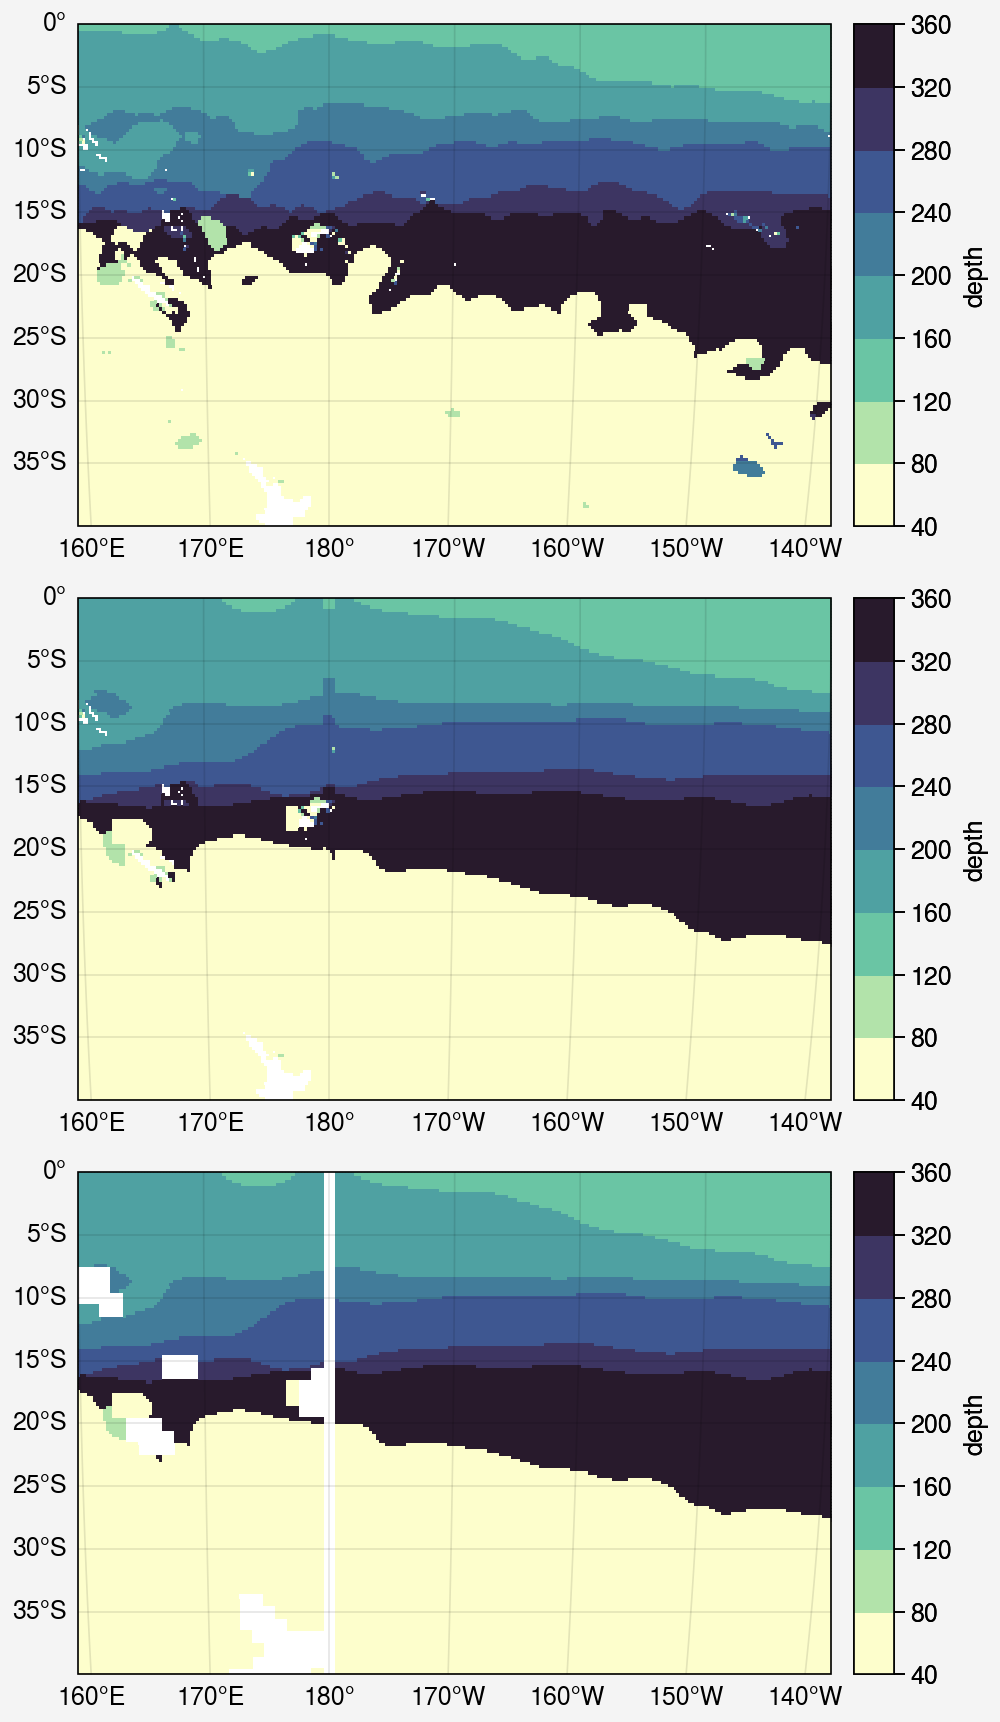

In [14]:
fig, axs = plot.subplots(nrows=3,
                        width=5,
                        proj='eck3',
                        proj_kw={'lon_0':180},)

latlim=(-40,0)
lonlim=(160,220)

axs.format(
    latlim=latlim,
    lonlim=lonlim,
    latlabels=5,
    lonlabels=10,
)

ax = axs[0]
thermocline_depth.sel(lat=slice(*latlim)).plot(cmap='deep',robust=True, ax=ax)
ax = axs[1]
thermocline_depth_01to04deg_04degfilled.sel(lat=slice(*latlim)).plot(cmap='deep',robust=True, ax=ax)
ax = axs[2]
thermocline_depth_01to04deg.sel(lat=slice(*latlim)).plot(cmap='deep',robust=True, ax=ax)

### 2.1.2 WOA23 Salinity and density calculation

In [15]:
fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/salinity'
sal_ds = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_s00_04.nc'),decode_times=False).drop('time')

sal_da = sal_ds.isel(time=0).s_an.load()
sal_da

<xarray.DataArray 's_an' (depth: 102, lat: 720, lon: 1440)>
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [30.765   , 30.76929 , 30.771809, ..., 30.76139 , 30.761791,
         30.76369 ],
        [30.97171 , 30.97601 , 30.97621 , ..., 30.972391, 30.9687  ,
         30.97271 ],
        [31.19969 , 31.19969 , 31.19969 , ..., 31.19969 , 31.19969 ,
         31.19969 ]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
...
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    standard_name:  sea_water_practical_salinity
    long_name:      Objectively analyzed mean fields for sea_water_practical_...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          1

In [16]:
import gsw

def calculate_density_gsw(temp, sal, depth, lat, lon):
    '''
    Modern TEOS-10 equation of state
    Much faster and more accurate than older equations
    '''
    # Convert to absolute salinity and conservative temperature
    pressure = gsw.p_from_z(-depth, lat)
    SA = gsw.SA_from_SP(sal, pressure, lon, lat)
    CT = gsw.CT_from_t(SA, temp, pressure)
    
    # Calculate potential density anomaly (sigma-0)
    sigma0 = gsw.sigma0(SA, CT)
    
    return sigma0

# For WOA data:
depth_3d, lat_3d, lon_3d = xr.broadcast(T_da.depth, T_da.lat, T_da.lon)

sigma0_da = xr.apply_ufunc(
    calculate_density_gsw,
    T_da, sal_da, depth_3d, lat_3d, lon_3d,
    dask='parallelized',
    output_dtypes=[float]
)

In [ ]:
fig, axs = plot.subplots(nrows=3,width=4,sharex=0,proj='eck3',proj_kw={'lon_0':180})
pycnocline_depth = sigma0_da.sel(depth=slice(0,1000)).differentiate('depth').idxmax(dim='depth')
thermocline_depth = T_da.sel(depth=slice(0,1000)).differentiate('depth').idxmin(dim='depth')

thermocline_depth.plot(levels=np.arange(0,501,50),cmap='deep', ax=axs[0],add_colorbar=False)
axs[0].format(title='Thermocline Depth (dT/dz)',latlabels=True, lonlabels=True, coast=True)

pycnocline_depth.plot(levels=np.arange(0,501,50),cmap='deep', ax=axs[1],add_colorbar=False)
axs[1].format(title='Pycnocline Depth (dSigma0/dz)',latlabels=True, lonlabels=True, coast=True)

### difference
(pycnocline_depth - thermocline_depth).plot(levels=np.arange(-50,55,5), cmap='RdBu_r', ax=axs[2],add_colorbar=False)
axs[2].format(title='Pycnocline - Thermocline Depth',latlabels=True, lonlabels=True, coast=True)


### 2.1.3 WOA23 and CMEMS Nitrate

CMEMS = Copernicus Marine Environmental Monitoring Service

- Nitrate - Mole concentration of nitrate in sea water 0.25deg x 0.25deg
- Unit: mmol/m3
- Link to data product website: https://data.marine.copernicus.eu/product/GLOBAL_MULTIYEAR_BGC_001_029/description

- Raw data: monthly climatology hindcasts from 1993-2022 (30 years)
- Processing: The climatology mean field of annual average were generated from 30-year montly climatologies using ncclimo function (https://nco.sourceforge.net/nco.html)

In [ ]:
fpath = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/nitrate'
fname = 'woa23_all_n00_01.nc'

woa23_nitrate = xr.open_dataset(os.path.join(fpath,fname),decode_times=False).drop('time')
woa23_nitrate = woa23_nitrate.isel(time=0).n_an.load()
woa23_nitrate_01to04deg = woa23_nitrate.interp_like(T_da)
woa23_nitrate_01to04deg

<xarray.DataArray 'n_an' (depth: 102, lat: 720, lon: 1440)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan, 0.57068527, ..., 0.57016486,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    standard_name:  moles_of_nitrate_per_unit_mass_in_sea_water
    long_name:      Objectively analyzed mean fields for moles_of_nitrate_per...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          micromoles_per_kilogram

In [ ]:
### NEMO nitrate data
fpath = fr'{local_onedrive_path}/Postdoc/Project/TEXAS/netcdf/Copernicus Marine Service/processed-files/Global-Biogeochemistry/climo-monthly/no3'
fname = r'mercatorfreebiorys2v4_global_mean_ANN_199301_202212_climo.nc'

nitrate_CMEMS_ds = xr.open_dataset(os.path.join(fpath,fname))
nitrate_CMEMS_ds = nitrate_CMEMS_ds.isel(time=0).drop('time')
nitrate_CMEMS_ds = nitrate_CMEMS_ds.rename({'latitude':'lat','longitude':'lon'})
nitrate_CMEMS_da = nitrate_CMEMS_ds.no3.load() ### convert mmol/L to umol/L to make it comparable to WOA data
nitrate_CMEMS_da

depth_coord = nitrate_CMEMS_da.depth
depth_coord = depth_coord - depth_coord[0]
nitrate_CMEMS_da = nitrate_CMEMS_da.assign_coords(depth=depth_coord)
nitrate_CMEMS_da

getfattr: /mnt/onedrive/Postdoc/Project/TEXAS/netcdf/Copernicus: No such file or directory
getfattr: Marine: No such file or directory
getfattr: Service/processed-files/Global-Biogeochemistry/climo-monthly/no3/mercatorfreebiorys2v4_global_mean_ANN_199301_202212_climo.nc: No such file or directory


<xarray.DataArray 'no3' (depth: 75, lat: 681, lon: 1440)>
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [5.7781367, 5.779535 , 5.7808266, ..., 5.7733583, 5.775043 ,
         5.7766376],
        [5.720044 , 5.7206492, 5.721291 , ..., 5.718462 , 5.7189493,
         5.719477 ],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
...
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * lon      (lon) float32 -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
  * lat      (lat) float32 -80.0 -79.75 -79.5 -79.25 ... 89.25 89.5 89.75 90.0
  * depth    (depth) float32 0.0 1.05 2.162 ... 5.494e+03 5.698e+03 5.902e+03
Attributes:
    long_name:      Nitrate
    standard_name:  mole_concentration_of_nitrate_in_sea_water
    units:          mmol m-3
    unit_long:      millimoles of Nitrate per cubic meter
    valid_min:      0.0
    valid_max:      59.31268
    cell_methods:   time: mean

In [ ]:
### regrid nitrate_CMESM to T_an grid
nitrate_CMEMS_da_regrid_lld = nitrate_CMEMS_da.interp_like(T_da)
nitrate_CMEMS_da_regrid_lld 

<xarray.DataArray 'no3' (depth: 102, lat: 720, lon: 1440)>
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [5.7811136, 5.7841377, 5.7870884, ..., 5.771783 , 5.774918 ,
               nan],
        [5.749591 , 5.7505755, 5.751523 , ..., 5.7464533, 5.747527 ,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
...
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    long_name:      Nitrate
    standard_name:  mole_concentration_of_nitrate_in_sea_water
    units:          mmol m-3
    unit_long:      millimoles of Nitrate per cubic meter
    valid_min:      0.0
    valid_max:      59.31268
    cell_methods:   time: mean

##### Nitricline Depth Calculations

In [ ]:
nitricline_depth_cmems_no3 = nitrate_CMEMS_da_regrid_lld.sel(depth=slice(0,1000)).differentiate('depth').idxmax(dim='depth')
nitricline_depth_cmems_no3

<xarray.DataArray 'depth' (lat: 720, lon: 1440)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [55., 55., 55., ..., 55., 55., nan],
       [55., 55., 55., ..., 55., 55., nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88

### 2.1.4 Depth-integrated calculations

In [ ]:
from scipy.stats import gamma
def gamma_weighted_mean_temperature(temp_da, depths, a=4.5, scale=15, max_depth=200):
    """
    Calculate gamma-weighted mean temperature
    
    The gamma distribution gives more weight to shallower depths
    with peak weight at depth = (a-1)*scale
    
    Parameters
    ----------
    temp_da : xarray.DataArray
        Temperature data
    depths : array
        Depth values
    a : float
        Gamma distribution shape parameter (alpha)
    scale : float
        Gamma distribution scale parameter (beta)
    max_depth : float
        Maximum depth for integration
    
    Returns
    -------
    xarray.DataArray
        Gamma-weighted mean temperature
    """
    # Select depth range
    temp_subset = temp_da.sel(depth=slice(0, max_depth))
    depths_subset = temp_subset['depth'].values
    
    # Calculate gamma weights at each depth
    weights = gamma.pdf(depths_subset, a=a, scale=scale)
    
    # Create DataArray for weights
    weights_da = xr.DataArray(weights, dims=['depth'], coords={'depth': depths_subset})
    
    # Multiply temperature by weights
    weighted_temp = temp_subset * weights_da
    
    # Integrate over depth (sum of weighted values * depth spacing)
    integrated_weighted = weighted_temp.integrate('depth')
    
    # Integrate weights to normalize
    integrated_weights = weights_da.integrate('depth')
    
    # Weighted mean = integral(T*w) / integral(w)
    gamma_weighted_mean = integrated_weighted / integrated_weights
    
    return gamma_weighted_mean

#### 2.1.4.1 Temperature integration calculations

In [ ]:
# Apply to your data
depths = T_da.depth.values

# Depth-averaged temperature (°C)
t_sf2tc_tc04deg = xr.apply_ufunc(
    depth_average_profile_to_depth,
    T_da,
    xr.DataArray(depths, dims=['depth']),
    thermocline_depth,
    input_core_dims=[['depth'], ['depth'], []],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float]
)

t_sf2tc_tc01to04deg_04degfilled = xr.apply_ufunc(
    depth_average_profile_to_depth,
    T_da,
    xr.DataArray(depths, dims=['depth']),
    thermocline_depth_01to04deg_04degfilled,
    input_core_dims=[['depth'], ['depth'], []],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float]
)

t_sf2tc_tc01to04deg = xr.apply_ufunc(
    depth_average_profile_to_depth,
    T_da,
    xr.DataArray(depths, dims=['depth']),
    thermocline_depth_01to04deg,
    input_core_dims=[['depth'], ['depth'], []],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float]
)

t01deg_stf2tc_tc01to04deg_04degfilled = xr.apply_ufunc(
    depth_average_profile_to_depth,
    T_01to04deg_04degfilled_da,
    xr.DataArray(depths, dims=['depth']),
    thermocline_depth_01to04deg_04degfilled,
    input_core_dims=[['depth'], ['depth'], []],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float]
)

t01deg_stf2tc_tc01to04deg = xr.apply_ufunc(
    depth_average_profile_to_depth,
    T_01to04deg_da,
    xr.DataArray(depths, dims=['depth']),
    thermocline_depth_01to04deg,
    input_core_dims=[['depth'], ['depth'], []],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float]
)

t_sf2tc_pc = xr.apply_ufunc(
    depth_average_profile_to_depth,
    T_da,
    xr.DataArray(depths, dims=['depth']),
    pycnocline_depth,
    input_core_dims=[['depth'], ['depth'], []],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float]
)

mean_temp_0_200m = T_da.sel(depth=slice(0,200)).mean('depth')

weighted_temp_0_200m = gamma_weighted_mean_temperature(T_da, T_da['depth'].values, 
                                                        a=4.5, scale=15, max_depth=200)



In [ ]:
# ### Calculate depth-averaged T to nitricline
# t_sf2nc_no3_woa23_1deg_cmemsfilled = xr.apply_ufunc(
#     depth_average_profile_to_depth,
#     T_da,
#     xr.DataArray(depths, dims=['depth']),
#     nitricline_depth_woa23_no3_1deg_cmemsfilled,
#     input_core_dims=[['depth'], ['depth'], []],
#     vectorize=True,
#     dask='parallelized',
#     output_dtypes=[float]
# )

# t_sf2nc_no3_cmems = xr.apply_ufunc(
#     depth_average_profile_to_depth,
#     T_da,
#     xr.DataArray(depths, dims=['depth']),
#     nitricline_depth_cmems_no3,
#     input_core_dims=[['depth'], ['depth'], []],
#     vectorize=True,
#     dask='parallelized',
#     output_dtypes=[float]
# )


#### 2.1.4.2 Nitrate integration calculations

In [ ]:
cmems_no3_sf3tc_tc04deg = xr.apply_ufunc(
    depth_average_profile_to_depth,
    nitrate_CMEMS_da_regrid_lld,
    xr.DataArray(depths, dims=['depth']),
    thermocline_depth,
    input_core_dims=[['depth'], ['depth'], []],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float]
)

cmems_no3_sf3tc_tc01to04deg = xr.apply_ufunc(
    depth_average_profile_to_depth,
    nitrate_CMEMS_da_regrid_lld,
    xr.DataArray(depths, dims=['depth']),
    thermocline_depth_01to04deg,
    input_core_dims=[['depth'], ['depth'], []],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float]
)

cmems_no3_sf3tc_tc01to04deg_04degfilled = xr.apply_ufunc(
    depth_average_profile_to_depth,
    nitrate_CMEMS_da_regrid_lld,
    xr.DataArray(depths, dims=['depth']),
    thermocline_depth_01to04deg_04degfilled,
    input_core_dims=[['depth'], ['depth'], []],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float]
)

cmems_no3_sf3pc = xr.apply_ufunc(
    depth_average_profile_to_depth,
    nitrate_CMEMS_da_regrid_lld,
    xr.DataArray(depths, dims=['depth']),
    pycnocline_depth,
    input_core_dims=[['depth'], ['depth'], []],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float]
)

woa23_no3_sf2tc_tc01to04deg = xr.apply_ufunc(
    depth_average_profile_to_depth,
    woa23_nitrate_01to04deg,
    xr.DataArray(depths, dims=['depth']),
    thermocline_depth_01to04deg,
    input_core_dims=[['depth'], ['depth'], []],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float]
)

woa23_no3_sf2tc_tc01to04deg_cmems04filled = woa23_no3_sf2tc_tc01to04deg.fillna(cmems_no3_sf3tc_tc04deg)

### 2.1.5 Nitrification rate -- Zakem et al. 2022 Biogeosciences

In [ ]:
fpath = f'{local_onedrive_path}/Postdoc/Project/TEXAS/netcdf/Zakem2022_Biogeosciences'
subfolder = f'DEFAULT_runNitrifyModel_NatComm_newyields_eqaff_withnitrtemp-20250925T232044Z-1-001/DEFAULT_runNitrifyModel_NatComm_newyields_eqaff_withnitrtemp'
fname = 'ptr_tave.0000720000.nc'
nitrif_ds = xr.open_dataset(os.path.join(fpath,subfolder,fname)).squeeze('T')

X_values = nitrif_ds['X'].values
X_converted = np.where(X_values > 180, X_values - 360, X_values)
nitrif_ds = nitrif_ds.assign_coords(X=X_converted)


# Find where longitude jumps from positive to negative
lon_diff = np.diff(nitrif_ds['X'])
wrap_index = np.where(lon_diff < -180)[0][0] + 1

# Roll the dataset to put negative longitudes first
nitrif_ds = nitrif_ds.roll(X=len(nitrif_ds['X']) - wrap_index, roll_coords=True)

# Verify it's monotonic
print(f"Longitude range: {nitrif_ds['X'].min().values:.1f} to {nitrif_ds['X'].max().values:.1f}")
print(f"Is monotonic: {np.all(np.diff(nitrif_ds['X']) > 0)}")

nitrif_ds = nitrif_ds.rename({'X':'lon','Y':'lat','Z':'depth'})
nitrif_ds['depth'] = -nitrif_ds['depth']
nitrif_ds

Longitude range: -179.5 to 179.5
Is monotonic: True


<xarray.Dataset>
Dimensions:  (lon: 360, lat: 160, depth: 23)
Coordinates:
  * lon      (lon) float64 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 -79.5 -78.5 -77.5 -76.5 -75.5 ... 76.5 77.5 78.5 79.5
  * depth    (depth) float64 5.0 15.0 27.5 45.0 ... 4.45e+03 4.95e+03 5.45e+03
    T        datetime64[ns] 2247-05-26
Data variables: (12/48)
    iter     int32 ...
    DIC      (depth, lat, lon) float64 nan nan nan nan nan ... nan nan nan nan
    NH4      (depth, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    NO2      (depth, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    NO3      (depth, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    PO4      (depth, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    ...       ...
    Chl07    (depth, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    Chl08    (depth, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    Chl09    (depth, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    Chl10    (depth, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    Chl11    (depth, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    Chl12    (depth, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes: (12/18)
    MITgcm_version:  checkpoint65g
    build_user:      ezakem
    build_host:      eofe7.cm.cluster
    build_date:      Tue Dec 14 14:23:47 EST 2021
    MITgcm_URL:      http://mitgcm.org
    MITgcm_tag_id:   
    ...              ...
    nSy:             1
    nPx:             8
    nPy:             4
    Nx:              360
    Ny:              160
    Nr:              23

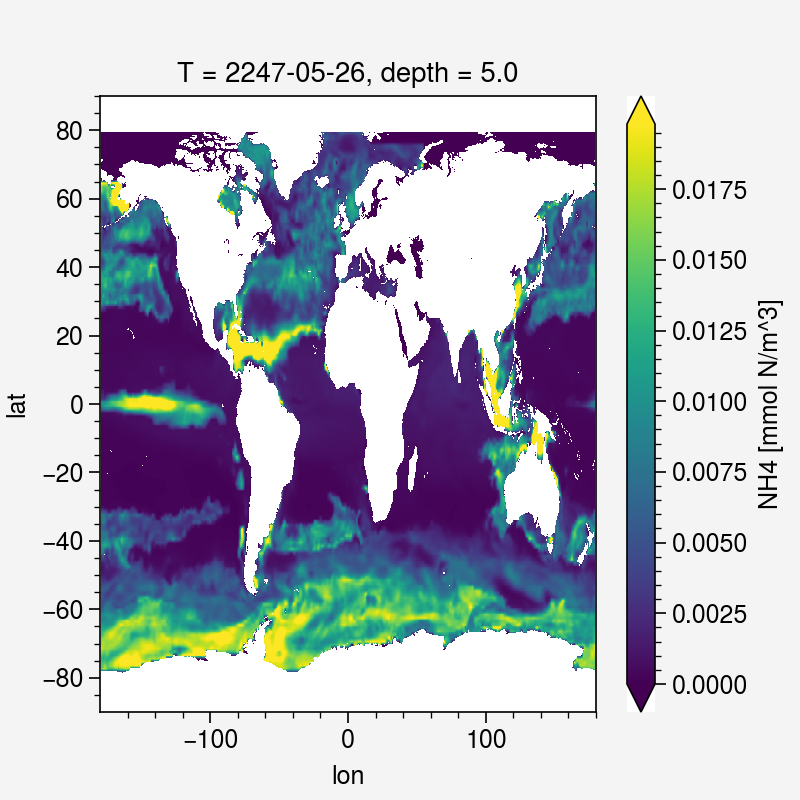

In [ ]:
NH4_1deg_da = nitrif_ds['NH4']
NH4_04deg_da_regridded = NH4_1deg_da.interp(lon=T_da.lon, lat=T_da.lat, 
                                            depth=T_da.sel(depth=slice(NH4_1deg_da.depth.min(), NH4_1deg_da.depth.max())).depth, 
                                            method='linear')

land_mask = np.isnan(T_da.isel(depth=0))
NH4_04deg_da_regridded = NH4_04deg_da_regridded.where(~land_mask)
NH4_04deg_da_regridded.isel(depth=0).plot(robust=True)

nh4_sf2tc_avg = xr.apply_ufunc(
    depth_average_profile_to_depth,
    NH4_04deg_da_regridded,
    xr.DataArray(NH4_04deg_da_regridded['depth'], dims=['depth']),
    thermocline_depth,
    input_core_dims=[['depth'], ['depth'], []],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float]
)

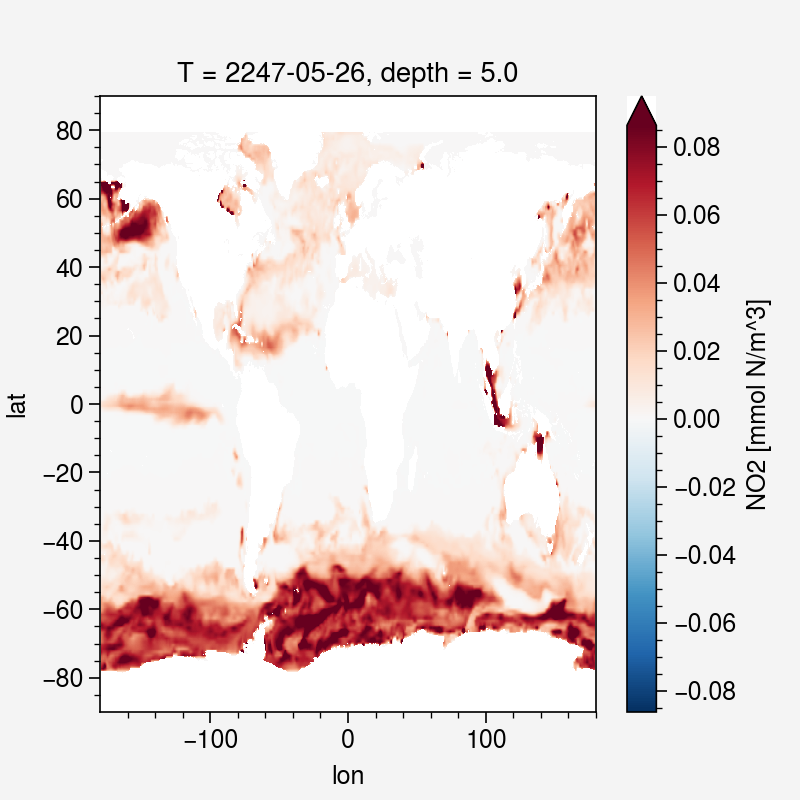

In [ ]:
NO2_1deg_da = nitrif_ds['NO2']
NO2_1deg_da_regridded = NO2_1deg_da.interp(lon=T_da.lon, lat=T_da.lat, 
                                          depth=T_da.sel(depth=slice(NO2_1deg_da.depth.min(), NO2_1deg_da.depth.max())).depth, 
                                          method='linear')
land_mask = np.isnan(T_da.isel(depth=0))
NO2_1deg_da_regridded = NO2_1deg_da_regridded.where(~land_mask)
NO2_1deg_da_regridded.isel(depth=0).plot(robust=True)

no2_sf2tc_avg = xr.apply_ufunc(
    depth_average_profile_to_depth,
    NO2_1deg_da_regridded,
    xr.DataArray(NO2_1deg_da_regridded['depth'], dims=['depth']),
    thermocline_depth,
    input_core_dims=[['depth'], ['depth'], []],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float]
)

### 2.1.6 Processed ocean properties --- Rattanasriampaipong et al. 2025

In [ ]:
fpath = f'{local_github_path}/data/external/ncfiles'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_prop_ds = xr.open_dataset(os.path.join(fpath,fname))
ocean_prop_ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

## 2.2 Coretop compilation

In [ ]:
fpath = fpath = fr'{local_onedrive_path}/Postdoc/Project/TEXAS/datasets'
fname = r'ds01_updated_global_coretop_tex_revised_011226.csv'


coretop_df = pd.read_csv(os.path.join(fpath,fname))
coretop_df = coretop_df.rename(columns={
    'latitude':'Latitude',
    'longitude':'Longitude',
    'depth':'modernWaterDepth',
    'tex86':'TEX86',
    'bit':'BIT'
})
coretop_df = coretop_df[coretop_df['exclude_data']!='yes']
coretop_df['TEX86L'] = (coretop_df['fGDGT_2']) / (coretop_df['fGDGT_1'] + coretop_df['fGDGT_2'] + coretop_df['fGDGT_3'])
coretop_df

,index_column,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,regionID,regionName,...,publicationYear,reference_name,remark,exclude_data,exclusion_remark,reference_link,dataset_DOI,OPTiMAL_Dnearest,OPTiMAL_SST,TEX86L
0,JET_RR_00001,GeoB7702-3,GC,5.00,6.00,31.65,34.07,562.00,NaN,NaN,...,2010,Castaneda2010,Data published in Tierney & Tingley (2015),NaN,NaN,http://dx.doi.org/10.1029/2009PA001740,'https://doi.org/10.25921/wt2r-sc81,3.43,15.47,NaN
1,JET_RR_00002,KNR195-5-5 MC11,MC,6.00,8.00,-1.53,-86.79,2288.00,10.00,East Equatorial Pacific,...,2025,this study,Reanalysed samples of Chazen2011 by this study,NaN,NaN,NaN,10.5281/zenodo.14806962,0.25,21.64,0.47
2,JET_RR_00003,KNR195-5-6 MC12,MC,0.00,1.00,-3.71,-81.12,378.00,NaN,NaN,...,2011,Chazen2011,Data published in Tierney & Tingley (2015),NaN,NaN,https://repository.library.brown.edu/studio/it...,'https://doi.org/10.25921/wt2r-sc81,3.43,15.47,NaN
3,JET_RR_00004,KNR195-5-7 MC16,MC,0.00,1.00,-3.75,-81.14,379.00,NaN,NaN,...,2011,Chazen2011,Data published in Tierney & Tingley (2015),NaN,NaN,https://repository.library.brown.edu/studio/it...,'https://doi.org/10.25921/wt2r-sc81,3.43,15.47,NaN
4,JET_RR_00005,KNR195-5-8 MC18,MC,4.00,6.00,-3.97,-81.31,1024.00,10.00,East Equatorial Pacific,...,2025,this study,Reanalysed samples of Chazen2011 by this study,NaN,NaN,NaN,10.5281/zenodo.14806962,0.30,19.28,0.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2079,JET_RR_02080,AMD17_176_BC,NaN,NaN,NaN,69.60,-65.40,267.00,60.00,Baffin Bay,...,2023,Harning2023,Data from original source,NaN,NaN,https://doi.org/10.5194/bg-20-229-2023,https://doi.org/10.1594/PANGAEA.956212,0.59,8.22,0.23
2080,JET_RR_02081,AMD17_8.1_BC,NaN,NaN,NaN,69.41,-64.40,1054.00,60.00,Baffin Bay,...,2023,Harning2023,Data from original source,NaN,NaN,https://doi.org/10.5194/bg-20-229-2023,https://doi.org/10.1594/PANGAEA.956212,0.58,6.43,0.21
2081,JET_RR_02082,AMD17_Disko_Fan_BC,NaN,NaN,NaN,67.97,-59.49,1012.00,60.00,Baffin Bay,...,2023,Harning2023,Data from original source,NaN,NaN,https://doi.org/10.5194/bg-20-229-2023,https://doi.org/10.1594/PANGAEA.956212,0.23,5.32,0.24
2082,JET_RR_02083,DSDP591_0-3cm_PC,PC,0.00,3.00,-31.58,164.45,2131.00,61.00,Tasman Sea,...,2025,this study,New GDGT measurements published in this study,NaN,NaN,NaN,10.5281/zenodo.14806962,0.23,25.43,0.49


### 2.2.1 calculate GDGT indices

In [ ]:
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
coretop_df = coretop_df.dropna(subset=features)
coretop_df['ringIndex'] = np.sum(coretop_df[features] * [ringNumbers_dict_zhang16.get(col) for col in features], axis=1)/np.sum(coretop_df[features], axis=1)
RI_TEX = -0.77*coretop_df['TEX86'] + 3.32*coretop_df['TEX86']**2 + 1.59
coretop_df['deltaRI'] = RI_TEX - coretop_df['ringIndex']
coretop_df['scaledRI'] = coretop_df['ringIndex']/4
coretop_df['gdgt23ratio'] = coretop_df['fGDGT_2']/coretop_df['fGDGT_3']
coretop_df['ZeroOverZeroCren'] = coretop_df['fGDGT_0']/(coretop_df['fGDGT_cren']+coretop_df['fGDGT_0'])
coretop_df

,index_column,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,regionID,regionName,...,reference_link,dataset_DOI,OPTiMAL_Dnearest,OPTiMAL_SST,TEX86L,ringIndex,deltaRI,scaledRI,gdgt23ratio,ZeroOverZeroCren
1,JET_RR_00002,KNR195-5-5 MC11,MC,6.00,8.00,-1.53,-86.79,2288.00,10.00,East Equatorial Pacific,...,NaN,10.5281/zenodo.14806962,0.25,21.64,0.47,2.34,-0.01,0.59,13.19,0.40
4,JET_RR_00005,KNR195-5-8 MC18,MC,4.00,6.00,-3.97,-81.31,1024.00,10.00,East Equatorial Pacific,...,NaN,10.5281/zenodo.14806962,0.30,19.28,0.42,2.57,-0.25,0.64,4.88,0.33
6,JET_RR_00007,KNR195-5 MC25,MC,5.00,7.00,-3.58,-81.17,381.00,10.00,East Equatorial Pacific,...,NaN,10.5281/zenodo.14806962,0.11,22.10,0.44,2.50,-0.12,0.63,4.41,0.35
7,JET_RR_00008,KNR195-5-13 MC33,MC,3.00,5.00,-3.22,-82.91,2949.00,10.00,East Equatorial Pacific,...,NaN,10.5281/zenodo.14806962,0.23,19.95,0.43,2.43,-0.09,0.61,6.87,0.37
8,JET_RR_00009,KNR195-5-14 MC34,MC,4.00,6.00,-3.60,-83.96,3224.00,10.00,East Equatorial Pacific,...,NaN,10.5281/zenodo.14806962,0.14,22.32,0.45,2.25,0.04,0.56,8.43,0.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2079,JET_RR_02080,AMD17_176_BC,NaN,NaN,NaN,69.60,-65.40,267.00,60.00,Baffin Bay,...,https://doi.org/10.5194/bg-20-229-2023,https://doi.org/10.1594/PANGAEA.956212,0.59,8.22,0.23,1.20,0.62,0.30,3.00,0.70
2080,JET_RR_02081,AMD17_8.1_BC,NaN,NaN,NaN,69.41,-64.40,1054.00,60.00,Baffin Bay,...,https://doi.org/10.5194/bg-20-229-2023,https://doi.org/10.1594/PANGAEA.956212,0.58,6.43,0.21,1.09,0.60,0.27,6.00,0.73
2081,JET_RR_02082,AMD17_Disko_Fan_BC,NaN,NaN,NaN,67.97,-59.49,1012.00,60.00,Baffin Bay,...,https://doi.org/10.5194/bg-20-229-2023,https://doi.org/10.1594/PANGAEA.956212,0.23,5.32,0.24,1.22,0.55,0.30,3.50,0.70
2082,JET_RR_02083,DSDP591_0-3cm_PC,PC,0.00,3.00,-31.58,164.45,2131.00,61.00,Tasman Sea,...,NaN,10.5281/zenodo.14806962,0.23,25.43,0.49,2.49,0.08,0.62,6.64,0.36


### 2.2.2 match ocean properties

In [ ]:
woa23_04deg_lats = T_da['lat'].values
woa23_04deg_lons = T_da['lon'].values

coretop_df['match_lat_04deg'] = coretop_df['Latitude'].apply(lambda x: woa23_04deg_lats[np.abs(woa23_04deg_lats - x).argmin()])
coretop_df['match_lon_04deg'] = coretop_df['Longitude'].apply(lambda x: woa23_04deg_lons[np.abs(woa23_04deg_lons - x).argmin()])

woa23_1deg_lats = T_1deg_da['lat'].values
woa23_1deg_lons = T_1deg_da['lon'].values
coretop_df['match_lat_1deg'] = coretop_df['Latitude'].apply(lambda x: woa23_1deg_lats[np.abs(woa23_1deg_lats - x).argmin()])
coretop_df['match_lon_1deg'] = coretop_df['Longitude'].apply(lambda x: woa23_1deg_lons[np.abs(woa23_1deg_lons - x).argmin()])
coretop_df

,index_column,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,regionID,regionName,...,TEX86L,ringIndex,deltaRI,scaledRI,gdgt23ratio,ZeroOverZeroCren,match_lat_04deg,match_lon_04deg,match_lat_1deg,match_lon_1deg
1,JET_RR_00002,KNR195-5-5 MC11,MC,6.00,8.00,-1.53,-86.79,2288.00,10.00,East Equatorial Pacific,...,0.47,2.34,-0.01,0.59,13.19,0.40,-1.62,-86.88,-1.50,-86.50
4,JET_RR_00005,KNR195-5-8 MC18,MC,4.00,6.00,-3.97,-81.31,1024.00,10.00,East Equatorial Pacific,...,0.42,2.57,-0.25,0.64,4.88,0.33,-3.88,-81.38,-3.50,-81.50
6,JET_RR_00007,KNR195-5 MC25,MC,5.00,7.00,-3.58,-81.17,381.00,10.00,East Equatorial Pacific,...,0.44,2.50,-0.12,0.63,4.41,0.35,-3.62,-81.12,-3.50,-81.50
7,JET_RR_00008,KNR195-5-13 MC33,MC,3.00,5.00,-3.22,-82.91,2949.00,10.00,East Equatorial Pacific,...,0.43,2.43,-0.09,0.61,6.87,0.37,-3.12,-82.88,-3.50,-82.50
8,JET_RR_00009,KNR195-5-14 MC34,MC,4.00,6.00,-3.60,-83.96,3224.00,10.00,East Equatorial Pacific,...,0.45,2.25,0.04,0.56,8.43,0.42,-3.62,-83.88,-3.50,-83.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2079,JET_RR_02080,AMD17_176_BC,NaN,NaN,NaN,69.60,-65.40,267.00,60.00,Baffin Bay,...,0.23,1.20,0.62,0.30,3.00,0.70,69.62,-65.38,69.50,-65.50
2080,JET_RR_02081,AMD17_8.1_BC,NaN,NaN,NaN,69.41,-64.40,1054.00,60.00,Baffin Bay,...,0.21,1.09,0.60,0.27,6.00,0.73,69.38,-64.38,69.50,-64.50
2081,JET_RR_02082,AMD17_Disko_Fan_BC,NaN,NaN,NaN,67.97,-59.49,1012.00,60.00,Baffin Bay,...,0.24,1.22,0.55,0.30,3.50,0.70,67.88,-59.38,67.50,-59.50
2082,JET_RR_02083,DSDP591_0-3cm_PC,PC,0.00,3.00,-31.58,164.45,2131.00,61.00,Tasman Sea,...,0.49,2.49,0.08,0.62,6.64,0.36,-31.62,164.38,-31.50,164.50


In [ ]:
coretop_df['SST'] = np.array([
    T_da.sel(lat=row['Latitude'],lon=row['Longitude'],method='nearest').isel(depth=0).values
    for _, row in coretop_df.iterrows()
])

SST = T_da.isel(depth=0)
SST_1deg = T_1deg_da.interp_like(T_da).isel(depth=0)
SST_1deg_04filled = SST_1deg.fillna(SST)
coretop_df['SST_1deg_04filled'] = np.array([
    SST_1deg_04filled.sel(lat=row['Latitude'],lon=row['Longitude'],method='nearest').values
    for _, row in coretop_df.iterrows()
])

coretop_df['SST_1deg'] = np.array([
    SST_1deg.sel(lat=row['Latitude'],lon=row['Longitude'],method='nearest').values
    for _, row in coretop_df.iterrows()
])

coretop_df['t_sf2tc_avg'] = np.array([
    ocean_prop_ds['t_sf2tc_avg'].sel(lat=row['Latitude'],lon=row['Longitude'],method='nearest').values
    for _, row in coretop_df.iterrows()
])

coretop_df['t_sf2tc_1deg_04filled'] = np.array([
    t_sf2tc_tc01to04deg_04degfilled.sel(lat=row['Latitude'],lon=row['Longitude'],method='nearest').values
    for _, row in coretop_df.iterrows()
])

coretop_df['t1deg_sf2tc_1deg_04filled'] = np.array([
    t01deg_stf2tc_tc01to04deg_04degfilled.sel(lat=row['Latitude'],lon=row['Longitude'],method='nearest').values
    for _, row in coretop_df.iterrows()
])

coretop_df['t_sf2tc_1deg'] = np.array([
    t_sf2tc_tc01to04deg.sel(lat=row['Latitude'],lon=row['Longitude'],method='nearest').values
    for _, row in coretop_df.iterrows()
])

#############################

coretop_df['no3_sf2tc_avg'] = np.array([
    ocean_prop_ds['no3_sf2tc_avg'].sel(lat=row['Latitude'],lon=row['Longitude'],method='nearest').values
    for _, row in coretop_df.iterrows()
])

coretop_df['no3_sf2tc_tc1deg04filled'] = np.array([
    cmems_no3_sf3tc_tc01to04deg_04degfilled.sel(lat=row['Latitude'],lon=row['Longitude'],method='nearest').values
    for _, row in coretop_df.iterrows()
])

coretop_df['woa23_no3_sf2tc_tc1deg04filled'] = np.array([
    woa23_no3_sf2tc_tc01to04deg_cmems04filled.sel(lat=row['Latitude'],lon=row['Longitude'],method='nearest').values
    for _, row in coretop_df.iterrows()
])

coretop_df['woa23_no3_sf2tc_1deg'] = np.array([
    woa23_no3_sf2tc_tc01to04deg.sel(lat=row['Latitude'],lon=row['Longitude'],method='nearest').values
    for _, row in coretop_df.iterrows()
])


#############################
coretop_df['nh4_sf2tc_avg'] = np.array([
    nh4_sf2tc_avg.sel(lat=row['Latitude'],lon=row['Longitude'],method='nearest').values
    for _, row in coretop_df.iterrows()
])

coretop_df['no2_sf2tc_avg'] = np.array([
    no2_sf2tc_avg.sel(lat=row['Latitude'],lon=row['Longitude'],method='nearest').values
    for _, row in coretop_df.iterrows()
])


############################

coretop_df['t_sf2pc_avg'] = np.array([
    t_sf2tc_pc.sel(lat=row['Latitude'],lon=row['Longitude'],method='nearest').values
    for _, row in coretop_df.iterrows()
])

# coretop_df['t_sf2nc_woa23nc'] = np.array([
#     t_sf2nc_no3_woa23_1deg_cmemsfilled.sel(lat=row['Latitude'],lon=row['Longitude'],method='nearest').values
#     for _, row in coretop_df.iterrows()
# ])

# coretop_df['t_sf2nc_cmemsnc'] = np.array([
#     t_sf2nc_no3_cmems.sel(lat=row['Latitude'],lon=row['Longitude'],method='nearest').values
#     for _, row in coretop_df.iterrows()
# ])

# coretop_df['cmems_no3_sf2pc_avg'] = np.array([
#     cmems_no3_sf3pc_avg.sel(lat=row['Latitude'],lon=row['Longitude'],method='nearest').values
#     for _, row in coretop_df.iterrows()
# ])



## 2.3 Culture-Mesocosm Data

In [ ]:
### Regression dataset compilation
fpath = fr'{local_onedrive_path}/Postdoc/Project/TEXAS/datasets'
fname = r'culture_mesocosm_combined_rev_092325.xlsx'

culture_meso_df = pd.read_excel(os.path.join(fpath, fname),sheet_name='culture_mesocosm_combined_rev_0')
culture_meso_df

,sampleID,sampleName,Source,TLE_method,MS_method,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,...,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins,OPTiMAL_Dnearest,OPTiMAL_SST
0,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,NaN,NaN,37,0.58,2.79,0.70,0.48,...,0.13,0.44,0.08,culture,0.42,0.17,0,Culture-temperature_Terrestrial thermophile,16.22,15.54
1,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,NaN,NaN,46,0.81,3.73,0.93,0.48,...,0.04,0.71,0.17,culture,0.12,0.01,0,Culture-temperature_Terrestrial thermophile,3.03,15.66
2,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,NaN,NaN,50,0.76,3.73,0.93,0.65,...,0.03,0.75,0.14,culture,0.11,0.01,0,Culture-temperature_Terrestrial thermophile,2.22,16.33
3,TEXAS_PSM_culture_RR004,Elling2015_Culture_NAOA2_18,Elling et al. (2015) GCA,NaN,NaN,18,0.86,2.44,0.61,0.40,...,0.43,0.16,0.02,culture,0.80,0.43,0,Culture-temperature_Marine mesophile,79.57,15.54
4,TEXAS_PSM_culture_RR005,Elling2015_Culture_NAOA2_22,Elling et al. (2015) GCA,NaN,NaN,22,0.83,2.24,0.56,1.09,...,0.24,0.20,0.01,culture,0.74,0.45,0,Culture-temperature_Marine mesophile,40.85,15.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,TEXAS_PSM_culture_RR167,meso_017,Schouten2007,NaN,NaN,25,0.45,2.77,0.69,2.63,...,0.01,0.64,0.01,mesocosm,0.16,0.27,0,NaN,0.70,16.22
167,TEXAS_PSM_culture_RR168,meso_018,Schouten2007,NaN,NaN,32,0.68,2.63,0.66,3.55,...,0.02,0.56,0.04,mesocosm,0.17,0.33,0,NaN,0.51,24.19
168,TEXAS_PSM_culture_RR169,meso_019,Schouten2007,NaN,NaN,34,0.61,3.24,0.81,2.32,...,0.02,0.75,0.01,mesocosm,0.13,0.14,0,NaN,1.02,23.32
169,TEXAS_PSM_culture_RR170,meso_020,Schouten2007,NaN,NaN,36,0.81,3.60,0.90,2.40,...,0.02,0.82,0.03,mesocosm,0.11,0.06,0,NaN,1.53,18.86


In [ ]:
culture_meso_df['organism_broadClass3'].unique()

array(['Group 1.1a-terrestrial/geothermal', 'Group 1.1a-marine',
       'Group 1.1a-terrestrial', 'Group 1.1b-terrestrial',
       'HWCG-III-Nitrosocaldus', 'Group 1.1b-terrestrial/geothermal',
       'Acidilobaceae', 'Sulfolobaceae', 'Thermoproteaceae',
       'Desulfurococcaceae', 'Group 1.1b-Nitrososphaera',
       'Picrophilaceae', 'NorthSea_mesocosm', 'Seychelles_mesocosm'],
      dtype=object)

## 2.4 Combined dataset --- Coretop, Mesocosm, Culture

In [ ]:
coretop_df['lowAbundanceFlag'] = False
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']

## if any of the GDGTs is below 0.001, flag as low abundance
for feature in features:
    coretop_df['lowAbundanceFlag'] = coretop_df['lowAbundanceFlag'] | (((coretop_df[feature]>0) & (coretop_df[feature]<0.001))
                                                                       & coretop_df[feature].notna())


coretop_df['inv_fGDGT0'] = 1-coretop_df['fGDGT_0']
culture_meso_df['inv_fGDGT0'] = 1-culture_meso_df['fGDGT_0']
culture_meso_df['organism_broadClass2'].replace({'NorthSea_mesocosm':'mesocosm', 'Seychelles_mesocosm':'mesocosm'}, inplace=True)
culture_meso_df['organism_broadClass3'].replace({'NorthSea_mesocosm':'mesocosm', 'Seychelles_mesocosm':'mesocosm'}, inplace=True)

In [ ]:
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
temp_df1 = coretop_df[['Latitude','Longitude',
                       'match_lat_04deg','match_lon_04deg',
                       'match_lat_1deg','match_lon_1deg',
                       'modernWaterDepth',
                       't_sf2tc_avg','t_sf2tc_1deg_04filled',
                       't1deg_sf2tc_1deg_04filled','t_sf2tc_1deg',
                       't_sf2pc_avg',
                       'SST','SST_1deg','SST_1deg_04filled',
                       'no3_sf2tc_avg','no3_sf2tc_tc1deg04filled',
                       'woa23_no3_sf2tc_tc1deg04filled',
                    #    'cmems_no3_sf2pc_avg',
                       'woa23_no3_sf2tc_1deg',
                       'nh4_sf2tc_avg', 'no2_sf2tc_avg',
                       'TEX86','ringIndex','scaledRI','inv_fGDGT0',
                       'BIT','methaneIndex',
                       'OPTiMAL_Dnearest','OPTiMAL_SST',
                       'regionName',
                       'reference_name']+features].copy()
temp_df1['datatype'] = 'coretop'
temp_df1['Strains'] = 'coretop'
temp_df1['organism_commonName'] = 'coretop'
temp_df1['organism_broadClass'] = 'coretop'
temp_df1['organism_broadClass2'] = 'coretop'
temp_df1['organism_broadClass3'] = 'coretop'


temp_df2 = culture_meso_df[culture_meso_df['Temperature']<50][
    culture_meso_df['experiment_setup'].isin(['mesocosm','Culture-temperature'])][
        ['TEX86','ringIndex',
         'scaledRI','inv_fGDGT0','BIT','methaneIndex',
         'OPTiMAL_Dnearest','OPTiMAL_SST',
         'datatype','Source',
         'Strains','organism_commonName',
         'organism_broadClass','organism_broadClass2', 'organism_broadClass3']+features].copy().rename(columns={'Source':'reference_name'})

temp_df2['t_sf2tc_avg'] = culture_meso_df['Temperature']
temp_df2['t_sf2tc_1deg_04filled'] = culture_meso_df['Temperature']
temp_df2['t1deg_sf2tc_1deg_04filled'] = culture_meso_df['Temperature']
temp_df2['t_sf2pc_avg'] = culture_meso_df['Temperature']
temp_df2['SST'] = culture_meso_df['Temperature']
temp_df2['SST_1deg'] = culture_meso_df['Temperature']
temp_df2['SST_1deg_04filled'] = culture_meso_df['Temperature']
temp_df2['t_sf2tc_1deg'] = culture_meso_df['Temperature']
temp_df2['regionName'] = temp_df2['datatype']
combined_df_raw = pd.concat([temp_df1, temp_df2], ignore_index=True)
combined_df_raw



,Latitude,Longitude,match_lat_04deg,match_lon_04deg,match_lat_1deg,match_lon_1deg,modernWaterDepth,t_sf2tc_avg,t_sf2tc_1deg_04filled,t1deg_sf2tc_1deg_04filled,...,fGDGT_2,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,Strains,organism_commonName,organism_broadClass,organism_broadClass2,organism_broadClass3
0,-1.53,-86.79,-1.62,-86.88,-1.50,-86.50,2288.00,22.52,22.17,22.87,...,0.06,0.00,0.50,0.03,coretop,coretop,coretop,coretop,coretop,coretop
1,-3.97,-81.31,-3.88,-81.38,-3.50,-81.50,1024.00,21.32,21.32,21.32,...,0.05,0.01,0.56,0.03,coretop,coretop,coretop,coretop,coretop,coretop
2,-3.58,-81.17,-3.62,-81.12,-3.50,-81.50,381.00,22.09,22.09,22.09,...,0.06,0.01,0.54,0.03,coretop,coretop,coretop,coretop,coretop,coretop
3,-3.22,-82.91,-3.12,-82.88,-3.50,-82.50,2949.00,20.62,20.92,21.24,...,0.06,0.01,0.52,0.04,coretop,coretop,coretop,coretop,coretop,coretop
4,-3.60,-83.96,-3.62,-83.88,-3.50,-83.50,3224.00,21.17,21.46,21.61,...,0.07,0.01,0.47,0.03,coretop,coretop,coretop,coretop,coretop,coretop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.00,25.00,25.00,...,0.04,0.01,0.64,0.01,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm
2127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.00,32.00,32.00,...,0.06,0.02,0.56,0.04,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm
2128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.00,34.00,34.00,...,0.05,0.02,0.75,0.01,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm
2129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.00,36.00,36.00,...,0.05,0.02,0.82,0.03,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm


### Calculate additional indices for combined dataset

In [ ]:
combined_df_raw['TEXRI_Zhang16'] = -0.77*combined_df_raw['TEX86'] + (3.32*np.power(combined_df_raw['TEX86'],2)) + 1.59
combined_df_raw['deltaRI'] = combined_df_raw['TEXRI_Zhang16'] - combined_df_raw['ringIndex']
combined_df_raw['abs_deltaRI'] = abs(combined_df_raw['deltaRI'])
combined_df_raw['ZeroOverZeroCren'] = combined_df_raw['fGDGT_0'] / (combined_df_raw['fGDGT_0'] + combined_df_raw['fGDGT_cren'])
combined_df_raw['CrenOverZeroCren'] = combined_df_raw['fGDGT_cren'] / (combined_df_raw['fGDGT_0'] + combined_df_raw['fGDGT_cren'])
combined_df_raw['CrenPrimeOverCren'] = combined_df_raw['fGDGT_cren_prime'] / (combined_df_raw['fGDGT_cren_prime'] + combined_df_raw['fGDGT_cren'])
combined_df_raw['inv_fGDGT0'] = 1 - combined_df_raw['fGDGT_0']
combined_df_raw['gdgt23ratio'] = combined_df_raw['fGDGT_2'] / combined_df_raw['fGDGT_3']

In [ ]:
combined_df_raw['reference_name'] = ['Rattanasriampaipong2025' if row == 'this study' else row for row in combined_df_raw['reference_name']]
combined_df_raw['reference_name'] = ['Rattanasriampaipong2026' if row == 'Elling et al. Unpublished' else row for row in combined_df_raw['reference_name']]
print(combined_df_raw['reference_name'].unique())
combined_df_raw['publicationYear'] = np.nan
for i in range(len(combined_df_raw)):
    if pd.isna(combined_df_raw['reference_name'].iloc[i]):
        continue
    
    ### find '20' substring in reference name
    if '20' in combined_df_raw['reference_name'].iloc[i]:
        year_str = combined_df_raw['reference_name'].iloc[i].split('20')[1][:2]
        try:
            combined_df_raw['publicationYear'].iloc[i] = int('20' + year_str)
            continue
        except:
            pass



['Rattanasriampaipong2025' 'Fallet2012' 'Ho2011' 'Hu2012' 'Jia2012'
 'Kaiser2015' 'Kim2008' 'Kim2010' 'Leider2010' 'Trommer2009' 'Wei2011'
 'Hernandez-Sanchez2014' 'Tierney2015SciAdv' 'Ho2014' 'Chen2014'
 'Seki2014' 'Kaiser2014' 'Lu2014' 'Zhou2014' 'Zell2014' 'Tierney2015'
 'Richey and Tierney 2016' 'Park2014' 'Lengger2014' 'Harning2019'
 'Chen2018' 'Kim2016' 'Schukies2018' 'Ceccopieri2018' 'Kusch2016'
 'Kim2015' 'Hagemann2023' 'Lamping2021' 'Jaeschke2017' 'Liu2014'
 'SinnigheDamste2022' 'SinnigheDamste2016' 'Lo2018' 'Bale2013' 'Varma2024'
 'Yang2018' 'Pan2016' 'Wei2020' 'Harning2023' 'Bale et al. (2019) AEM'
 'Elling et al. (2015) GCA'
 'Elling et al. (2017) Environmnental Microbiology'
 'Qin et al. (2015) PNAS' 'Pitcher et al. (2011) AEM'
 'Sinninghe Damste et al. (2012) AEM' 'Schouten et al. (2008) AEM'
 'Sinninghe Damste et al. (2002) Journal of Lipid Research'
 'Jung et al. (2011) AEM' 'Jung et al. (2014) AEM'
 'Varma et al. (2024) Biogeosciences' 'Rattanasriampaipong2026'
 'Pitch

### Data Screening Criteria

In [ ]:
combined_df_raw['lowAbundanceFlag'] = False
## if any of the GDGTs is below 0.001, flag as low abundance
for feature in features:
    combined_df_raw['lowAbundanceFlag'] = combined_df_raw['lowAbundanceFlag'] | (combined_df_raw[feature]<0.001)
combined_df_raw

coretop_idx = combined_df_raw[combined_df_raw['datatype']=='coretop'].index
QC_traditional = (
    (combined_df_raw['BIT'] < 0.5)
    & (combined_df_raw['methaneIndex'] < 0.3)
    & (combined_df_raw['ZeroOverZeroCren'] < 0.67)
    & (abs(combined_df_raw['deltaRI']) < 0.5)
)

combined_df_raw['QCflag_manual'] = True
combined_df_raw.loc[coretop_idx, 'QCflag_manual'] = QC_traditional[coretop_idx]

######################################################

QC_traditional_skipna = (
    ((combined_df_raw['BIT'] < 0.5) | (combined_df_raw['BIT'].isna()))
    & ((combined_df_raw['methaneIndex'] < 0.3) | (combined_df_raw['methaneIndex'].isna()))
    & ((combined_df_raw['ZeroOverZeroCren'] < 0.67) | (combined_df_raw['ZeroOverZeroCren'].isna()))
    & ((abs(combined_df_raw['deltaRI']) < 0.5) | (combined_df_raw['deltaRI'].isna()))
)

combined_df_raw['QCflag_manual_skipna'] = True
combined_df_raw.loc[coretop_idx, 'QCflag_manual_skipna'] = QC_traditional_skipna[coretop_idx]

#######################################################

QC_traditional2 = (
    (combined_df_raw['BIT'] < 0.5)
    & (combined_df_raw['methaneIndex'] < 0.3)
    & (combined_df_raw['ZeroOverZeroCren'] < 0.67)
)

combined_df_raw['QCflag_manual_noDRI'] = True
combined_df_raw.loc[coretop_idx, 'QCflag_manual_noDRI'] = QC_traditional2[coretop_idx]

#######################################################

QC_traditional2_skipna = (
    ((combined_df_raw['BIT'] < 0.5) | (combined_df_raw['BIT'].isna()))
    & ((combined_df_raw['methaneIndex'] < 0.3) | (combined_df_raw['methaneIndex'].isna()))
    & ((combined_df_raw['ZeroOverZeroCren'] < 0.67) | (combined_df_raw['ZeroOverZeroCren'].isna()))
)

combined_df_raw['QCflag_manual_noDRI_skipna'] = True
combined_df_raw.loc[coretop_idx, 'QCflag_manual_noDRI_skipna'] = QC_traditional2_skipna[coretop_idx]

combined_df_raw

,Latitude,Longitude,match_lat_04deg,match_lon_04deg,match_lat_1deg,match_lon_1deg,modernWaterDepth,t_sf2tc_avg,t_sf2tc_1deg_04filled,t1deg_sf2tc_1deg_04filled,...,ZeroOverZeroCren,CrenOverZeroCren,CrenPrimeOverCren,gdgt23ratio,publicationYear,lowAbundanceFlag,QCflag_manual,QCflag_manual_skipna,QCflag_manual_noDRI,QCflag_manual_noDRI_skipna
0,-1.53,-86.79,-1.62,-86.88,-1.50,-86.50,2288.00,22.52,22.17,22.87,...,0.40,0.60,0.06,13.19,2025.00,False,True,True,True,True
1,-3.97,-81.31,-3.88,-81.38,-3.50,-81.50,1024.00,21.32,21.32,21.32,...,0.33,0.67,0.05,4.88,2025.00,False,True,True,True,True
2,-3.58,-81.17,-3.62,-81.12,-3.50,-81.50,381.00,22.09,22.09,22.09,...,0.35,0.65,0.05,4.41,2025.00,False,True,True,True,True
3,-3.22,-82.91,-3.12,-82.88,-3.50,-82.50,2949.00,20.62,20.92,21.24,...,0.37,0.63,0.07,6.87,2025.00,False,True,True,True,True
4,-3.60,-83.96,-3.62,-83.88,-3.50,-83.50,3224.00,21.17,21.46,21.61,...,0.42,0.58,0.06,8.43,2025.00,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.00,25.00,25.00,...,0.27,0.73,0.02,2.63,2007.00,False,True,True,True,True
2127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.00,32.00,32.00,...,0.33,0.67,0.07,3.55,2007.00,False,True,True,True,True
2128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.00,34.00,34.00,...,0.14,0.86,0.02,2.32,2007.00,False,True,True,True,True
2129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.00,36.00,36.00,...,0.06,0.94,0.03,2.40,2007.00,False,True,True,True,True


In [ ]:
combined_df_raw['sampleID'] = [f"TEXAS_RR_{i:04d}" for i in range(len(combined_df_raw))]

### move sampleID column to the front
cols = combined_df_raw.columns.tolist()
cols.insert(0, cols.pop(cols.index('sampleID')))
combined_df_raw = combined_df_raw[cols]
combined_df_raw

,sampleID,Latitude,Longitude,match_lat_04deg,match_lon_04deg,match_lat_1deg,match_lon_1deg,modernWaterDepth,t_sf2tc_avg,t_sf2tc_1deg_04filled,...,ZeroOverZeroCren,CrenOverZeroCren,CrenPrimeOverCren,gdgt23ratio,publicationYear,lowAbundanceFlag,QCflag_manual,QCflag_manual_skipna,QCflag_manual_noDRI,QCflag_manual_noDRI_skipna
0,TEXAS_RR_0000,-1.53,-86.79,-1.62,-86.88,-1.50,-86.50,2288.00,22.52,22.17,...,0.40,0.60,0.06,13.19,2025.00,False,True,True,True,True
1,TEXAS_RR_0001,-3.97,-81.31,-3.88,-81.38,-3.50,-81.50,1024.00,21.32,21.32,...,0.33,0.67,0.05,4.88,2025.00,False,True,True,True,True
2,TEXAS_RR_0002,-3.58,-81.17,-3.62,-81.12,-3.50,-81.50,381.00,22.09,22.09,...,0.35,0.65,0.05,4.41,2025.00,False,True,True,True,True
3,TEXAS_RR_0003,-3.22,-82.91,-3.12,-82.88,-3.50,-82.50,2949.00,20.62,20.92,...,0.37,0.63,0.07,6.87,2025.00,False,True,True,True,True
4,TEXAS_RR_0004,-3.60,-83.96,-3.62,-83.88,-3.50,-83.50,3224.00,21.17,21.46,...,0.42,0.58,0.06,8.43,2025.00,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2126,TEXAS_RR_2126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.00,25.00,...,0.27,0.73,0.02,2.63,2007.00,False,True,True,True,True
2127,TEXAS_RR_2127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.00,32.00,...,0.33,0.67,0.07,3.55,2007.00,False,True,True,True,True
2128,TEXAS_RR_2128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.00,34.00,...,0.14,0.86,0.02,2.32,2007.00,False,True,True,True,True
2129,TEXAS_RR_2129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.00,36.00,...,0.06,0.94,0.03,2.40,2007.00,False,True,True,True,True


In [ ]:
# fpath = fr'{local_github_path}/data/spreadsheets'
# combined_df_raw.to_csv(os.path.join(fpath, 'combined_coretop_culture_mesocosm_rev20241015.csv'), index=False)

In [ ]:
len(combined_df_raw[combined_df_raw['datatype']=='coretop'])

2024

In [ ]:
len(coretop_df)

2024

In [ ]:
pd.set_option('display.max_rows', None)
test = pd.pivot_table(combined_df_raw[combined_df_raw['datatype']!='coretop'], index=['organism_broadClass3','Strains','reference_name'], values='sampleID', aggfunc='count')
display(test)
pd.set_option('display.max_rows', 10)

sampleID
organism_broadClass3              Strains  reference_name                                              
Group 1.1a-marine                 A        Sinninghe Damste et al. (2002) Journal of Lipid...         1
                                  AR1      Pitcher et al. (2011) AEM                                  1
                                  CCS1     Rattanasriampaipong2026                                    4
                                  CN25     Rattanasriampaipong2026                                    1
                                  D3C      Elling et al. (2017) Environmnental Microbiology           1
                                           Rattanasriampaipong2026                                    4
                                           Varma et al. (2024) Biogeosciences                         3
                                  HCA1     Qin et al. (2015) PNAS                                     4
                                  HCE1     Qin et al. (2015) PNAS                                     5
                                  NAOA2    Elling et al. (2015) GCA                                   4
                                           Elling et al. (2017) Environmnental Microbiology           1
                                  NAOA6    Elling et al. (2015) GCA                                   3
                                           Elling et al. (2017) Environmnental Microbiology           1
                                  NF5      Elling et al. (2017) Environmnental Microbiology           1
                                           Varma et al. (2024) Biogeosciences                         3
                                  PS0      Qin et al. (2015) PNAS                                     1
                                  SCM1     Elling et al. (2015) GCA                                   3
                                           Elling et al. (2017) Environmnental Microbiology           1
                                           Qin et al. (2015) PNAS                                     6
                                           Rattanasriampaipong2026                                    9
                                           Schouten et al. (2008) AEM                                 1
                                  SFB1     Pitcher et al. (2011) AEM                                  1
                                  SJ       Pitcher et al. (2011) AEM                                  1
                                  SPOT1    Rattanasriampaipong2026                                    4
Group 1.1a-terrestrial            MY1T     Jung et al. (2011) AEM                                     1
                                           Rattanasriampaipong2026                                    5
                                           Sinninghe Damste et al. (2012) AEM                         1
                                  MY2      Jung et al. (2014) AEM                                     1
Group 1.1a-terrestrial/geothermal N4       Bale et al. (2019) AEM                                     2
Group 1.1b-Nitrososphaera         EN76     Rattanasriampaipong2026                                    4
                                           Sinninghe Damste et al. (2012) AEM                         1
Group 1.1b-terrestrial            JG1      Sinninghe Damste et al. (2012) AEM                         1
                                  MY3      Jung et al. (2016) Environmental Microbiology R...         1
Group 1.1b-terrestrial/geothermal Ga9.2    Elling et al. (2017) Environmnental Microbiology           2
                                           Pitcher et al. (2010) ISME                                 3
mesocosm                          mesocosm Schouten2007                                               6
                                           Wuchter2004                                               15

## 2.5 PhanTEX

In [ ]:
fpath = fr'{local_github_path}/data/spreadsheets/published_data'
fname = 'PhanSST_v001.csv'

PhanSST_df = pd.read_csv(os.path.join(fpath,fname))
PhanTEX_df = PhanSST_df[PhanSST_df['ProxyType']=='tex'].reset_index(drop=True)
PhanTEX_df

,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,GDGT3,Cren,Crenisomer,BIT,dRI,MI,LeadAuthor,Year,PublicationDOI,DataDOI
0,NaN,A39,NaN,NaN,94.40,NaN,NaN,Germany,eu,52.23,...,NaN,NaN,NaN,NaN,NaN,NaN,Mutterlose,2010,https://doi.org/10.1016/j.epsl.2010.07.043,NaN
1,NaN,A39,NaN,NaN,94.30,NaN,NaN,Germany,eu,52.23,...,NaN,NaN,NaN,NaN,NaN,NaN,Mutterlose,2010,https://doi.org/10.1016/j.epsl.2010.07.043,NaN
2,NaN,A39,NaN,NaN,94.20,NaN,NaN,Germany,eu,52.23,...,NaN,NaN,NaN,NaN,NaN,NaN,Mutterlose,2010,https://doi.org/10.1016/j.epsl.2010.07.043,NaN
3,NaN,A39,NaN,NaN,94.00,NaN,NaN,Germany,eu,52.23,...,NaN,NaN,NaN,NaN,NaN,NaN,Mutterlose,2010,https://doi.org/10.1016/j.epsl.2010.07.043,NaN
4,NaN,A39,NaN,NaN,91.60,NaN,NaN,Germany,eu,52.23,...,NaN,NaN,NaN,NaN,NaN,NaN,Mutterlose,2010,https://doi.org/10.1016/j.epsl.2010.07.043,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14086,NaN,Mid-Waipara River,NaN,NaN,NaN,70.42,NaN,New Zealand,au,-43.06,...,NaN,NaN,NaN,0.06,NaN,NaN,Hollis,2012,https://doi.org/10.1016/j.epsl.2012.06.024,NaN
14087,NaN,Mid-Waipara River,NaN,NaN,NaN,64.81,NaN,New Zealand,au,-43.06,...,NaN,NaN,NaN,0.07,NaN,NaN,Hollis,2012,https://doi.org/10.1016/j.epsl.2012.06.024,NaN
14088,NaN,Mid-Waipara River,NaN,NaN,NaN,62.23,NaN,New Zealand,au,-43.06,...,NaN,NaN,NaN,0.06,NaN,NaN,Hollis,2012,https://doi.org/10.1016/j.epsl.2012.06.024,NaN
14089,NaN,Mid-Waipara River,NaN,NaN,NaN,58.31,NaN,New Zealand,au,-43.06,...,NaN,NaN,NaN,0.07,NaN,NaN,Hollis,2012,https://doi.org/10.1016/j.epsl.2012.06.024,NaN


In [ ]:
PhanTEX_df = PhanTEX_df.rename(columns={'ProxyValue':'TEX86',
                                        'GDGT0':'fGDGT_0',
                                        'GDGT1':'fGDGT_1',
                                        'GDGT2':'fGDGT_2',
                                        'GDGT3':'fGDGT_3',
                                        'Cren':'fGDGT_cren',
                                        'Crenisomer':'fGDGT_cren_prime'})

features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
PhanTEX_df = PhanTEX_df.dropna(subset=features).reset_index(drop=True)
PhanTEX_df['ringIndex'] = np.sum([ringNumbers_dict_zhang16.get(feat)*PhanTEX_df[feat] for feat in features],axis=0)/PhanTEX_df[features].sum(axis=1)
PhanTEX_df['scaledRI'] = PhanTEX_df['ringIndex']/4
PhanTEX_df['inv_fGDGT0'] = 1 - PhanTEX_df['fGDGT_0']
PhanTEX_df['gdgt23ratio'] = PhanTEX_df['fGDGT_2'] / PhanTEX_df['fGDGT_3']
PhanTEX_df['ZeroOverZeroCren'] = PhanTEX_df['fGDGT_0'] / (PhanTEX_df['fGDGT_0'] + PhanTEX_df['fGDGT_cren'])
PhanTEX_df.columns

Index(['SampleID', 'SiteName', 'SiteHole', 'MBSF', 'MCD', 'SampleDepth',
       'Formation', 'Country', 'ContinentOcean', 'ModLat', 'ModLon', 'Age',
       'Period', 'Stage', 'StagePosition', 'Biozone', 'AgeFlag', 'TEX86',
       'ProxyType', 'ValueType', 'DiagenesisFlag', 'Taxon1', 'Taxon2',
       'Taxon3', 'Environment', 'Ecology', 'AnalyticalTechnique', 'CL', 'Mn',
       'Fe', 'Sr', 'Mg', 'Ca', 'Cawtp', 'MgCa', 'SrCa', 'MnSr', 'NBS120c',
       'Durango', 'MaximumCAI', 'ModWaterDepth', 'CleaningMethod', 'fGDGT_0',
       'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime',
       'BIT', 'dRI', 'MI', 'LeadAuthor', 'Year', 'PublicationDOI', 'DataDOI',
       'ringIndex', 'scaledRI', 'inv_fGDGT0', 'gdgt23ratio',
       'ZeroOverZeroCren'],
      dtype='object')

# 3. Data screening

## 3.1 Low abundance screening

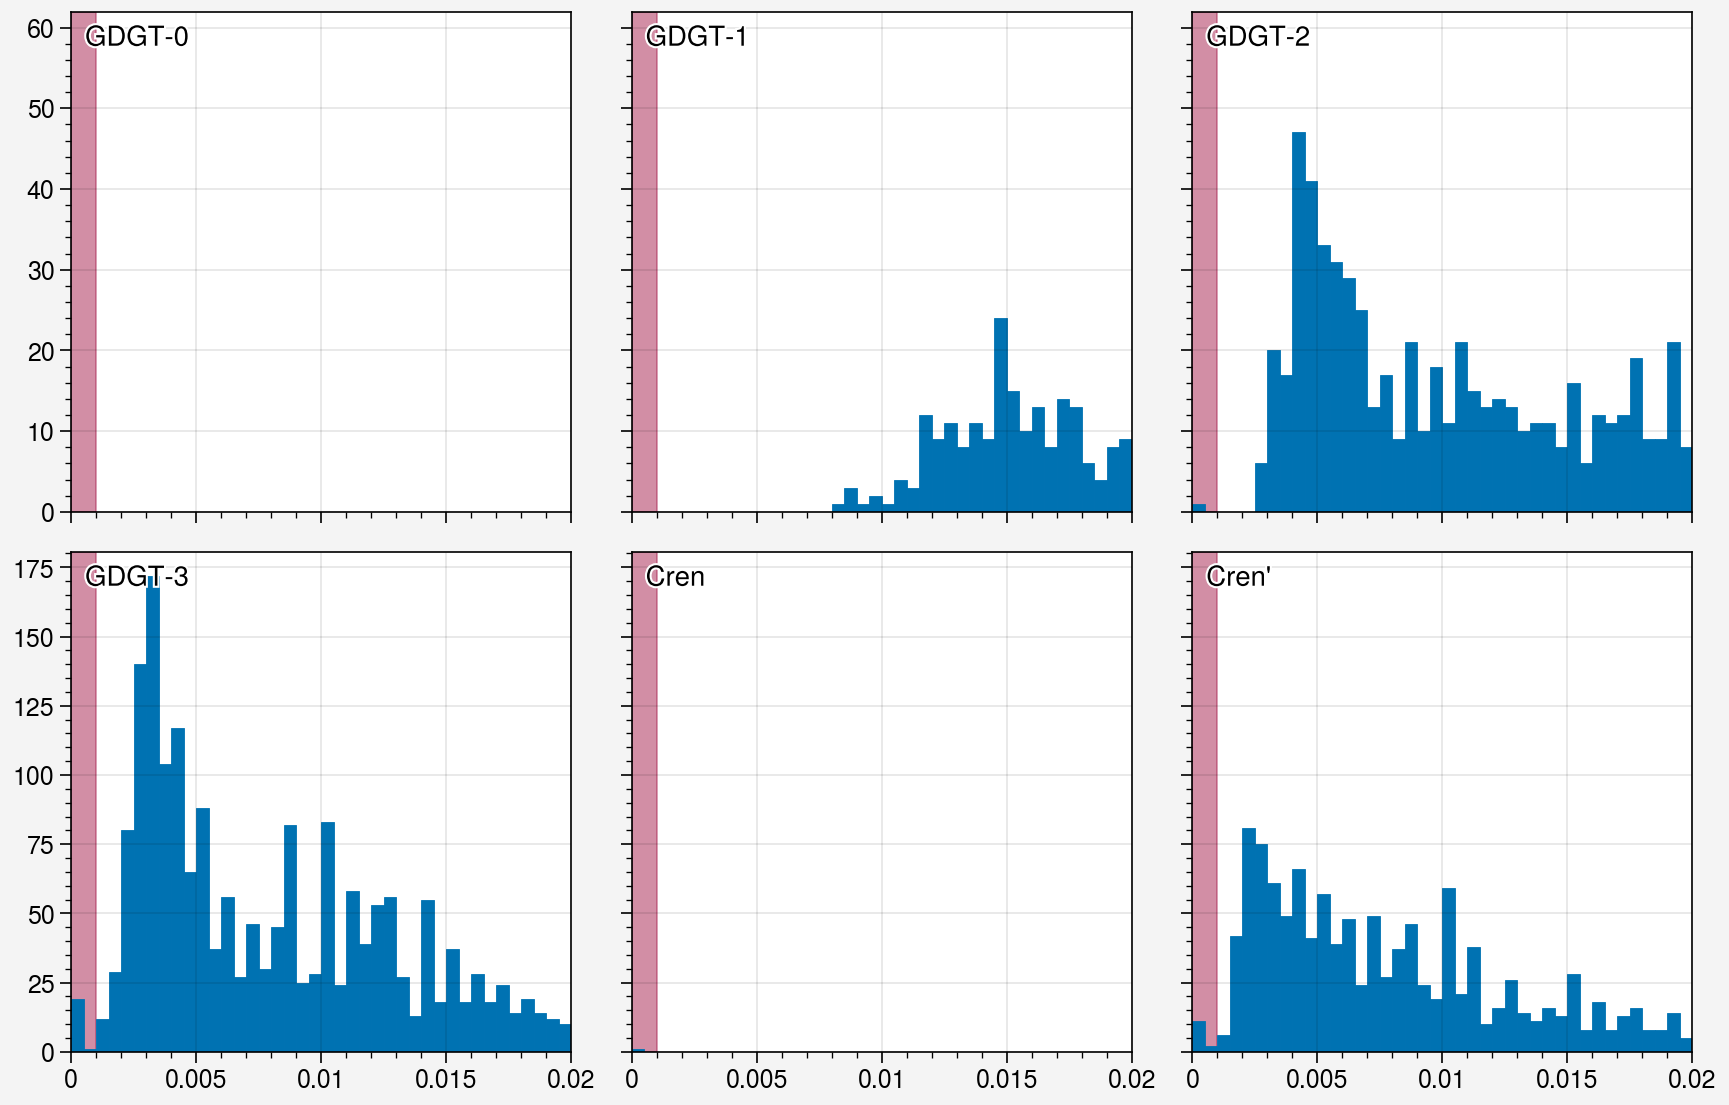

In [ ]:
fig, axs = plot.subplots(ncols=3,nrows=2)

features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']
feature_labels = ['GDGT-0', 'GDGT-1', 'GDGT-2', 'GDGT-3', 'Cren', "Cren'"]
plot_data = coretop_df.dropna(how='any',subset=features)

for i, (feature, label) in enumerate(zip(features, feature_labels)):
    ax = axs[i]
    ax.format(ultitle=f'{label}',fontweight='bold')
    XX = plot_data[feature].values
    ax.hist(XX,bins=np.arange(XX.min(),XX.max(),0.0005))
    
axs.format(xlim=(0,0.02))
axs.axvspan(0,0.001, color='pink9', alpha=0.5, edgecolor='none', zorder=0)

plt.show()

In [ ]:
len(combined_df_raw[combined_df_raw['lowAbundanceFlag']==False])

2100

coretop 28
culture 3
mesocosm 0


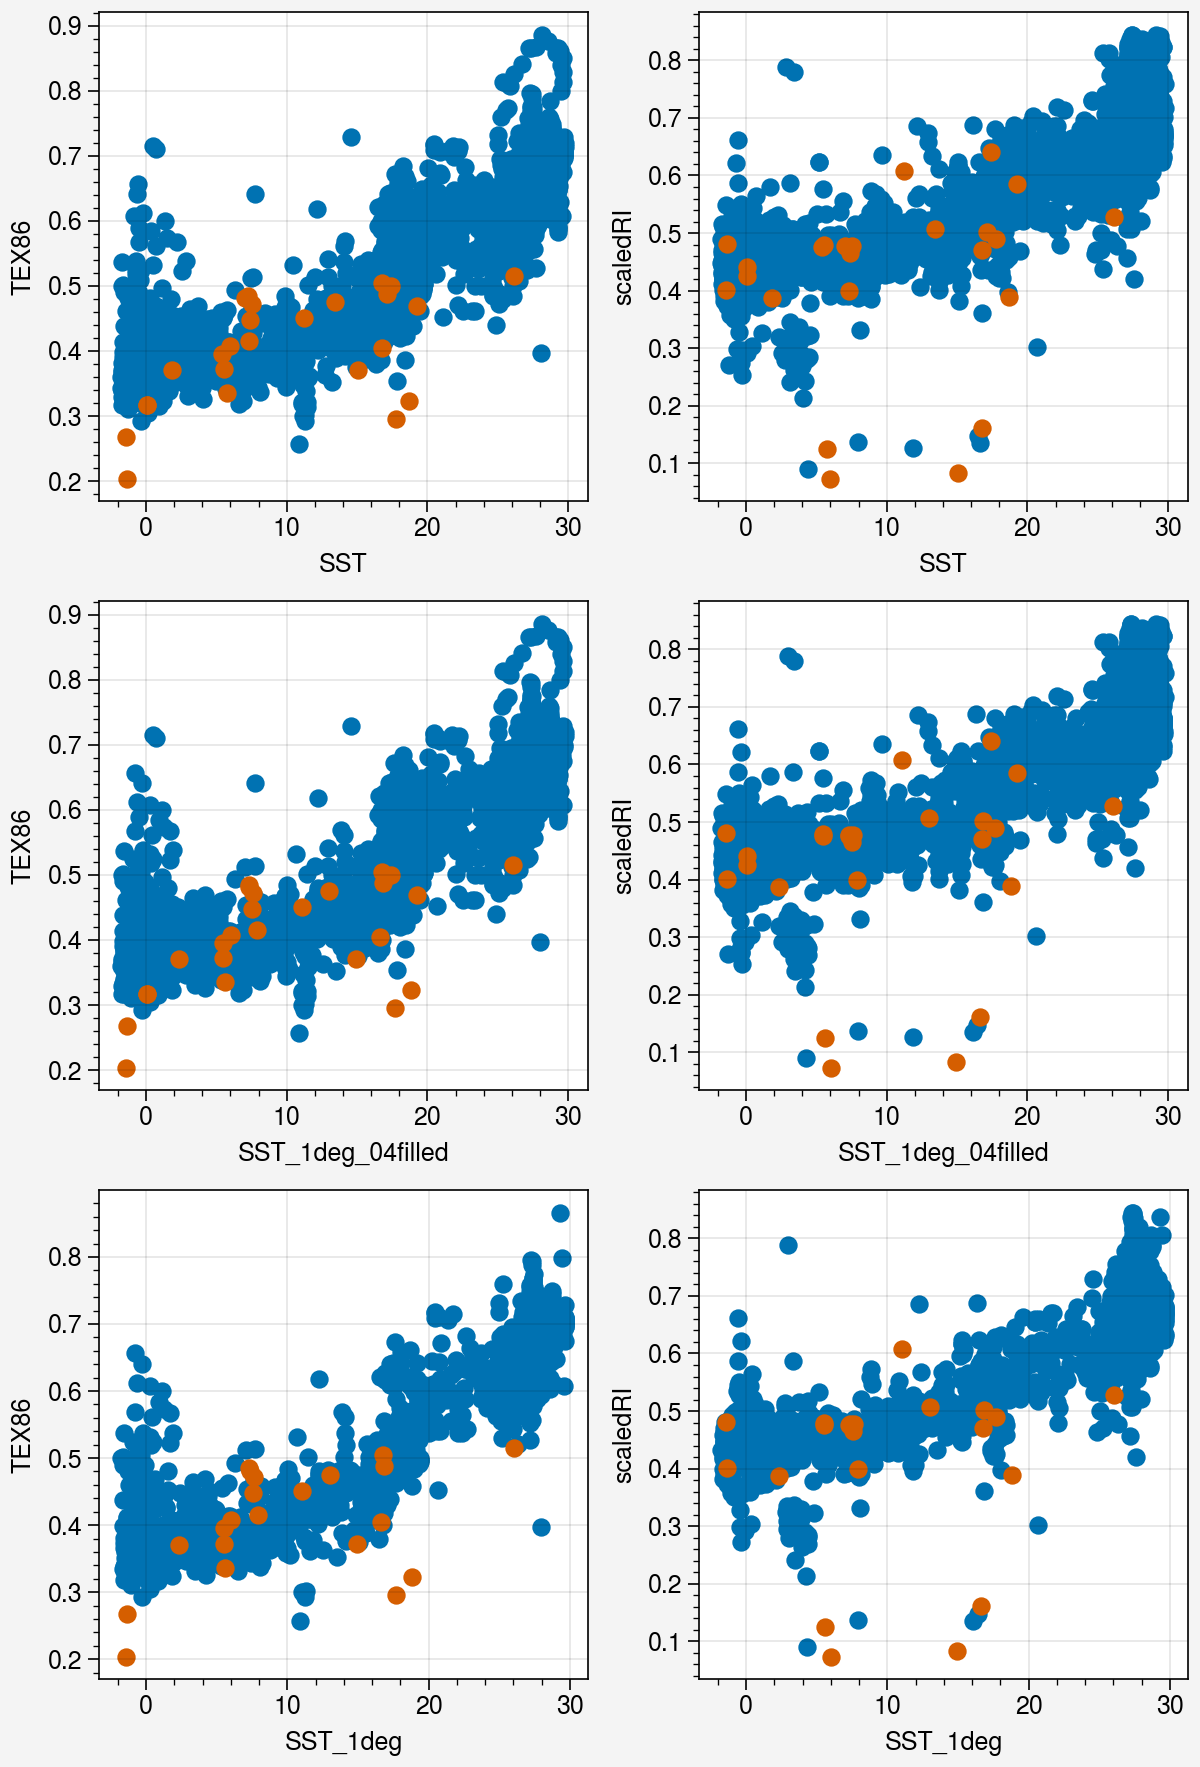

In [ ]:
fig, axs = plot.subplots(width=6,ncols=2,nrows=3,share=False)

ax = axs[0]
plot_coretop = combined_df_raw[combined_df_raw['datatype']=='coretop']
temp_params = ['SST','SST_1deg_04filled','SST_1deg']
grouped = plot_coretop.groupby('lowAbundanceFlag')

for j, temp_param in enumerate(temp_params):
    for i, (name, group) in enumerate(grouped):
        axs[j,0].scatter(group[temp_param], group['TEX86'], label=f'Low Abundance: {name}')
        axs[j,1].scatter(group[temp_param], group['scaledRI'], label=f'Low Abundance: {name}')

grouped = combined_df_raw.groupby('datatype')
for name, group in grouped:
    print(name, len(group[group['lowAbundanceFlag']==True]))

## 3.2 Ring Index as a predictand

coretop
 full -- name: coretop, TEX86 vs SST: spearman rho: 0.871, p-value: 0.000e+00
 full -- name: coretop, RI vs SST: spearman rho: 0.852, p-value: 0.000e+00
mesocosm
 full -- name: mesocosm, TEX86 vs SST: spearman rho: 0.890, p-value: 6.825e-08
 full -- name: mesocosm, RI vs SST: spearman rho: 0.855, p-value: 8.086e-07
culture
 full -- name: culture, TEX86 vs SST: spearman rho: 0.615, p-value: 6.192e-10
 full -- name: culture, RI vs SST: spearman rho: 0.763, p-value: 5.207e-17
 overall TEX86 vs SST: spearman rho: 0.856, p-value: 0.000e+00
 overall RI vs SST: spearman rho: 0.842, p-value: 0.000e+00


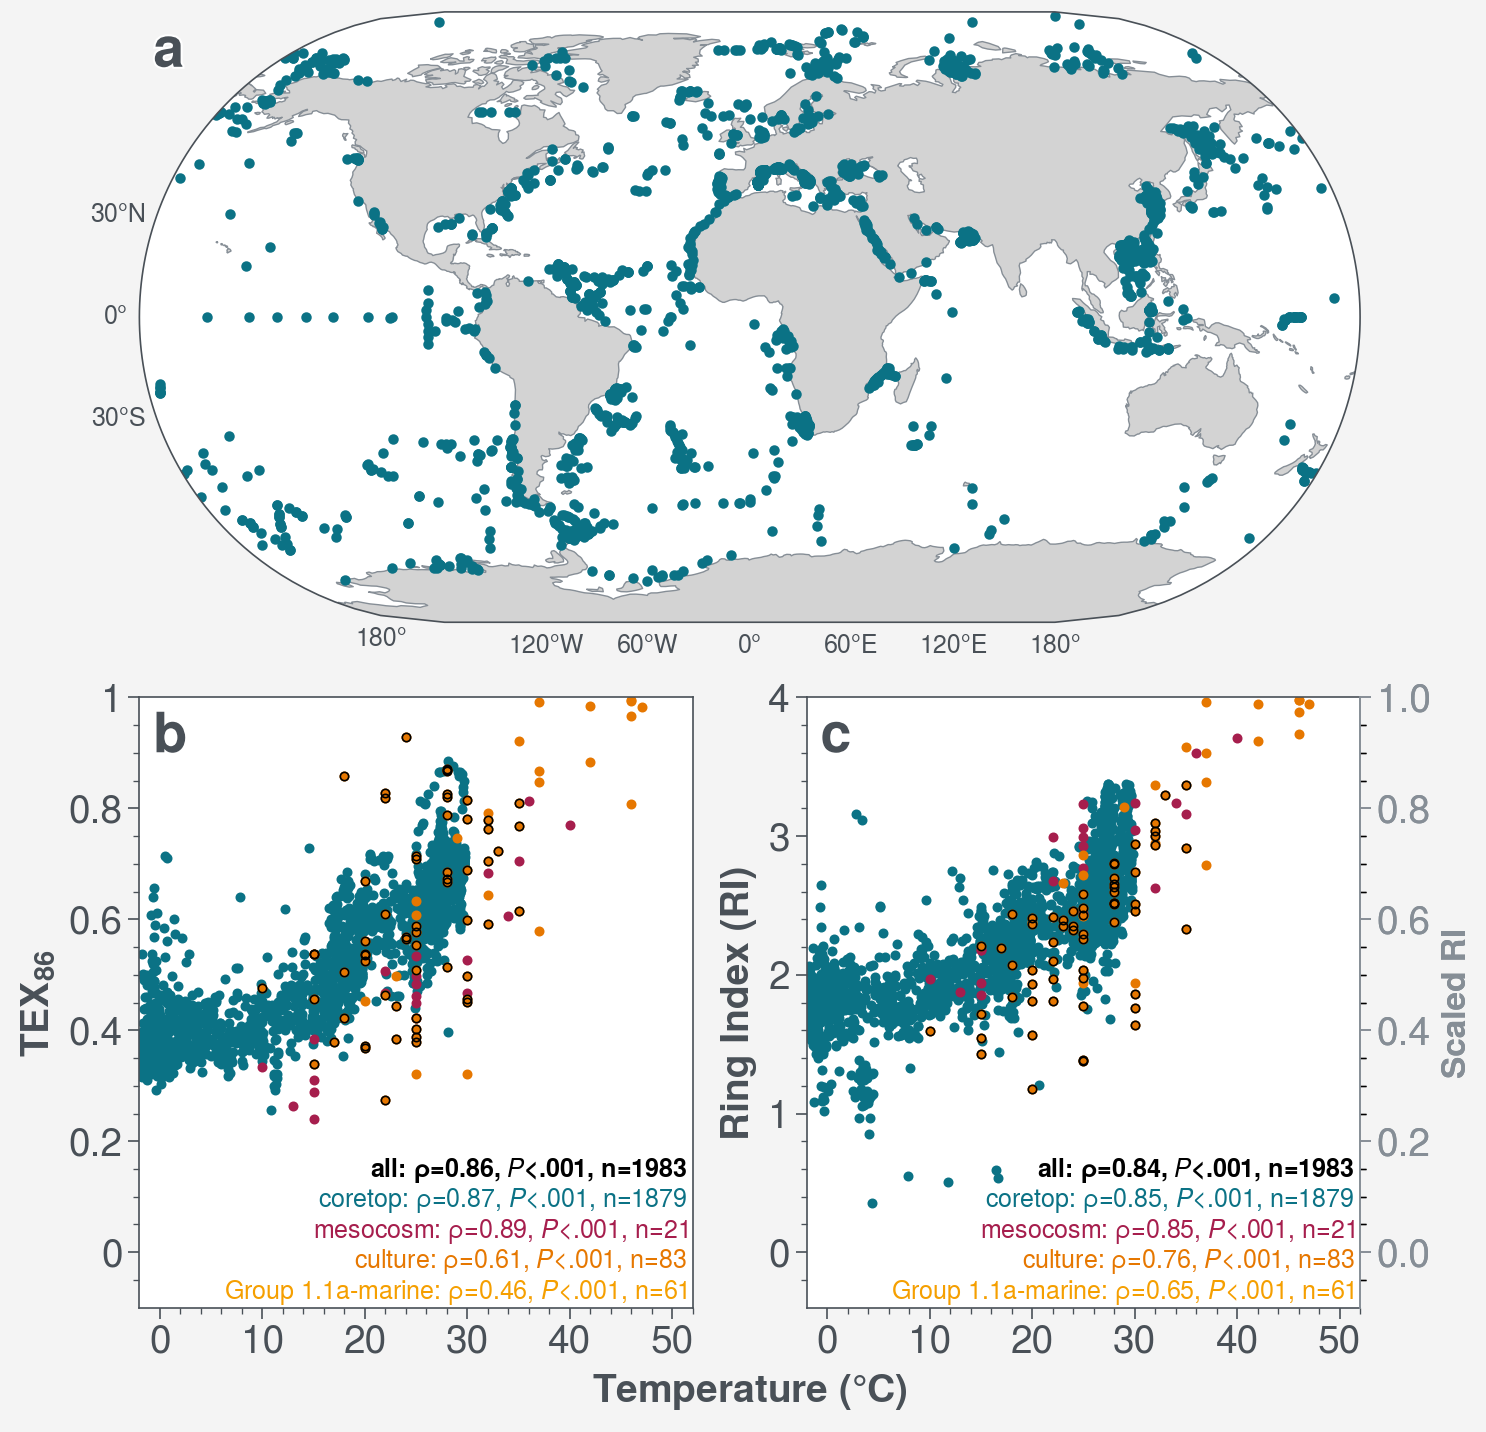

In [ ]:
array = [
    [1,1],
    [2,3]
]
fig, axs = plot.subplots(array,width=8,sharey=0,proj={1:'eck3'})

plot_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False]
# plot_data = plot_data[plot_data['TEXRI_mahalDist_low23ratio_outliers_manual']==False]
# plot_data = plot_data[~plot_data['reference_name'].str.contains('Varma')] 
plot_data = plot_data.sort_values('datatype', key=lambda x: x.map({'coretop': 0, 'mesocosm': 1, 'culture': 2})).reset_index(drop=True)
### plot_data sort ['coretop_df','mesocosm','culture']

ax = axs[0,0]
ax.format(land=True, landcolor='lightgray', landzorder=0,
          coast=True, coastcolor='gray6', coastzorder=1,coastlinewidth=0.5,
          latlabels=True, lonlabels=True,)
plot_lat = plot_data[plot_data['datatype']=='coretop']['Latitude']
plot_lon = plot_data[plot_data['datatype']=='coretop']['Longitude']
sc = ax.scatter(plot_lon, plot_lat, c=datatype_color_dict.get('coretop','gray'), 
                s=10, marker='o', label='coretop',zorder=2)

grouped = plot_data.groupby('datatype', sort=False)
for i, (name, group) in enumerate(grouped):
    print(name)
    plot_x = group['SST']
    plot_x2 = group['t_sf2tc_avg']
    plot_y = group['TEX86']
    plot_y2 = group['ringIndex']
    
    axs[1,0].scatter(plot_x, plot_y, label=name, m='.',c=datatype_color_dict.get(name,'gray'))
    axs[1,1].scatter(plot_x, plot_y2, label=name, m='.',c=datatype_color_dict.get(name,'gray'))
    
    if name == 'culture':
        marine_group11a_idx = group[group['organism_broadClass3'].isin(['Group 1.1a-marine'])].index
        plot_xxx = group.loc[marine_group11a_idx, 'SST']
        plot_xxx2 = group.loc[marine_group11a_idx, 't_sf2tc_avg']
        plot_yyy = group.loc[marine_group11a_idx, 'TEX86']
        plot_yyy2 = group.loc[marine_group11a_idx, 'ringIndex']
        
        axs[1,0].scatter(plot_xxx, plot_yyy, label='Group 1.1a-marine', edgecolor='black', facecolor='none', m='.', zorder=3)
        axs[1,1].scatter(plot_xxx, plot_yyy2, label='Group 1.1a-marine', edgecolor='black', facecolor='none', m='.', zorder=3)
        
        ###
        nonnan_idx_11a = (~plot_xxx.isna()) & (~plot_yyy.isna())
        reg_x_11a = plot_xxx[nonnan_idx_11a]
        reg_y_11a = plot_yyy[nonnan_idx_11a]
        rho_11a, pval_11a = spearmanr(reg_x_11a, reg_y_11a)
        pval_label_11a = label_pvalues(pval_11a)
        

        axs[1,0].text(0.99, 0.15-(0.05*i), fr'Group 1.1a-marine: $\rho$={rho_11a:.2f}, {pval_label_11a}, n={len(reg_y_11a)}',
                        transform=axs[1,0].transAxes,
                        ha='right',va='top',
                        fontsize=9, color='yellow7')
        rho2_11a, pval2_11a = spearmanr(reg_x_11a, plot_yyy2[nonnan_idx_11a])
        pval_label2_11a = label_pvalues(pval2_11a)
        axs[1,1].text(0.99, 0.15-(0.05*i), fr'Group 1.1a-marine: $\rho$={rho2_11a:.2f}, {pval_label2_11a}, n={len(reg_y_11a)}',
                        transform=axs[1,1].transAxes,
                        ha='right',va='top',
                        fontsize=9, color='yellow7')
        
        
    
    ### spearman rho and p-value of each group
    nonnan_idx = (~plot_x.isna()) & (~plot_y.isna())
    reg_x = plot_x[nonnan_idx]
    reg_y = plot_y[nonnan_idx]
    rho, pval = spearmanr(reg_x, reg_y)
    print(f' full -- name: {name}, TEX86 vs SST: spearman rho: {rho:.3f}, p-value: {pval:.3e}')
    
    nonnan_idx2 = (~plot_x.isna()) & (~plot_y2.isna())
    reg_x2 = plot_x[nonnan_idx2]
    reg_y2 = plot_y2[nonnan_idx2]
    rho2, pval2 = spearmanr(reg_x2, reg_y2)
    print(f' full -- name: {name}, RI vs SST: spearman rho: {rho2:.3f}, p-value: {pval2:.3e}')
    
    
    ### annotate spearman rho and p-value of each group at lower right corner
    pval_label = label_pvalues(pval)
    label_text = fr'{name}: $\rho$={rho:.2f}, {pval_label}, n={len(reg_y)}'
    axs[1,0].text(0.99, 0.2-(0.05*i), label_text, transform=axs[1,0].transAxes,
                  ha='right',va='top',
                  fontsize=9, color=datatype_color_dict.get(name,'gray'))
    
    pval_label2 = label_pvalues(pval2)
    label_text2 = fr'{name}: $\rho$={rho2:.2f}, {pval_label2}, n={len(reg_y2)}'
    axs[1,1].text(0.99, 0.2-(0.05*i), label_text2, transform=axs[1,1].transAxes,
                  ha='right',va='top',
                  fontsize=9, color=datatype_color_dict.get(name,'gray'))

###
reg_XX = plot_data['SST']
reg_YY = plot_data['TEX86']
nonnan_idx = (~reg_XX.isna()) & (~reg_YY.isna())
reg_X = reg_XX[nonnan_idx].values.reshape(-1,1)
reg_Y = reg_YY[nonnan_idx].values
rho_all, pval_all = spearmanr(reg_X, reg_Y)
print(f' overall TEX86 vs SST: spearman rho: {rho_all:.3f}, p-value: {pval_all:.3e}')
pval_label_all = label_pvalues(pval_all)
label_text_all = fr'all: $\rho$={rho_all:.2f}, {pval_label_all}, n={len(reg_Y)}'
axs[1,0].text(0.99, 0.25, label_text_all, transform=axs[1,0].transAxes,
              ha='right',va='top',
              fontsize=9, fontweight='bold', color='black')
    
reg_XX2 = plot_data['SST']
reg_YY2 = plot_data['ringIndex']
nonnan_idx2 = (~reg_XX2.isna()) & (~reg_YY2.isna())
reg_X2 = reg_XX2[nonnan_idx2].values.reshape(-1,1)
reg_Y2 = reg_YY2[nonnan_idx2].values
rho_all2, pval_all2 = spearmanr(reg_X2, reg_Y2)
print(f' overall RI vs SST: spearman rho: {rho_all2:.3f}, p-value: {pval_all2:.3e}')
pval_label_all2 = label_pvalues(pval_all2)
label_text_all2 = fr'all: $\rho$={rho_all2:.2f}, {pval_label_all2}, n={len(reg_Y2)}'
axs[1,1].text(0.99, 0.25, label_text_all2, transform=axs[1,1].transAxes,
              ha='right',va='top',
              fontsize=9, fontweight='bold', color='black')
    

###    
axs[1:,0].format(ylim=(-0.1,1),yticks=np.arange(0,1.2,0.2),ylabel=r'TEX$_{86}$')
axs[1:,1].format(ylim=(-0.4,4),yticks=np.arange(0,5,1),ylabel='Ring Index (RI)')


### Create a twin axis for the right side
ax_right = axs[1,1].twinx()
# Match the y-limits
ax_right.set_ylim(axs[1,1].get_ylim())

# Set the tick positions (same as left)
yticks = np.linspace(0,4,6)
ax_right.set_yticks(yticks)
right_labels = [f'{(tick/4):.1f}' for tick in yticks]
ax_right.set_yticklabels(right_labels,fontsize=14)
ax_right.set_ylabel('Scaled RI', fontsize=12, fontweight='bold')
ax_right.yaxis.label.set_color('gray6')
ax_right.tick_params(axis='y', colors='gray6')
ax_right.spines['right'].set_edgecolor('gray6')

axs.format(
    labelsize=14,
    fontsize=14,
    labelweight='bold',
    xlim=(-2,52),
    grid=False,
)

axs.format(
    xlabel=r'Temperature ($\degree$C)',
    abc=True,abcstyle='a',abcsize=20,abcweight='bold',abcloc='ul',
    abccolor='gray7',
    labelcolor='gray7',
    textcolor='gray7',
    tickcolor='gray7',
    ticklabelcolor='gray7',
)

for ax in axs:
    ax.spines[:].set_color('gray7')

# h, l = axs[1,0].get_legend_handles_labels()
# axs[1].legend(h, l, loc='ul', ncols=1, fontsize=14)


fpath = fr'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'fig3_coretop_TEX86_SST_RI_scatter'
fig.savefig(os.path.join(fpath, fname+'.pdf'), dpi=300)


 overall -- feature: fGDGT_0, spearman rho: -0.903, p-value: 0.000e+00
 overall -- feature: fGDGT_1, spearman rho: 0.483, p-value: 1.534e-116
 overall -- feature: fGDGT_2, spearman rho: 0.801, p-value: 0.000e+00
 overall -- feature: fGDGT_3, spearman rho: 0.813, p-value: 0.000e+00
 overall -- feature: fGDGT_cren, spearman rho: 0.683, p-value: 5.509e-273
 overall -- feature: fGDGT_cren_prime, spearman rho: 0.765, p-value: 0.000e+00


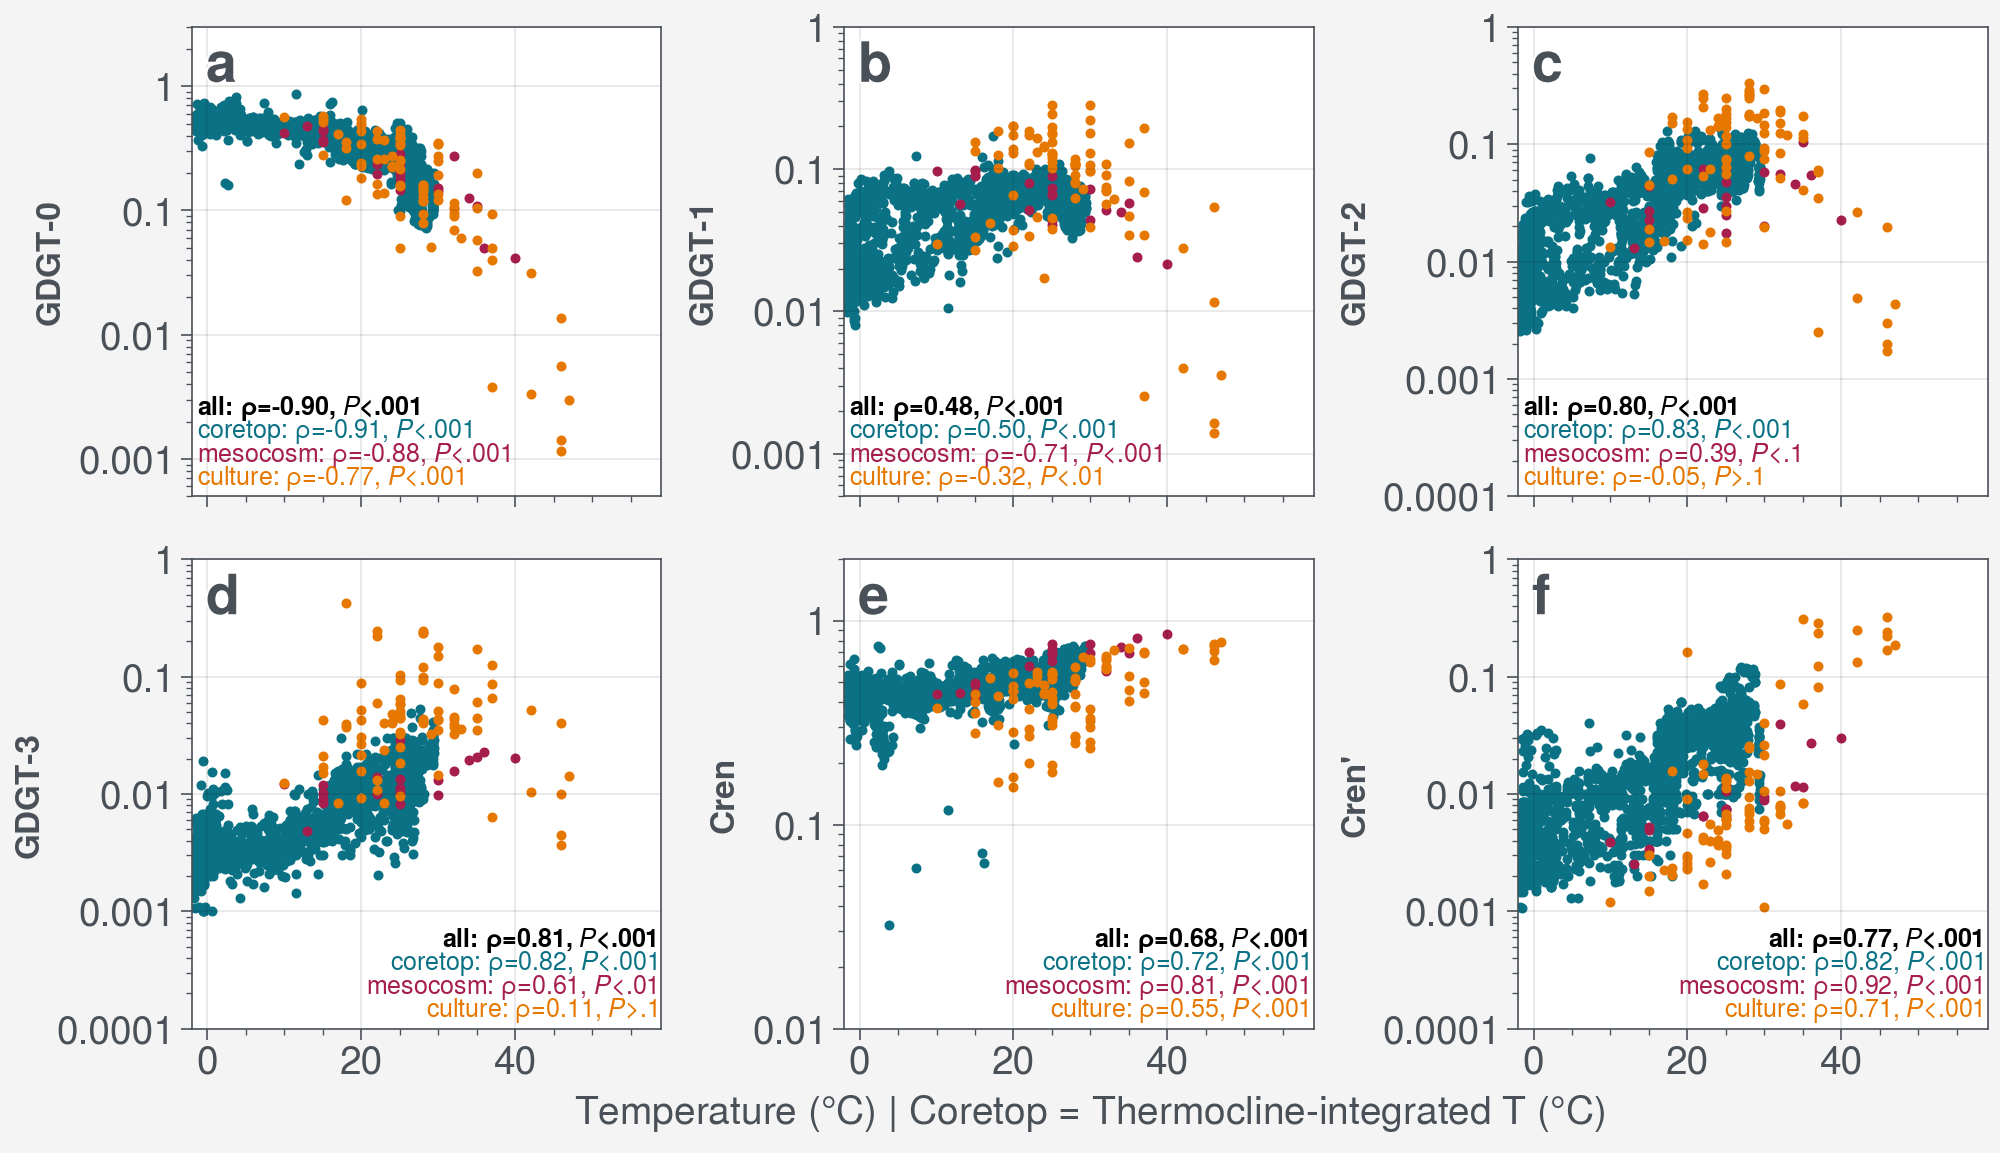

In [ ]:
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
feature_labels = ['GDGT-0', 'GDGT-1', 'GDGT-2', 'GDGT-3', 'Cren', "Cren'"]

fig, axs = plot.subplots(ncols=3,nrows=2,width=10,sharey=False)
plot_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False]
plot_data = plot_data.sort_values('datatype', key=lambda x: x.map({'coretop': 0, 'mesocosm': 1, 'culture': 2})).reset_index(drop=True)
grouped = plot_data.groupby('datatype', sort=False)
for i, (feature, label) in enumerate(zip(features, feature_labels)):
    ax = axs[i]
    
    nonnan_idx = (~plot_data['t_sf2tc_avg'].isna()) & (~plot_data[feature].isna())
    reg_x = plot_data.loc[nonnan_idx, 't_sf2tc_avg']
    reg_y = plot_data.loc[nonnan_idx, feature]
    rho_all, pval_all = spearmanr(reg_x, reg_y)
    print(f' overall -- feature: {feature}, spearman rho: {rho_all:.3f}, p-value: {pval_all:.3e}')
    pval_label_all = label_pvalues(pval_all)
    label_text_all = fr'all: $\rho$={rho_all:.2f}, {pval_label_all}'
    
    if feature in ['fGDGT_0', 'fGDGT_1', 'fGDGT_2']:
        ypos = 0.22
        xpos = 0.01
        ha = 'left'
    else:
        ypos = 0.22
        xpos = 0.99
        ha = 'right'
    ax.text(xpos, ypos, label_text_all, transform=ax.transAxes,
              ha=ha,va='top',
              fontsize=9, fontweight='bold', color='black')
    for j, (name, group) in enumerate(grouped):
        ax.scatter(group['t_sf2tc_avg'], group[feature], label=name, m='.',c=datatype_color_dict.get(name,'gray'))
        
        nonnan_idx = (~group['t_sf2tc_avg'].isna()) & (~group[feature].isna())
        reg_x = group.loc[nonnan_idx, 't_sf2tc_avg']
        reg_y = group.loc[nonnan_idx, feature]
        rho, pval = spearmanr(reg_x, reg_y)
        pval_label = label_pvalues(pval)
        
        if feature in ['fGDGT_0', 'fGDGT_1', 'fGDGT_2']:
            ypos = 0.17 - (0.05*j)
            xpos = 0.01
            ha = 'left'
        else:
            ypos = 0.17 - (0.05*j)
            xpos = 0.99
            ha = 'right'
        ax.text(xpos, ypos, 
                fr'{name}: $\rho$={rho:.2f}, {pval_label}',
                transform=ax.transAxes,
                ha=ha,va='top',
                fontsize=9, color=datatype_color_dict.get(name,'gray'))
        
        
        
axs.format(
    abc=True,abcstyle='a',abcsize=20,abcweight='bold',abcloc='ul',abccolor='gray7',
    xlim=(-2,59),
    labelcolor='gray7',
    textcolor='gray7',
    tickcolor='gray7',
    ticklabelcolor='gray7',
    yscale='log',
    fontsize=14,
    xlabel=r'Temperature ($\degree$C) | Coretop = Thermocline-integrated T ($\degree$C)',
)


ylims_list = [(5e-4,3e0),(5e-4,1e0),(1e-4,1e0),(1e-4,1e0),(1e-2,2e0),(1e-4,1e0),]
ylabels_list = ['GDGT-0', 'GDGT-1', 'GDGT-2', 'GDGT-3', 'Cren', "Cren'"]
for ax, ylim, ylabel in zip(axs, ylims_list, ylabels_list):
    ax.set_ylim(ylim)
    ax.set_ylabel(ylabel=ylabel, fontsize=12, fontweight='bold')

for ax in axs:
    ax.spines[:].set_color('gray7')
    
fpath = fr'{local_github_path}/figures/manuscript/finalized/supplementary'
fname = 'figS1_coretop_culture_mesocosm_fractinal_GDGTs_vs_Temp.pdf'
fig.savefig(os.path.join(fpath, fname), dpi=300)

## 3.3 Data screening: traditional vs data driven approach

### 3.3.1 prefiltering combined coretop_df

In [ ]:
coretop_idx = combined_df_raw[combined_df_raw['datatype']=='coretop'].index

QC_indices_dict = {
    'BIT':0.5,
    'methaneIndex':0.5,
    'ZeroOverZeroCren':0.67
    }

new_cols = ['BIT_flag','methaneIndex_flag','ZeroOverZeroCren_flag']
for col, threshold in QC_indices_dict.items():
    flag_col = f'{col}_flag'
    combined_df_raw[flag_col] = 'included'
    combined_df_raw.loc[coretop_idx, flag_col] = ['excluded' if row >= threshold else 'included' for row in combined_df_raw.loc[coretop_idx, col]]
    
    
combined_df_raw['QCflag_indices'] = 'included'
for idx in coretop_idx:
    row = combined_df_raw.loc[idx]
    if 'excluded' in [row[col] for col in new_cols]:
        combined_df_raw.at[idx, 'QCflag_indices'] = 'excluded'
combined_df_raw[combined_df_raw['QCflag_indices']=='excluded']


,sampleID,Latitude,Longitude,match_lat_04deg,match_lon_04deg,match_lat_1deg,match_lon_1deg,modernWaterDepth,t_sf2tc_avg,t_sf2tc_1deg_04filled,...,TEXRIfG0_mahalDist_low23ratio_outliers_manual,TEXRIpercentG0_mahalDist_low23ratio,TEXRIpercentG0_mahalDist_low23ratio_outliers,TEXRIpercentG0_mahalDist_low23ratio_outliers_manual,TEXRIfG0Cren_mahalDist_low23ratio,TEXRIfG0Cren_mahalDist_low23ratio_outliers,TEXRIfG0Cren_mahalDist_low23ratio_outliers_manual,allGDGTs_mahalDist_low23ratio,allGDGTs_mahalDist_low23ratio_outliers,allGDGTs_mahalDist_low23ratio_outliers_manual
44,TEXAS_RR_0044,-22.22,-176.61,-22.12,-176.62,-22.50,-176.50,1744.00,24.49,24.83,...,True,7.17,True,True,5.59,True,True,6.72,True,True
83,TEXAS_RR_0083,-44.15,-75.15,-44.12,-75.12,-44.50,-75.50,301.00,11.49,11.49,...,True,7.13,True,True,5.87,True,True,5.11,True,True
664,TEXAS_RR_0664,38.19,176.70,38.12,176.62,38.50,176.50,4522.00,15.92,16.04,...,True,5.83,True,True,6.91,True,True,7.01,True,True
665,TEXAS_RR_0665,37.77,176.27,37.88,176.38,37.50,176.50,3573.00,16.18,16.31,...,True,5.13,True,True,6.78,True,True,8.48,True,True
669,TEXAS_RR_0669,38.89,157.63,38.88,157.62,38.50,157.50,5535.00,16.14,16.14,...,True,5.95,True,True,6.64,True,True,6.66,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017,TEXAS_RR_2017,72.75,-67.02,72.62,-67.12,72.50,-67.50,2373.00,-0.38,-0.12,...,False,3.06,True,True,2.50,False,False,2.69,False,False
2018,TEXAS_RR_2018,71.41,-70.89,71.38,-70.88,71.50,-70.50,702.00,0.54,NaN,...,False,2.72,True,True,2.15,False,False,3.86,True,True
2019,TEXAS_RR_2019,69.60,-65.40,69.62,-65.38,69.50,-65.50,267.00,-0.63,-0.74,...,True,3.38,True,True,2.76,False,False,3.47,True,True
2020,TEXAS_RR_2020,69.41,-64.40,69.38,-64.38,69.50,-64.50,1054.00,-0.53,-0.53,...,False,3.56,True,True,2.79,True,True,2.99,False,False


### 3.3.2 Traditional screening indices

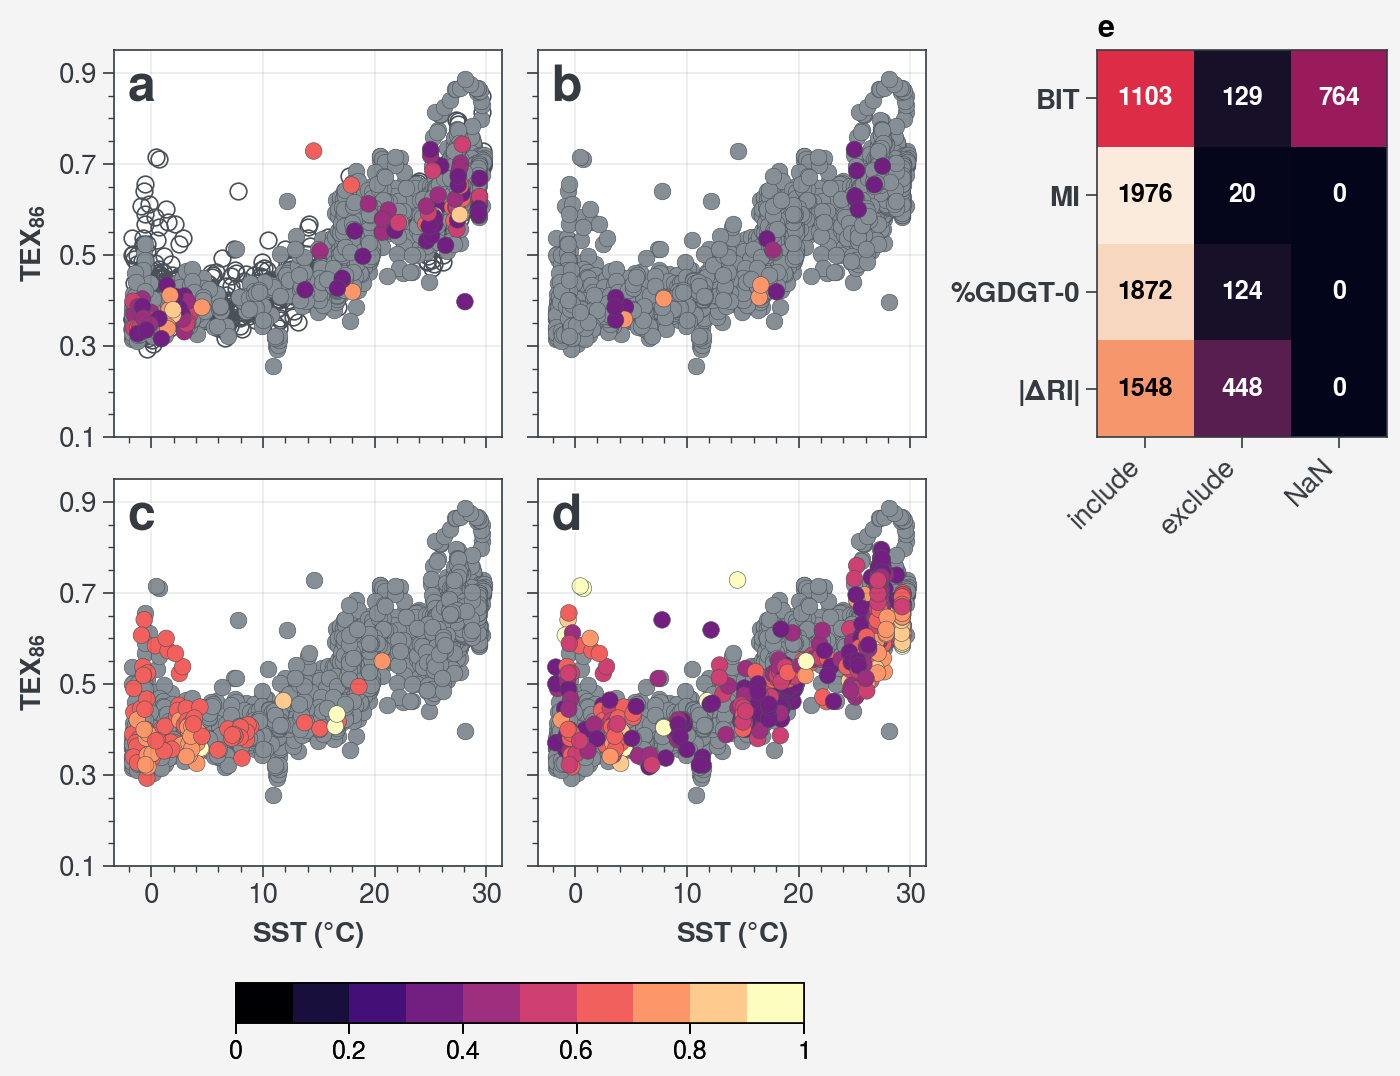

In [ ]:
QC_indices = ['BIT','methaneIndex','ZeroOverZeroCren','abs_deltaRI']
QC_thresholds = [0.3,0.3,0.6,0.3]

array = [
    [1,2,5],
    [3,4,0]
]

fig, axs = plot.subplots(array,width=7,
                         wratios=[1,1,0.75],
                         share=0
                         )

plot_data = combined_df_raw[combined_df_raw['datatype']=='coretop'][
    combined_df_raw['lowAbundanceFlag']==False].reset_index(drop=True)
arrays = np.zeros((4,3))


for i, (QC_index, qc_thr) in enumerate(zip(QC_indices, QC_thresholds)):
    good_data = (plot_data[QC_index]<=qc_thr).sum()
    bad_data = (plot_data[QC_index]>qc_thr).sum()
    nan_data = plot_data[QC_index].isna().sum()
    arrays[i,:] = [good_data,bad_data,nan_data]

    good_data_idx = plot_data[QC_index]<=qc_thr
    bad_data_idx = plot_data[QC_index]>qc_thr
    nan_data_idx = plot_data[QC_index].isna()
    
    plot_x = plot_data['SST']
    plot_y = plot_data['TEX86']

    ax = axs[i]
    ax.scatter(plot_x[nan_data_idx],plot_y[nan_data_idx],
               facecolor='none',m='o',mec='gray7',zorder=0)
    ax.scatter(plot_x[good_data_idx],plot_y[good_data_idx],
               m='o',c='gray6',mec='gray7',mew=0.2)
    m = ax.scatter(plot_x[bad_data_idx],plot_y[bad_data_idx],
               m='o',c=plot_data[QC_index][bad_data_idx],
               levels=np.arange(0,1.1,0.1), 
               mec='gray7',mew=0.2,
               cmap='magma')
cbar = fig.colorbar(m,loc='b',col=[1,2],shrink=0.7)

coretop_qc_df = pd.DataFrame(arrays, index=pd.Index(['BIT','MI','%GDGT-0','|$\Delta$RI|']))
axs[0,-1].heatmap(coretop_qc_df,
                  cmap='rocket',labels=True,labels_kw={'weight':'bold'})

axs[0,-1].format(yreverse=True,
           xticklabels=['include','exclude','NaN'],
           xrotation=45,
           yticklabelweight='bold')


axs.format(gridcolor='gray8')

axs[:,:-1].format(xlabel=r'SST ($\degree$C)',
                ylabel=r'TEX$_{86}$',
                yticks=np.arange(0.1,0.95,0.2),
                ylim=(0.1,0.95))
axs[:,1].format(ylabel='',
                yticklabels=[])
axs[0,:-1].format(xlabel='',
                xticklabels=[])

for ax in axs:
    ax.format(tickcolor='gray8',
              ticklabelcolor='gray8',
              labelcolor='gray8',
              labelweight='bold',
              labelsize=10,fontsize=10)
    for spine in ax.spines.values():
        spine.set_color('gray8')

axs[:-1].format(abc=True,abcloc='ul',
                abcsize=18,
                abccolor='gray8')

fpath = f'{local_github_path}/figures/manuscript/finalized/supplementary'
fname = 'figS2_Traditional_QC_indices.pdf'
fig.savefig(os.path.join(fpath,fname),dpi=300)

Median methaneIndex by organism_broadClass4:
organism_broadClass4
Coretop                 0.18
Group 1.1b              0.07
Marine Group 1.1a       0.39
Mesocosm                0.16
Non-marine Group 1.1a   0.40
Name: methaneIndex, dtype: float64
Median ZeroOverZeroCren by organism_broadClass4:
organism_broadClass4
Coretop                 0.44
Group 1.1b              0.03
Marine Group 1.1a       0.36
Mesocosm                0.23
Non-marine Group 1.1a   0.16
Name: ZeroOverZeroCren, dtype: float64
Median deltaRI by organism_broadClass4:
organism_broadClass4
Coretop                 -0.06
Group 1.1b               0.05
Marine Group 1.1a        0.19
Mesocosm                -0.62
Non-marine Group 1.1a   -0.44
Name: deltaRI, dtype: float64


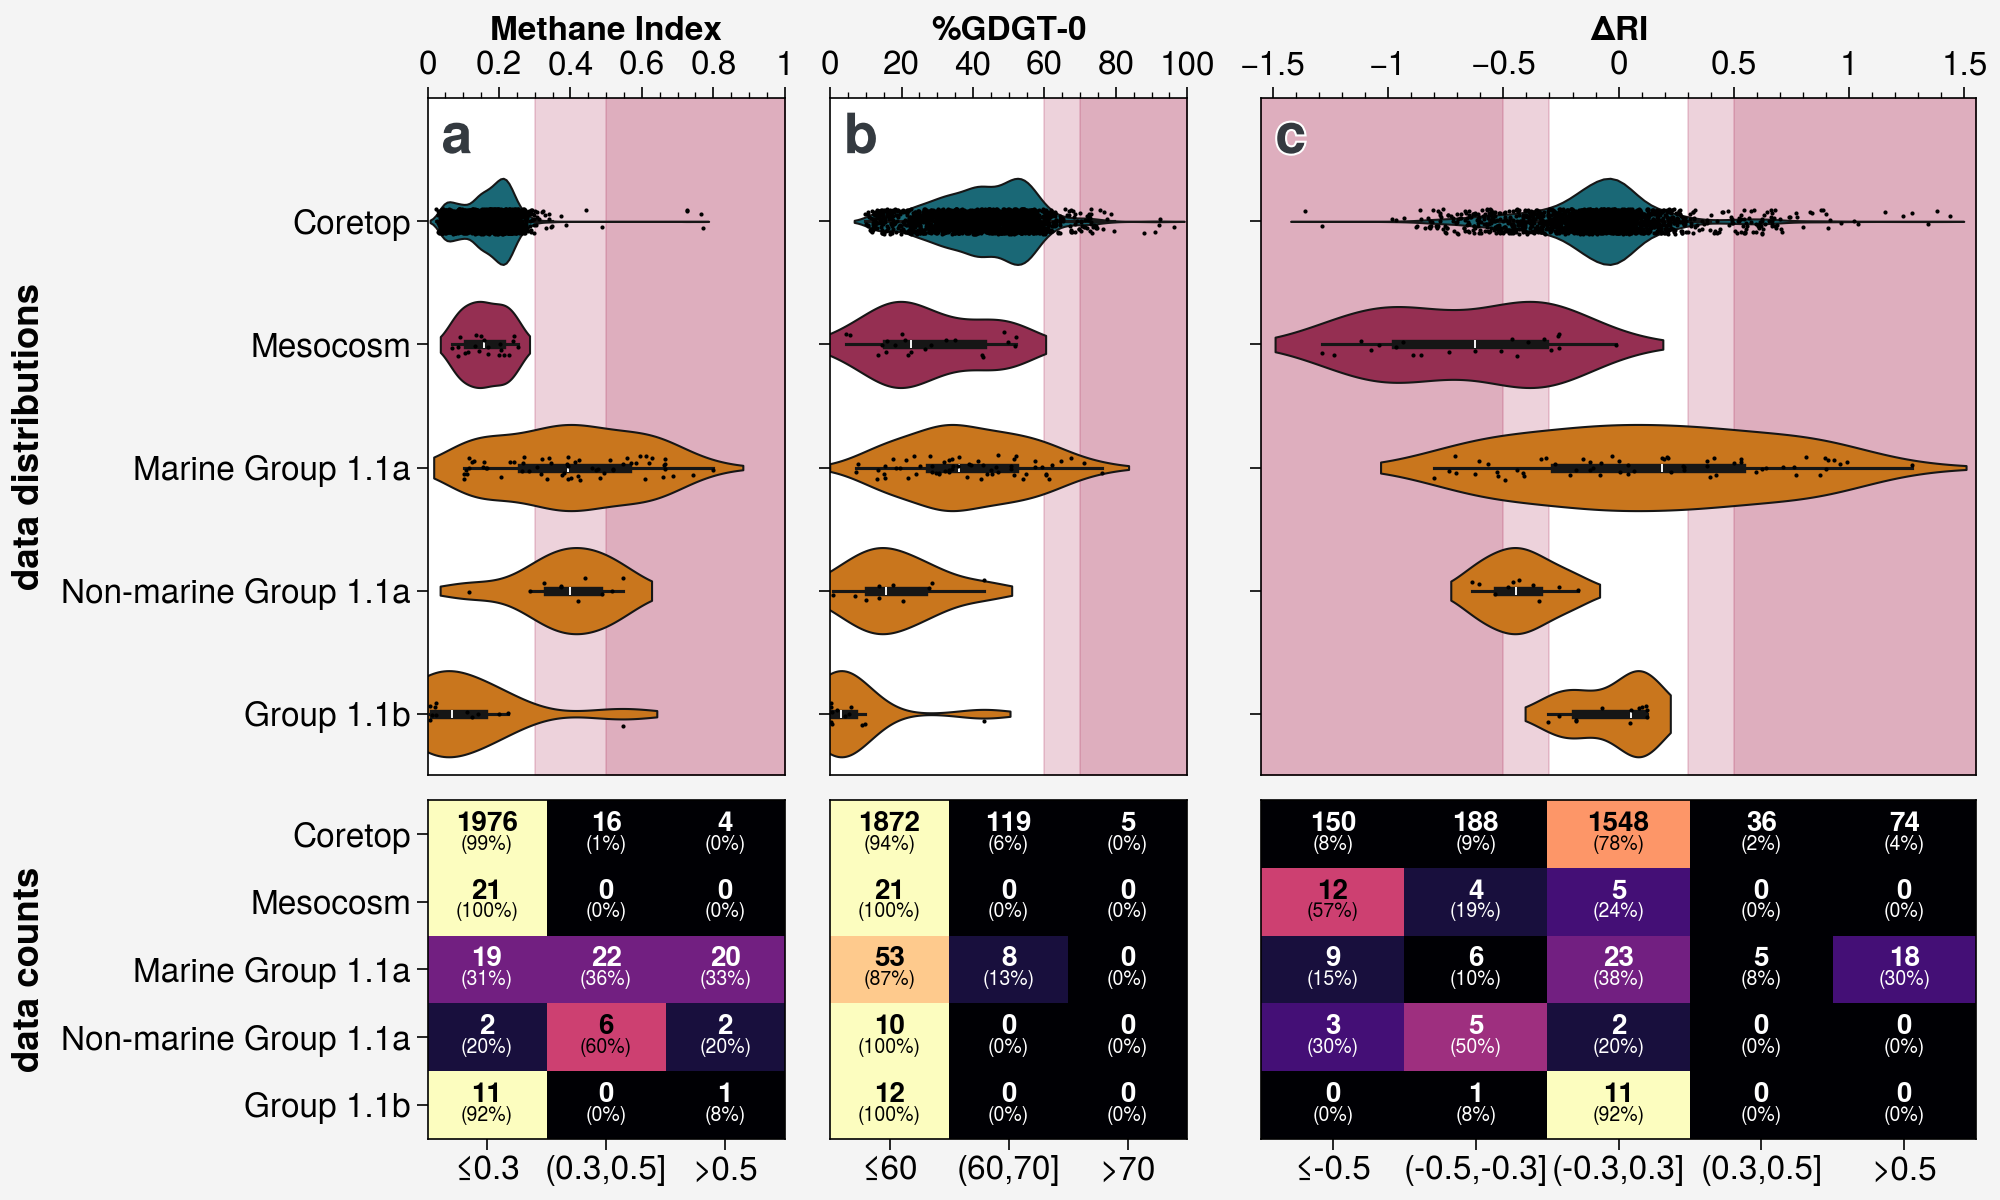

In [ ]:
x_params = ['methaneIndex','ZeroOverZeroCren','deltaRI']
x_labels = ['Methane Index','%GDGT-0','$\Delta$RI']

fig, axs = plot.subplots(figsize=(10,6),
                         ncols=len(x_params),nrows=2,
                         share=0, 
                         wratios=[1,1,2],
                         hratios=[1,0.5])

plot_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False]
# plot_data = plot_data[plot_data['TEXRI_mahalDist_outliers_manual']==False]
plot_data['organism_broadClass4'] = plot_data['organism_broadClass3']
plot_data['organism_broadClass4'] = ['Marine Group 1.1a' if '1.1a-marine' in x else
                                    'Non-marine Group 1.1a' if '1.1a' in x else
                                    'Group 1.1b' if '1.1b' in x else
                                    'Coretop' if 'coretop' in x.lower() else
                                    'Mesocosm' if 'mesocosm' in x.lower() else
                                    x for x in plot_data['organism_broadClass3']]

ordered_categories = ['Coretop','Mesocosm','Marine Group 1.1a','Non-marine Group 1.1a','Group 1.1b']
plot_data['sorted_datatype'] = pd.Categorical(plot_data['organism_broadClass4'], 
                                              categories=ordered_categories, ordered=True)
plot_data['binned_publicationYear'] = pd.cut(plot_data['publicationYear'], bins=[2000,2014,2030], labels=['pre2014','post2014'])
plot_data = plot_data.sort_values('sorted_datatype', ascending=False)

for i, x_param in enumerate(x_params):
    ax = axs[0,i]
    sns.violinplot(
        data=plot_data,
        y='organism_broadClass4',
        x=x_param,
        hue='datatype',
        ax=ax,
        palette=datatype_color_dict,
        legend=False,
        density_norm='width',
        width=0.7,
        cut=1
    )
    
    print(f'Median {x_param} by organism_broadClass4:')
    print(plot_data.groupby('organism_broadClass4')[x_param].median())
    
    sns.stripplot(
        data=plot_data,
        y='organism_broadClass4',
        x=x_param,
        ax=ax,
        legend=False,
        color='k',
        size=1.5,
    )
    
    ax.format(
        xlabel=x_labels[i],
    )
    

#### cosmetics
axs[0].format(
    ytickminor=False,
    grid=True,
    xlim=(0,1),
    xticks=np.arange(0,1.1,0.2),
)
axs[0].fill_betweenx(y=[-0.5,len(axs[0].get_yticks())], x1=0.3, x2=1, color='pink9', alpha=0.2, zorder=0)
axs[0].fill_betweenx(y=[-0.5,len(axs[0].get_yticks())], x1=0.5, x2=1, color='pink9', alpha=0.2, zorder=0)

axs[1].format(
    ytickminor=False,
    grid=True,
    xlim=(0,1),
    xticks=np.arange(0,1.1,0.2),
    xticklabels=[f'{x*100:.0f}' for x in np.arange(0,1.1,0.2)]
)
axs[1].fill_betweenx(y=[-0.5,len(axs[0].get_yticks())], x1=0.6, x2=1, color='pink9', alpha=0.2, zorder=0)
axs[1].fill_betweenx(y=[-0.5,len(axs[0].get_yticks())], x1=0.7, x2=1, color='pink9', alpha=0.2, zorder=0)



axs[2].format(
    ytickminor=False,
    grid=True,
    xlim=(-1.55,1.55),
)
axs[2].fill_betweenx(y=[-0.5,len(axs[0].get_yticks())], x1=axs[2].get_xlim()[0], x2=-0.5, color='pink9', alpha=0.2, zorder=0)
axs[2].fill_betweenx(y=[-0.5,len(axs[0].get_yticks())], x1=axs[2].get_xlim()[0], x2=-0.3, color='pink9', alpha=0.2, zorder=0)
axs[2].fill_betweenx(y=[-0.5,len(axs[0].get_yticks())], x1=0.3,x2=axs[2].get_xlim()[1], color='pink9', alpha=0.2, zorder=0)
axs[2].fill_betweenx(y=[-0.5,len(axs[0].get_yticks())], x1=0.5,x2=axs[2].get_xlim()[1], color='pink9', alpha=0.2, zorder=0)

axs[0,:].format(ylabel='',
           ylim=(-0.5, len(axs[0].get_yticks())),
           yticklabels=ordered_categories[::-1],)

### heatmap
for i, x_param in enumerate(x_params):
    plot_heatmap_data = plot_data.copy()
    plot_heatmap_data['x_bin'] = pd.cut(plot_heatmap_data[x_param], 
                                        bins=[-np.inf,0.3,0.5,np.inf] if x_param=='methaneIndex' else
                                        [-np.inf,0.6,0.8,np.inf] if x_param=='ZeroOverZeroCren' else
                                        [-np.inf,-0.5,-0.3,0.3,0.5,np.inf])
    heatmap_df = plot_heatmap_data.pivot_table(index='organism_broadClass4',
                                                columns='x_bin',
                                                values='TEX86',
                                                aggfunc='count',
                                                sort=False).reset_index()
    heatmap_df['organism_broadClass4'] = pd.Categorical(heatmap_df['organism_broadClass4'],
                                                       categories=ordered_categories,
                                                       ordered=True)

    sorted_heatmap_df = heatmap_df.sort_values('organism_broadClass4')[::-1]
    normalized_heatmap_df = sorted_heatmap_df.set_index('organism_broadClass4').div(
        sorted_heatmap_df.set_index('organism_broadClass4').sum(axis=1), axis=0
    )
    
    count_data = sorted_heatmap_df.set_index('organism_broadClass4')
    
    ax = axs[1,i]
    
    # Use pcolormesh instead of imshow - better PDF rendering
    im = ax.pcolormesh(
        np.arange(len(normalized_heatmap_df.columns) + 1),
        np.arange(len(normalized_heatmap_df) + 1),
        normalized_heatmap_df.values,
        cmap='magma',
        vmin=0,
        vmax=1,
        edgecolors='white',
        linewidth=0.,
        shading='flat'
    )
    
    # Add text annotations with counts and percentages
    for row in range(len(normalized_heatmap_df)):
        for col in range(len(normalized_heatmap_df.columns)):
            proportion = normalized_heatmap_df.values[row, col]
            count = count_data.values[row, col]
            
            text_color = 'black' if proportion > 0.5 else 'white'
            
            # Count text (larger)
            ax.text(col + 0.5, row + 0.65, f'{int(count)}',
                ha='center', va='center',
                fontsize=10,
                fontweight='bold',
                color=text_color)
            
            # Percentage text (smaller)
            ax.text(col + 0.5, row + 0.35, f'({proportion*100:.0f}%)',
                ha='center', va='center',
                fontsize=7,
                color=text_color)
    
    # Format axes
    if i == 0:  # Only first column gets y-labels
        ax.format(
            xlim=(0, len(normalized_heatmap_df.columns)),
            ylim=(0, len(normalized_heatmap_df)),
            xticks=np.arange(len(normalized_heatmap_df.columns)) + 0.5,
            yticks=np.arange(len(normalized_heatmap_df)) + 0.5,
            yticklabels=[str(x) for x in normalized_heatmap_df.index],
            xticklabels=['≤0.3','(0.3,0.5]','>0.5'] if x_param=='methaneIndex' else \
                           ['≤60','(60,70]','>70'] if x_param=='ZeroOverZeroCren' else \
                           ['≤-0.5','(-0.5,-0.3]','(-0.3,0.3]','(0.3,0.5]','>0.5'],
            yticklabelsize=8,
            xticklabelsize=8,
            xrotation=0,
        )
    else:  # Other columns: no y-labels
        ax.format(
            xlim=(0, len(normalized_heatmap_df.columns)),
            ylim=(0, len(normalized_heatmap_df)),
            xticks=np.arange(len(normalized_heatmap_df.columns)) + 0.5,
            yticks=[],
            xticklabels=['≤0.3','(0.3,0.5]','>0.5'] if x_param=='methaneIndex' else \
                           ['≤60','(60,70]','>70'] if x_param=='ZeroOverZeroCren' else \
                           ['≤-0.5','(-0.5,-0.3]','(-0.3,0.3]','(0.3,0.5]','>0.5'],
            xticklabelsize=8,
            xrotation=0,
            xlabel='',
            ylabel=''
        )
    
    # # Add colorbar only to last panel
    # if i == len(x_params) - 1:
    #     fig.colorbar(im, ax=ax, label='Proportion', loc='r', shrink=0.8)

# axs[1,:].axis('off')
axs.format(labelsize=12,fontsize=12,labelweight='bold',
           rowlabels=['data distributions','data counts'],
           grid=False)
axs[0,1:].format(ylabel='', yticklabels=[])

plot.rc['abc']=True
for ax in axs[0,:]:
    ax.format(abc=True, abcloc='ul', abcsize=20, abccolor='gray8',
              xtickloc='top')


plot.rc['abc']=False
axs[1,:].format(abc=False,xtickminor=False,ytickminor=False,grid=False)

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'fig4_culture_mesocosm_coretop_QC_violin_heatmap.pdf'
fig.savefig(os.path.join(fpath,fname),dpi=300)

### 3.3.3 Determining confidence level for the Mahalanobis ellipse

In [ ]:
### Test confidence level effect on the TEXRI feature set
confidence_levels = np.arange(0.7, 0.991, 0.01)
thresholds = []
test_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False]


collect_stats_df = pd.DataFrame(np.zeros((len(confidence_levels)*4,7)),
                                columns=['confidence_level','datatype',
                                         'threshold','pval','rho',
                                         'include_len',
                                         'excluded_len'])
                                
for i, conf_level in enumerate(confidence_levels):
    detector = MahalanobisOutlierDetector(['TEX86', 'scaledRI'], confidence=conf_level)
    detector.fit(test_data[test_data['datatype']=='coretop'][test_data['gdgt23ratio'] <= 5])
    threshold_ = detector.threshold
    
    ### collect stats for total data and each datatype
    outlier_flags = detector.detect_outliers(test_data)
    filtered_data = test_data[~outlier_flags]
    reg_x = filtered_data['TEX86']
    reg_y = filtered_data['scaledRI']
    nonnan_idx = (~reg_x.isna()) & (~reg_y.isna())
    rho, pval = spearmanr(reg_x[nonnan_idx], reg_y[nonnan_idx])
    excluded_len = len(test_data) - len(filtered_data)  
    collect_stats_df.at[i*4 + 0, 'confidence_level'] = conf_level
    collect_stats_df.at[i*4 + 0, 'datatype'] = 'all'
    collect_stats_df.at[i*4 + 0, 'threshold'] = threshold_
    collect_stats_df.at[i*4 + 0, 'pval'] = pval
    collect_stats_df.at[i*4 + 0, 'rho'] = rho
    collect_stats_df.at[i*4 + 0, 'include_len'] = len(filtered_data)
    collect_stats_df.at[i*4 + 0, 'excluded_len'] = excluded_len
    
    
    grouped = test_data.groupby('datatype')
    for j, (name, group) in enumerate(grouped):
        outlier_flags = detector.detect_outliers(group)
        filtered_data = group[~outlier_flags]
        
        reg_x = filtered_data['TEX86']
        reg_y = filtered_data['scaledRI']
        nonnan_idx = (~reg_x.isna()) & (~reg_y.isna())
        rho, pval = spearmanr(reg_x[nonnan_idx], reg_y[nonnan_idx])
        excluded_len = len(group) - len(filtered_data)
        
        collect_stats_df.at[i*4 + j+1, 'confidence_level'] = conf_level
        collect_stats_df.at[i*4 + j+1, 'datatype'] = name
        collect_stats_df.at[i*4 + j+1, 'threshold'] = threshold_
        collect_stats_df.at[i*4 + j+1, 'pval'] = pval
        collect_stats_df.at[i*4 + j+1, 'rho'] = rho
        collect_stats_df.at[i*4 + j+1, 'include_len'] = len(filtered_data)
        collect_stats_df.at[i*4 + j+1, 'excluded_len'] = excluded_len
    
        
collect_stats_df

,confidence_level,datatype,threshold,pval,rho,include_len,excluded_len
0,0.70,all,1.55,0.00,0.86,1460.00,640.00
1,0.70,coretop,1.55,0.00,0.87,1431.00,565.00
2,0.70,culture,1.55,0.00,0.72,26.00,57.00
3,0.70,mesocosm,1.55,0.67,0.50,3.00,18.00
4,0.71,all,1.57,0.00,0.86,1479.00,621.00
...,...,...,...,...,...,...,...
115,0.98,mesocosm,2.80,0.00,0.87,15.00,6.00
116,0.99,all,3.03,0.00,0.85,2033.00,67.00
117,0.99,coretop,3.03,0.00,0.86,1958.00,38.00
118,0.99,culture,3.03,0.00,0.74,58.00,25.00


In [ ]:
### Test confidence level effect on the TEXRI feature set
confidence_levels = np.arange(0.7, 0.991, 0.01)
thresholds = []
test_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False]


collect_stats_df_manual = pd.DataFrame(np.zeros((len(confidence_levels)*4,7)),
                                columns=['confidence_level','datatype',
                                         'threshold','pval','rho',
                                         'include_len',
                                         'excluded_len'])
                                
for i, conf_level in enumerate(confidence_levels):
    detector = MahalanobisOutlierDetector(['TEX86', 'scaledRI'], confidence=conf_level)
    detector.fit(test_data[test_data['datatype']=='coretop'][test_data['gdgt23ratio'] <= 5])
    threshold_ = detector.threshold
    
    ### collect stats for total data and each datatype
    outlier_flags = detector.detect_outliers_manual(test_data)
    filtered_data = test_data[~outlier_flags]
    reg_x = filtered_data['TEX86']
    reg_y = filtered_data['scaledRI']
    nonnan_idx = (~reg_x.isna()) & (~reg_y.isna())
    rho, pval = spearmanr(reg_x[nonnan_idx], reg_y[nonnan_idx])
    excluded_len = len(test_data) - len(filtered_data)  
    collect_stats_df_manual.at[i*4 + 0, 'confidence_level'] = conf_level
    collect_stats_df_manual.at[i*4 + 0, 'datatype'] = 'all'
    collect_stats_df_manual.at[i*4 + 0, 'threshold'] = threshold_
    collect_stats_df_manual.at[i*4 + 0, 'pval'] = pval
    collect_stats_df_manual.at[i*4 + 0, 'rho'] = rho
    collect_stats_df_manual.at[i*4 + 0, 'include_len'] = len(filtered_data)
    collect_stats_df_manual.at[i*4 + 0, 'excluded_len'] = excluded_len
    
    
    grouped = test_data.groupby('datatype')
    for j, (name, group) in enumerate(grouped):
        outlier_flags = detector.detect_outliers_manual(group)
        filtered_data = group[~outlier_flags]
        
        reg_x = filtered_data['TEX86']
        reg_y = filtered_data['scaledRI']
        nonnan_idx = (~reg_x.isna()) & (~reg_y.isna())
        rho, pval = spearmanr(reg_x[nonnan_idx], reg_y[nonnan_idx])
        excluded_len = len(group) - len(filtered_data)
        
        collect_stats_df_manual.at[i*4 + j+1, 'confidence_level'] = conf_level
        collect_stats_df_manual.at[i*4 + j+1, 'datatype'] = name
        collect_stats_df_manual.at[i*4 + j+1, 'threshold'] = threshold_
        collect_stats_df_manual.at[i*4 + j+1, 'pval'] = pval
        collect_stats_df_manual.at[i*4 + j+1, 'rho'] = rho
        collect_stats_df_manual.at[i*4 + j+1, 'include_len'] = len(filtered_data)
        collect_stats_df_manual.at[i*4 + j+1, 'excluded_len'] = excluded_len
    
        
collect_stats_df_manual

,confidence_level,datatype,threshold,pval,rho,include_len,excluded_len
0,0.70,all,1.55,0.00,0.88,1520.00,580.00
1,0.70,coretop,1.55,0.00,0.88,1476.00,520.00
2,0.70,culture,1.55,0.00,0.92,39.00,44.00
3,0.70,mesocosm,1.55,0.10,0.80,5.00,16.00
4,0.71,all,1.57,0.00,0.88,1539.00,561.00
...,...,...,...,...,...,...,...
115,0.98,mesocosm,2.80,0.00,0.89,16.00,5.00
116,0.99,all,3.03,0.00,0.86,2048.00,52.00
117,0.99,coretop,3.03,0.00,0.86,1965.00,31.00
118,0.99,culture,3.03,0.00,0.82,66.00,17.00


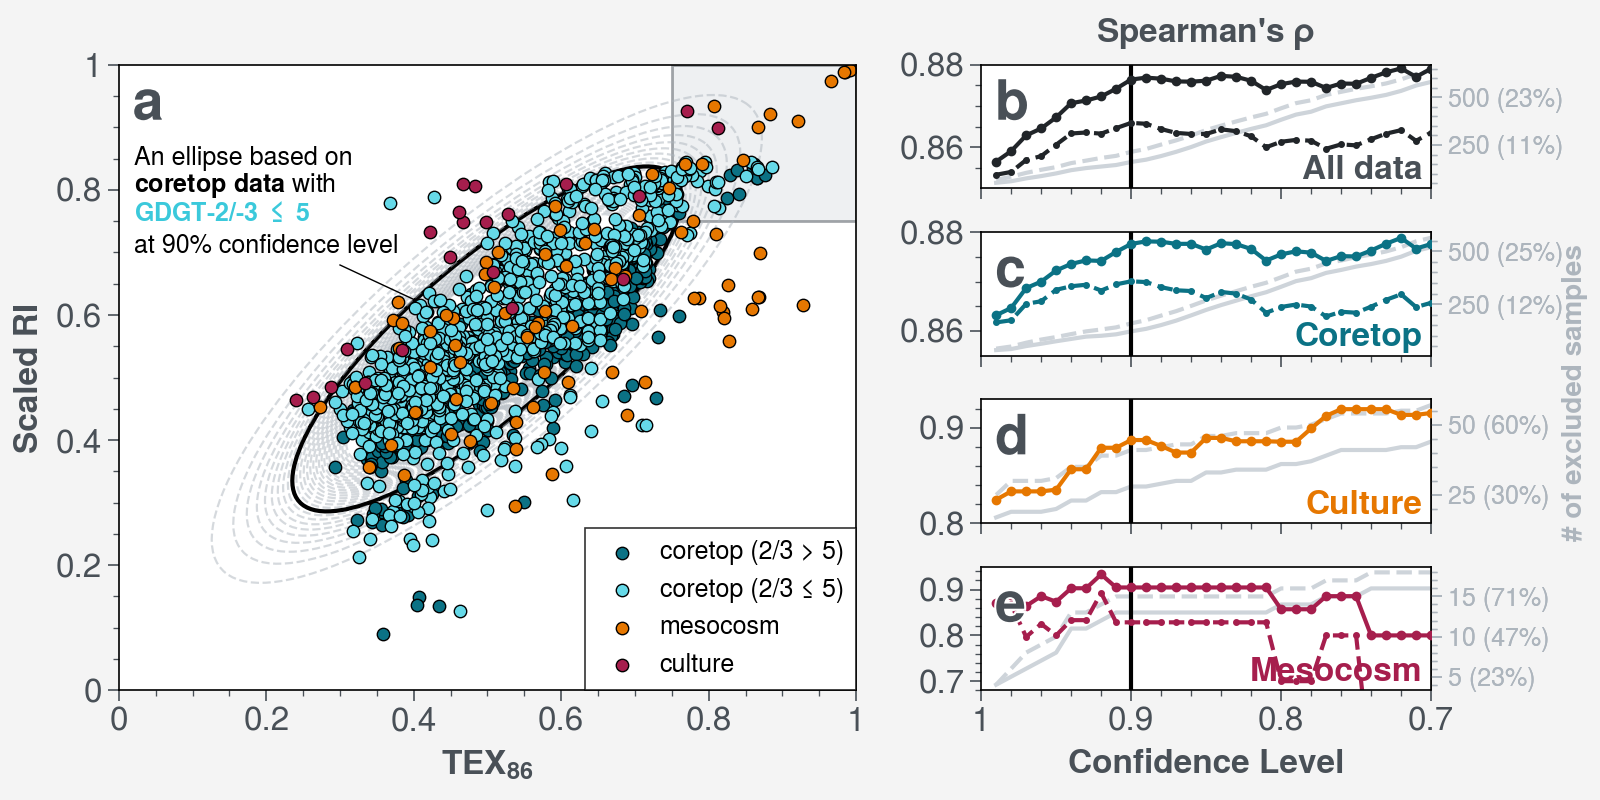

In [ ]:
array =[[1,1,1,2,2],
        [1,1,1,3,3],
        [1,1,1,4,4],
        [1,1,1,5,5]]

fig, axs = plot.subplots(array,figsize=(8,4),share=0,hspace=1.75,wspace=5)

plot_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False]
plot_data['datatype2'] = plot_data['datatype']
plot_data['datatype2'] = ['coretop_high23ratio' if (x=='coretop' and y>5) else
                          'coretop_low23ratio' if (x=='coretop' and y<=5) else
                          x for x,y in zip(plot_data['datatype'], plot_data['gdgt23ratio'])]
grouped = plot_data.groupby('datatype2')
ax = axs[0,0]
for name, group in grouped:
    plot_x = group['TEX86']
    plot_y = group['scaledRI']
    ax.scatter(plot_x, plot_y, 
                c=datatype2_color_dict.get(name,'gray'),
                s=20,
                mec='k',mew=0.5,
                label=name)

    
ax.format(xlim=(0,1), ylim=(0,1),
        xlabel=r'TEX$_{86}$',
        ylabel='Scaled RI',
)   

rect = Rectangle((0.75, 0.75), 0.25, 0.25, transform=ax.transAxes,
                 facecolor='gray3', alpha=0.5, edgecolor='gray7', linewidth=1.0, zorder=0)
ax.add_patch(rect)

text = 'An ellipse based on'
ax.text(0.02, 0.74+0.13, text, transform=ax.transAxes,
              ha='left', va='top',c='k',
              fontsize=9,)
BOLD = '\033[1m'
END = '\033[0m'
substring = "coretop"
text =  r"$\bf{coretop\ data}$ with"
ax.text(0.02, 0.7+0.13, text, transform=ax.transAxes,
              ha='left', va='top',c='k',
              fontsize=9,)

text = r'GDGT-2/-3 $\leq$ 5'
ax.text(0.02, 0.65+0.13, text, transform=ax.transAxes,
              ha='left', va='top',c='cyan4',
              fontsize=9,fontweight='bold',)

text = 'at 90% confidence level'
ax.text(0.02, 0.6+0.13, text, transform=ax.transAxes,
              ha='left', va='top',c='k',
              fontsize=9,)

ax.plot([0.3,0.4],[0.68,0.625], transform=ax.transAxes, color='k', linewidth=0.5,)
    
### Confidence level sensitivity test
confidence_levels = np.arange(0.7,0.991,0.01)
for conf_level in confidence_levels:
        conf_level = round(conf_level,2)
        detector_low23 = MahalanobisOutlierDetector(['TEX86','scaledRI'],confidence=conf_level)
        fitted_coretop_low23 = plot_data[plot_data['datatype']=='coretop'][plot_data['gdgt23ratio']<=5]
        detector_low23.fit(fitted_coretop_low23)
        detector_low23.plot_ellipse(ax, 
                                edgecolor='k' if conf_level==0.90  else 'gray5', 
                                linewidth=1.5 if conf_level==0.90 else 0.8, 
                                ls='-' if conf_level==0.90 else '--',
                                alpha=1 if conf_level==0.90 else 0.5,
                                zorder=0)

data_type_labels = {
        'all':'All data',
        'coretop':'Coretop',
        'mesocosm':'Mesocosm',
        'culture':'Culture'
}

        

grouped_stats = collect_stats_df.groupby('datatype')
grouped_stats_manual = collect_stats_df_manual.groupby('datatype')
for i, (name, group) in enumerate(grouped_stats):
        
        ax = axs[i+1]
        ax.plot(group['confidence_level'].values[::-1], group['rho'].values[::-1], 
                label=name, ls='--',m='.',s=3,
                c=datatype_color_dict.get(name,'gray9'))
        
        plot_group_manual = grouped_stats_manual.get_group(name)
        ax.plot(plot_group_manual['confidence_level'].values[::-1], plot_group_manual['rho'].values[::-1], 
                label=name, ls='-',m='.',s=5,
                c=datatype_color_dict.get(name,'gray9'))
        
        ax2 = ax.twinx()
        ax2.set_zorder(ax.get_zorder()-1)
        ax2.patch.set_visible(False)
        
        ax2.plot(group['confidence_level'].values[::-1], group['excluded_len'].values[::-1], label=name,
                c='gray4', linestyle='--')
        
        ax2.plot(plot_group_manual['confidence_level'].values[::-1], plot_group_manual['excluded_len'].values[::-1], label=name,
                c='gray4', linestyle='-')
        
        total_samples = len(plot_data) if name=='all' else len(plot_data[plot_data['datatype']==name])
        
        ax2.format(
                yticklabels=[f'{int(x)} ({int(x/total_samples*100)}%)' for (x) in ax2.get_yticks()],
                ytickcolor='gray5',
                yticklabelcolor='gray5',
        )
        
        
        text = data_type_labels.get(name,name)
        ax.text(0.98, 0.02, text, transform=ax.transAxes,
                ha='right', va='bottom',c=datatype_color_dict.get(name,'gray7'),
                fontsize=12, fontweight='bold',)
        


axs_idx = [1,2,3,4]
ylim_list = [(0.85,0.88),(0.855,0.88),(0.8,0.93),(0.68,0.95)]
for i in axs_idx:
        ax = axs[i]
        ax.format(xlim=(1,0.7), xlabel='Confidence Level',
                  ylim=ylim_list[i-1], ylabel=r'',
                  )
        
        ax.axvline(0.9, color='k', linestyle='-', linewidth=1.5, label='90% Confidence Level',zorder=0)
        
        

text = r"Spearman's $\rho$"
axs[1].text(0.5,1.1, text, transform=axs[1].transAxes,
            ha='center', va='bottom',c='gray7',
            fontsize=12, fontweight='bold',)

text = r"# of excluded samples"
axs[2].text(1.29, 0.9, text, transform=axs[2].transAxes,
            rotation=90,ha='left', va='top',c='gray5',
            fontsize=10, fontweight='bold',)

#####
h, l = axs[0].get_legend_handles_labels()
axs[0].legend(h, ['coretop (2/3 > 5)', 'coretop (2/3 ≤ 5)', 'mesocosm', 'culture'], 
              loc='lr', ncols=1, fontsize=12)

### upper right corner
axs_idx = [1,2,3]
for i in axs_idx:
        ax = axs[i]
        ax.format(xticklabels=[],
                  xlabel='')

axs.format(
    abc=True,abcstyle='a',abcloc='ul',abcsize=20,abcweight='bold',abccolor='gray7',
    grid=False, labelsize=12, fontsize=12,
    labelcolor='gray7',xtickcolor='gray7',ytickcolor='gray7',
    xticklabelcolor='gray7',yticklabelcolor='gray7',
    xlabelweight='bold', ylabelweight='bold',
)

#####
# text = r'Mahalanobis ellipse + high TEX$_{86}$-RI (use case)'
# axs[1].text(0.5, 1.15, text, transform=axs[1].transAxes,
#             ha='center', va='bottom',c='gray7',
#             fontsize=14, fontweight='bold',)

fpath = f'{local_github_path}/figures/manuscript/finalized/supplementary'
fname = f'figS3_TEXRI_mahalanobis_distance_confidence_level_sensitivity.pdf'
fig.savefig(os.path.join(fpath,fname),dpi=300)

In [ ]:
from TEXAS.data import MahalanobisOutlierDetector

# Define all feature combinations
feature_sets = {
    'TEXRI': ['TEX86', 'scaledRI'],
    'TEXfG0': ['TEX86', 'fGDGT_0'],
    'TEXfCren': ['TEX86', 'fGDGT_cren'],
    'RIfG0': ['scaledRI', 'fGDGT_0'],
    'RIpercentG0': ['scaledRI', 'ZeroOverZeroCren'],
    'RIfCren': ['scaledRI', 'fGDGT_cren'],
    'fG0Cren': ['fGDGT_0', 'fGDGT_cren'],
    'TEXRIfG0': ['TEX86', 'scaledRI', 'fGDGT_0'],
    'TEXRIpercentG0': ['TEX86', 'scaledRI', 'ZeroOverZeroCren'],
    'TEXRIfG0Cren': ['TEX86', 'scaledRI', 'fGDGT_0', 'fGDGT_cren'],
    'allGDGTs': ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']
}

# Fit and apply all screening methods
fitted_detectors = {}
confidence_level = 0.9

for name, features in feature_sets.items():
    detector = MahalanobisOutlierDetector(features, confidence=confidence_level)
    
    # Fit on coretop data
    detector.fit(combined_df_raw[combined_df_raw['lowAbundanceFlag']==False][
        (combined_df_raw['datatype'] == 'coretop')])

    
    print(f"{name}_mahalDist_low23ratio_thr: {detector.threshold:.4f}")
    
    # Apply to entire dataset
    combined_df_raw[f'{name}_mahalDist'] = detector.transform(combined_df_raw)
    combined_df_raw[f'{name}_mahalDist_outliers'] = detector.detect_outliers(combined_df_raw)
    combined_df_raw[f'{name}_mahalDist_outliers_manual'] = detector.detect_outliers_manual(combined_df_raw)
    
    fitted_detectors[name] = detector
    

    PhanTEX_df[f'{name}_mahalDist'] = detector.transform(PhanTEX_df)
    PhanTEX_df[f'{name}_mahalDist_outliers'] = detector.detect_outliers(PhanTEX_df)
    PhanTEX_df[f'{name}_mahalDist_outliers_manual'] = detector.detect_outliers_manual(PhanTEX_df)

TEXRI_mahalDist_low23ratio_thr: 2.1460
TEXfG0_mahalDist_low23ratio_thr: 2.1460
TEXfCren_mahalDist_low23ratio_thr: 2.1460
RIfG0_mahalDist_low23ratio_thr: 2.1460
RIpercentG0_mahalDist_low23ratio_thr: 2.1460
RIfCren_mahalDist_low23ratio_thr: 2.1460
fG0Cren_mahalDist_low23ratio_thr: 2.1460
TEXRIfG0_mahalDist_low23ratio_thr: 2.5003
TEXRIpercentG0_mahalDist_low23ratio_thr: 2.5003
TEXRIfG0Cren_mahalDist_low23ratio_thr: 2.7892
allGDGTs_mahalDist_low23ratio_thr: 3.2626


In [ ]:
from TEXAS.data import MahalanobisOutlierDetector

# Define all feature combinations
feature_sets = {
    'TEXRI': ['TEX86', 'scaledRI'],
    'TEXfG0': ['TEX86', 'fGDGT_0'],
    'TEXfCren': ['TEX86', 'fGDGT_cren'],
    'RIfG0': ['scaledRI', 'fGDGT_0'],
    'RIpercentG0': ['scaledRI', 'ZeroOverZeroCren'],
    'RIfCren': ['scaledRI', 'fGDGT_cren'],
    'fG0Cren': ['fGDGT_0', 'fGDGT_cren'],
    'TEXRIfG0': ['TEX86', 'scaledRI', 'fGDGT_0'],
    'TEXRIpercentG0': ['TEX86', 'scaledRI', 'ZeroOverZeroCren'],
    'TEXRIfG0Cren': ['TEX86', 'scaledRI', 'fGDGT_0', 'fGDGT_cren'],
    'allGDGTs': ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']
}

# Fit and apply all screening methods
fitted_detectors = {}
confidence_level = 0.9

for name, features in feature_sets.items():
    detector = MahalanobisOutlierDetector(features, confidence=confidence_level)
    
    # Fit on coretop data
    detector.fit(combined_df_raw[combined_df_raw['lowAbundanceFlag']==False][
        (combined_df_raw['datatype'] == 'coretop') & (combined_df_raw['gdgt23ratio'] <= 5)])

    
    print(f"{name}_mahalDist_low23ratio_thr: {detector.threshold:.4f}")
    
    # Apply to entire dataset
    combined_df_raw[f'{name}_mahalDist_low23ratio'] = detector.transform(combined_df_raw)
    combined_df_raw[f'{name}_mahalDist_low23ratio_outliers'] = detector.detect_outliers(combined_df_raw)
    combined_df_raw[f'{name}_mahalDist_low23ratio_outliers_manual'] = detector.detect_outliers_manual(combined_df_raw)
    
    fitted_detectors[name] = detector
    

    PhanTEX_df[f'{name}_mahalDist_low23ratio'] = detector.transform(PhanTEX_df)
    PhanTEX_df[f'{name}_mahalDist_low23ratio_outliers'] = detector.detect_outliers(PhanTEX_df)
    PhanTEX_df[f'{name}_mahalDist_low23ratio_outliers_manual'] = detector.detect_outliers_manual(PhanTEX_df)

TEXRI_mahalDist_low23ratio_thr: 2.1460
TEXfG0_mahalDist_low23ratio_thr: 2.1460
TEXfCren_mahalDist_low23ratio_thr: 2.1460
RIfG0_mahalDist_low23ratio_thr: 2.1460
RIpercentG0_mahalDist_low23ratio_thr: 2.1460
RIfCren_mahalDist_low23ratio_thr: 2.1460
fG0Cren_mahalDist_low23ratio_thr: 2.1460
TEXRIfG0_mahalDist_low23ratio_thr: 2.5003
TEXRIpercentG0_mahalDist_low23ratio_thr: 2.5003
TEXRIfG0Cren_mahalDist_low23ratio_thr: 2.7892
allGDGTs_mahalDist_low23ratio_thr: 3.2626


### 3.3.4 Comparison between deltaRI and Mahalanobis ellipse

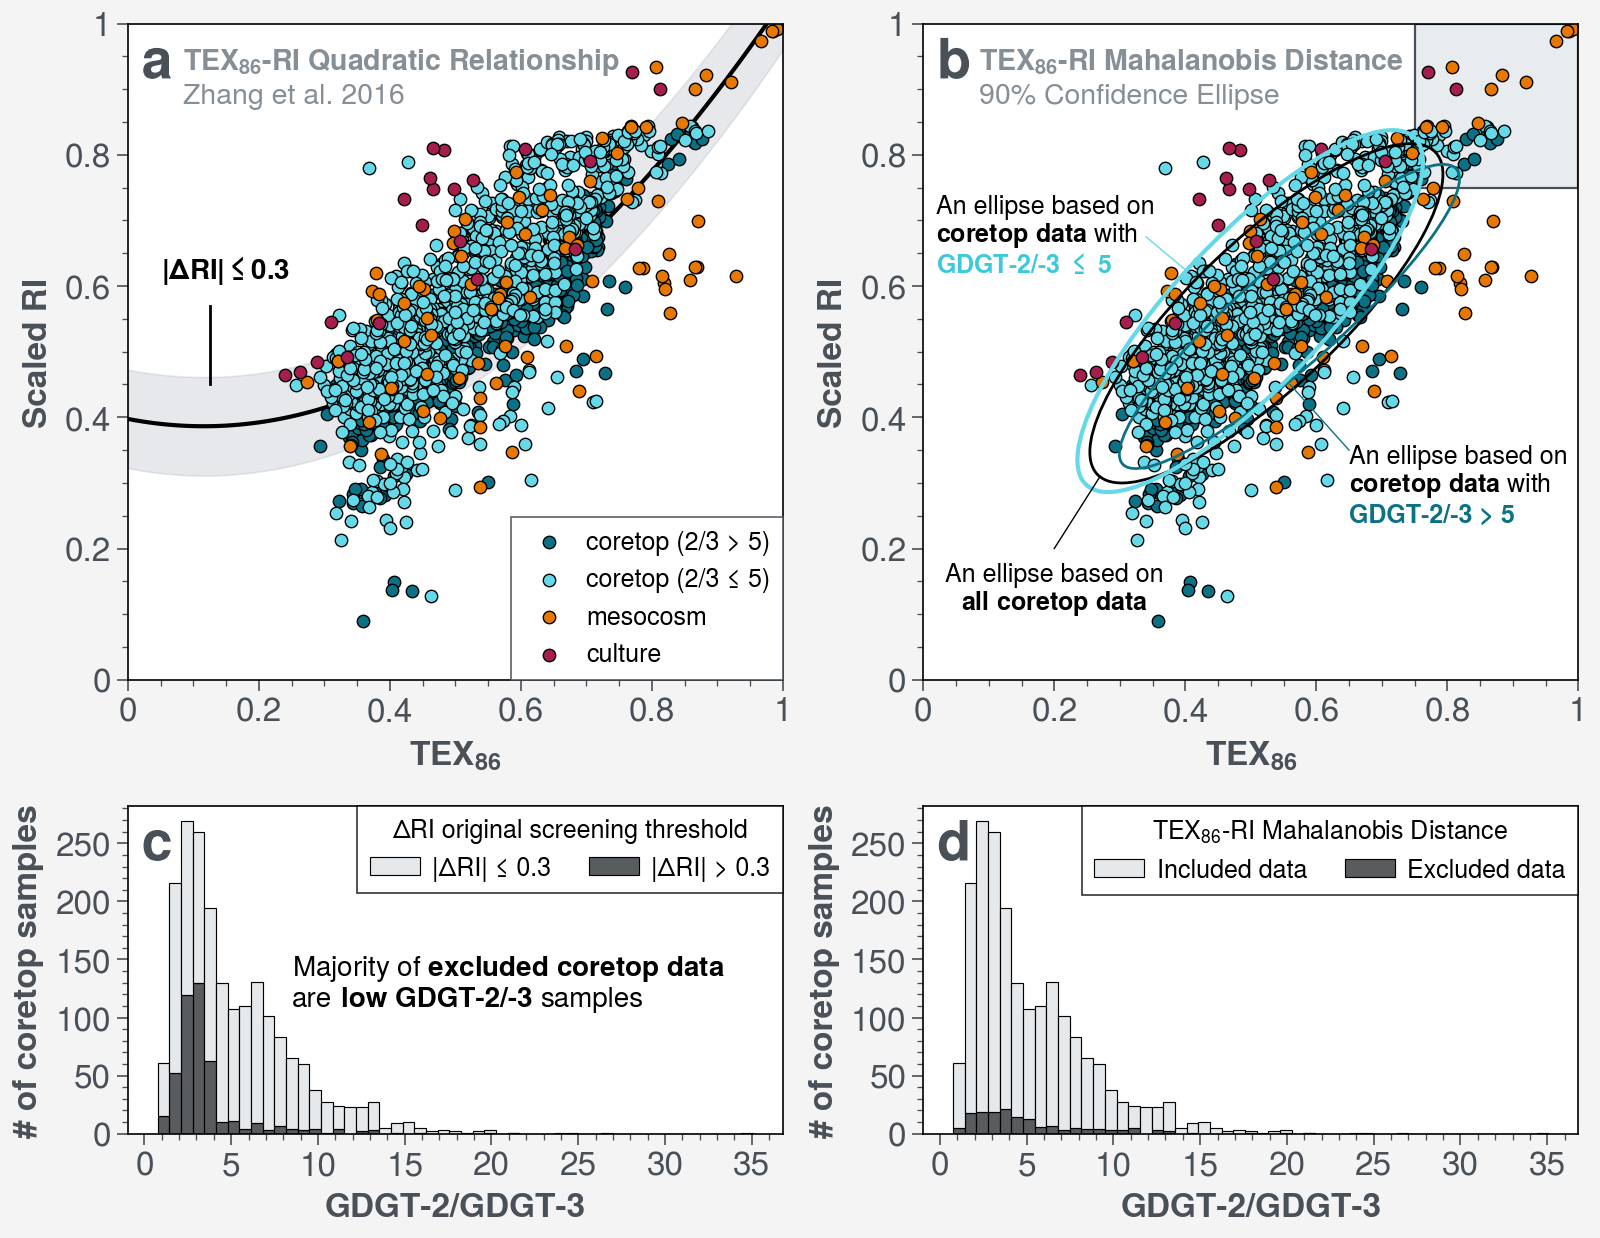

In [ ]:
fig, axs = plot.subplots(ncols=2,nrows=2, width=8, hratios=[1,0.5],share=0)

plot_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False]
plot_data['datatype2'] = plot_data['datatype']
plot_data['datatype2'] = ['coretop_high23ratio' if (x=='coretop' and y>5) else
                          'coretop_low23ratio' if (x=='coretop' and y<=5) else
                          x for x,y in zip(plot_data['datatype'], plot_data['gdgt23ratio'])]
grouped = plot_data.groupby('datatype2')
for name, group in grouped:

    plot_x = group['TEX86']
    plot_y = group['scaledRI']
    axs[0,:].scatter(plot_x, plot_y, 
                    c=datatype2_color_dict.get(name,'gray'),
                    s=20,
                    mec='k',mew=0.5,
                    label=name)


ax = axs[0,0]
### Zhang16 TEX-RI curve
tex_range = np.arange(0,1.01,0.01)
ri_zhang16 = -0.77*tex_range + 3.32*(tex_range**2) + 1.59
ax.plot(tex_range, ri_zhang16/4, color='k', label='Zhang et al. (2016)', zorder=0)
ri_zhang16_upper = ri_zhang16 + 0.3
ri_zhang16_lower = ri_zhang16 - 0.3
ax.fill_between(tex_range, ri_zhang16_lower/4, ri_zhang16_upper/4, color='gray5', alpha=0.3, label='±0.3 RI', zorder=0)

text = r'TEX$_{86}$-RI Quadratic Relationship'
ax.text(0.085, 0.965, text, transform=ax.transAxes,
              ha='left', va='top',c='gray6',
              fontsize=10.25, fontweight='bold',)
text = 'Zhang et al. 2016'
ax.text(0.085, 0.91, text, transform=ax.transAxes,
              ha='left', va='top',c='gray6',
              fontsize=10.25,)

text = r'|$\Delta$RI|$\leq$0.3'
ax.text(0.05, 0.65, text, transform=ax.transAxes,
              ha='left', va='top',c='k',
              fontsize=10, fontweight='bold',)
ax.plot([0.125,0.125],[0.57,0.45], transform=ax.transAxes, color='k', linewidth=1,)

##################################################
ax = axs[0,1]

fitted_coretop_all = plot_data[plot_data['datatype']=='coretop']
detector = MahalanobisOutlierDetector(['TEX86','scaledRI'],confidence=0.9)
detector.fit(fitted_coretop_all)
detector.plot_ellipse(ax, edgecolor='k', linewidth=1, label='90% Confidence Ellipse',ls='-',alpha=1)

fitted_coretop_high23 = plot_data[plot_data['datatype']=='coretop'][plot_data['gdgt23ratio']>5]
detector_high23 = MahalanobisOutlierDetector(['TEX86','scaledRI'],confidence=0.9)
detector_high23.fit(fitted_coretop_high23)
detector_high23.plot_ellipse(ax, edgecolor='cyan9', linewidth=1, label='90% Confidence Ellipse',ls='-',alpha=1)

fitted_coretop_low23 = plot_data[plot_data['datatype']=='coretop'][plot_data['gdgt23ratio']<=5]
detector_low23 = MahalanobisOutlierDetector(['TEX86','scaledRI'],confidence=0.9)
detector_low23.fit(fitted_coretop_low23)
detector_low23.plot_ellipse(ax, edgecolor='cyan3', linewidth=1.5, label='90% Confidence Ellipse',ls='-',alpha=1)

rect = Rectangle((0.75,0.75),0.25,0.25, transform=ax.transAxes,
                 facecolor='gray2', edgecolor='gray7', linewidth=0.8, zorder=0)
ax.add_artist(rect)


######

text = r'TEX$_{86}$-RI Mahalanobis Distance'
ax.text(0.085, 0.965, text, transform=ax.transAxes,
              ha='left', va='top',c='gray6',
              fontsize=10.25, fontweight='bold',)
text = r'90% Confidence Ellipse'
ax.text(0.085, 0.91, text, transform=ax.transAxes,
              ha='left', va='top',c='gray6',
              fontsize=10.25,)

############################
text = 'An ellipse based on'
ax.text(0.02, 0.74, text, transform=ax.transAxes,
              ha='left', va='top',c='k',
              fontsize=9,)
BOLD = '\033[1m'
END = '\033[0m'
substring = "coretop"
text =  r"$\bf{coretop\ data}$ with"
ax.text(0.02, 0.7, text, transform=ax.transAxes,
              ha='left', va='top',c='k',
              fontsize=9,)

text = r'GDGT-2/-3 $\leq$ 5'
ax.text(0.02, 0.65, text, transform=ax.transAxes,
              ha='left', va='top',c='cyan4',
              fontsize=9,fontweight='bold',)

ax.plot([0.34,0.4],[0.675,0.625], transform=ax.transAxes, color='cyan3', linewidth=0.5,)

############################
text = 'An ellipse based on'
ax.text(0.2, 0.18, text, transform=ax.transAxes,
              ha='center', va='top',c='k',
              fontsize=9,)
BOLD = '\033[1m'
END = '\033[0m'
substring = "coretop"
text =  r"$\bf{all\ coretop\ data}$"
ax.text(0.2, 0.14, text, transform=ax.transAxes,
              ha='center', va='top',c='k',
              fontsize=9,)

ax.plot([0.2,0.27],[0.2,0.31], transform=ax.transAxes, color='k', linewidth=0.5,)

############################
text = 'An ellipse based on'
ax.text(0.65, 0.36, text, transform=ax.transAxes,
              ha='left', va='top',c='k',
              fontsize=9,)
BOLD = '\033[1m'
END = '\033[0m'
substring = "coretop"
text =  r"$\bf{coretop\ data}$ with"
ax.text(0.65, 0.32, text, transform=ax.transAxes,
              ha='left', va='top',c='k',
              fontsize=9,)

text = 'GDGT-2/-3 > 5'
ax.text(0.65, 0.27, text, transform=ax.transAxes,
              ha='left', va='top',c='cyan9',
              fontsize=9,fontweight='bold',)

ax.plot([0.56,0.65],[0.45,0.35], transform=ax.transAxes, color='cyan9', linewidth=0.5,)

## plot stacked histrograms
ax = axs[1,0]
plot_coretop = plot_data[plot_data['datatype']=='coretop']
plot_coretop["bin_absDeltaRI"] = pd.cut(abs(plot_coretop['deltaRI']), bins=[0,0.3,2])
m = sns.histplot(ax=ax,data=plot_coretop,
             x='gdgt23ratio', 
             hue='bin_absDeltaRI',
             palette={pd.Interval(0,0.3):'gray3', pd.Interval(0.3,2):'gray9'},
             multiple='stack',
             legend=False)
h, l = m.get_legend_handles_labels()
ax.legend(h[::-1], ['|ΔRI| ≤ 0.3','|ΔRI| > 0.3'], title='ΔRI original screening threshold')

text = r'Majority of $\bf{excluded\ coretop\ data}$'
ax.text(0.25, 0.55, text, transform=ax.transAxes,
        ha='left', va='top',c='k',
        fontsize=10,)

text = r'are'
ax.text(0.25, 0.45, text, transform=ax.transAxes,
        ha='left', va='top',c='k',
        fontsize=10 )
text = r'low GDGT-2/-3'
ax.text(0.325, 0.45, text, transform=ax.transAxes,
        ha='left', va='top',c='k',
        fontsize=10, fontweight='bold',)
text = 'samples'
ax.text(0.63, 0.45, text, transform=ax.transAxes,
        ha='left', va='top',c='k',
        fontsize=10, )

## plot stacked histrograms for mahalanobis distance
ax = axs[1,1]
plot_coretop['TEXRI_mahal_outliers'] = detector_low23.detect_outliers(plot_coretop)
m = sns.histplot(ax=ax,data=plot_coretop,
             x='gdgt23ratio', 
             hue='TEXRI_mahal_outliers',
             palette={False:'gray3', True:'gray9'},
             multiple='stack',
                legend=False)

h, l = m.get_legend_handles_labels()
ax.legend(h[::-1], ['Included data','Excluded data'], title=r'$TEX_{86}$-RI Mahalanobis Distance')

##################################################

axs[0,:].format(
    xlim=(0,1), ylim=(0,1),
    xlabel=r'TEX$_{86}$',
    ylabel='Scaled RI',
)
axs[1,:].format(
    xlabel='GDGT-2/GDGT-3',
    ylabel='# of coretop samples'
)
axs.format(
    abc=True,abcstyle='a',abcloc='ul',abcsize=20,abcweight='bold',abccolor='gray7',
    grid=False, labelsize=12, fontsize=12,
    labelcolor='gray7',xtickcolor='gray7',ytickcolor='gray7',
    xticklabelcolor='gray7',yticklabelcolor='gray7',
    xlabelweight='bold', ylabelweight='bold',
)

h, l = axs[0,0].get_legend_handles_labels()
axs[0,0].legend(h[1:5],
                ['coretop (2/3 > 5)',
                 'coretop (2/3 ≤ 5)',
                 'mesocosm',
                 'culture'],
                loc='lr', fontsize=8, framealpha=0.9, edgecolor='gray7', ncols=1)

fpath = fr'{local_github_path}/figures/manuscript/finalized/main-text'
fname = f'fig5_TEXRI_mahalanobis_distance_gdgt23ratio.pdf'
fig.savefig(os.path.join(fpath,fname),dpi=300)

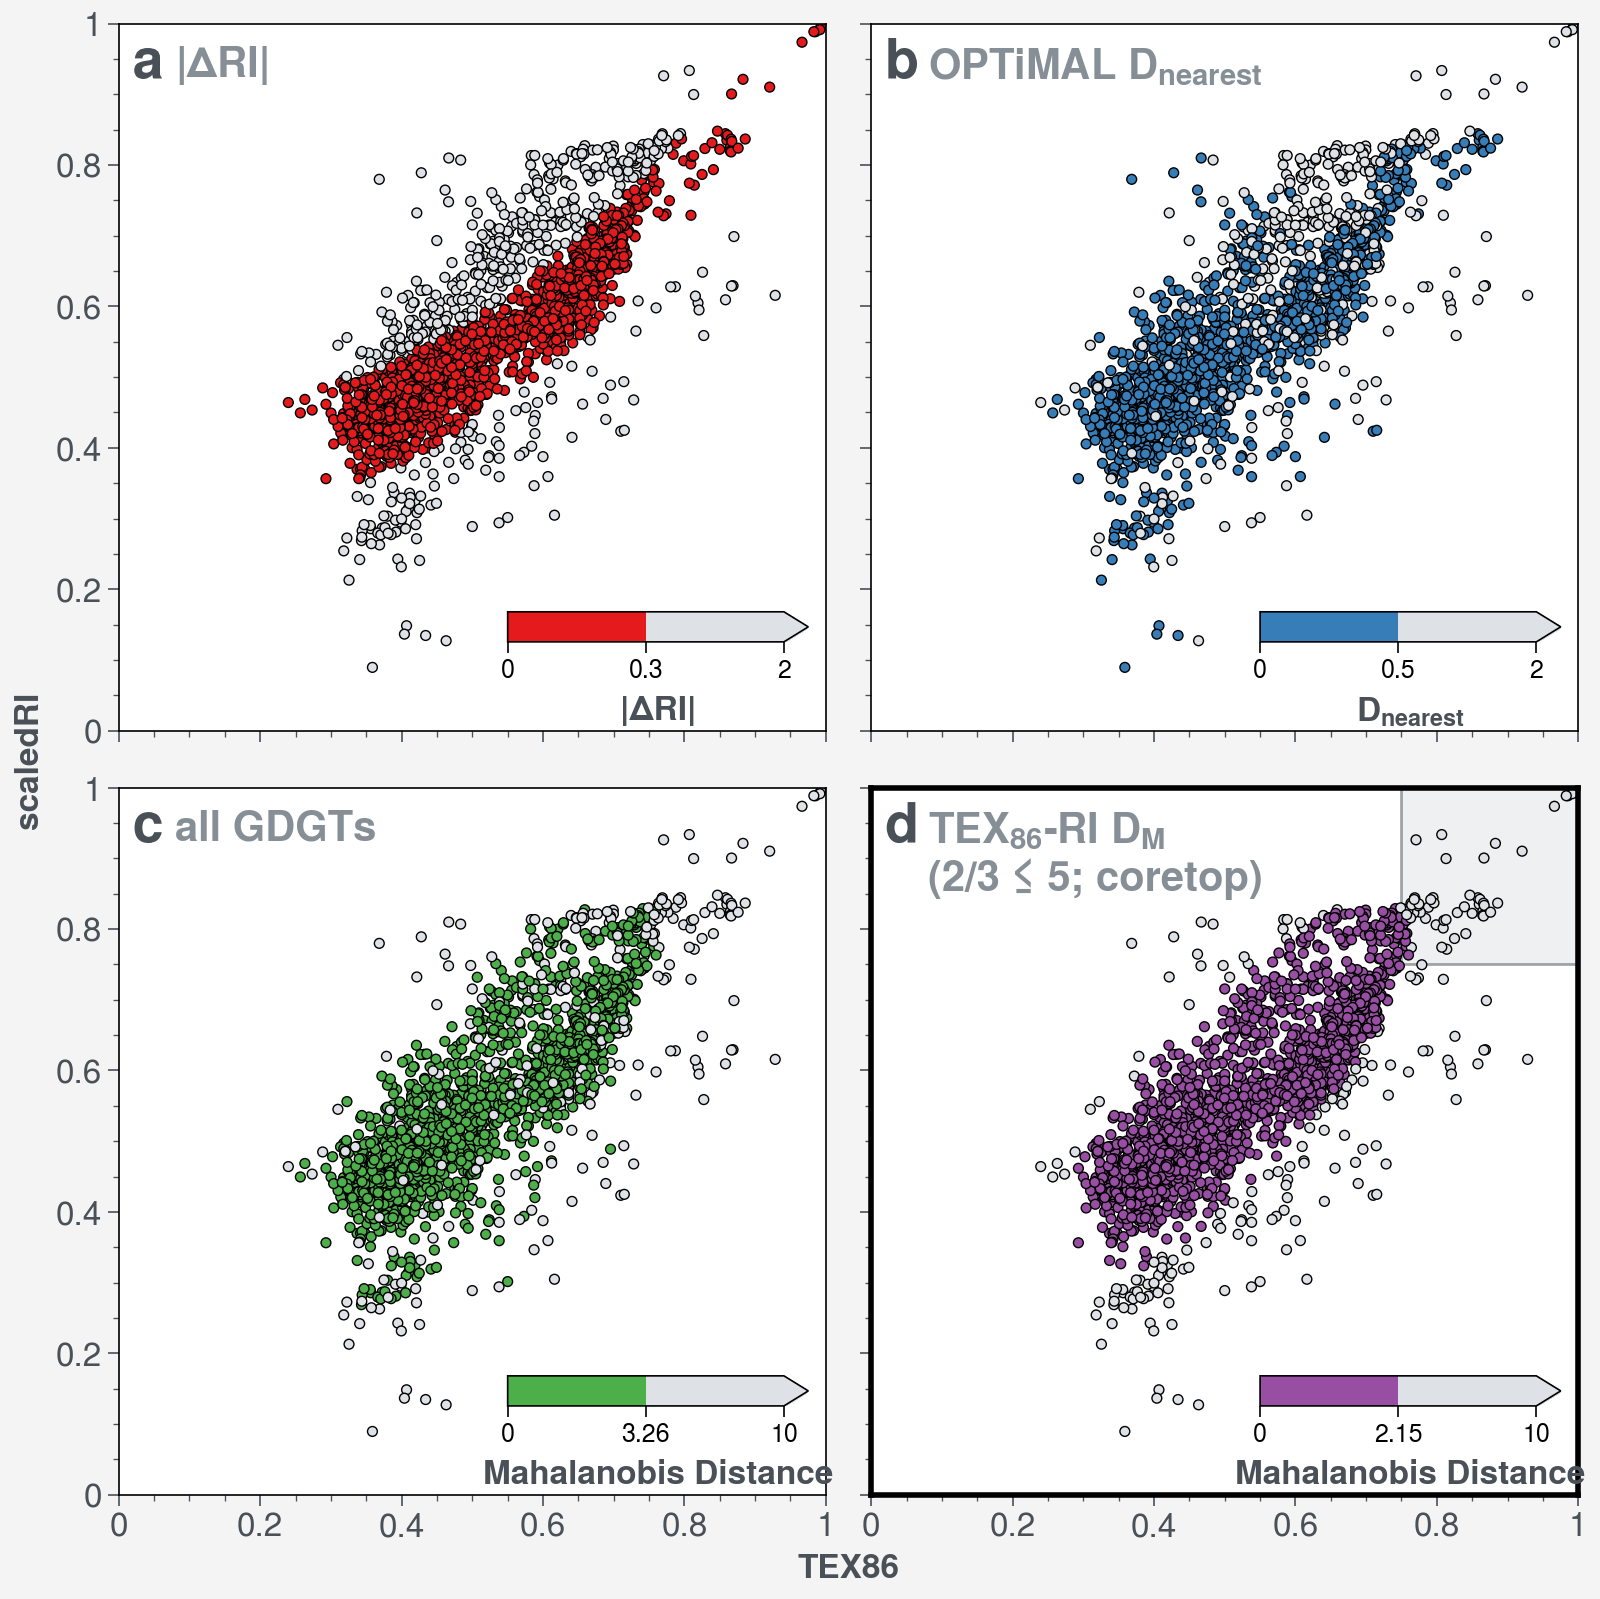

In [ ]:
fig, axs = plot.subplots(ncols=2,nrows=2, width=8)

plot_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False]


color_params = ['abs_deltaRI','OPTiMAL_Dnearest','allGDGTs_mahalDist', 'TEXRI_mahalDist_low23ratio',]
labels=['|ΔRI|',r'OPTiMAL D$_{nearest}$','all GDGTs',r'TEX$_{86}$-RI D$_{M}$'+f'\n(2/3 ≤ 5; coretop)']
cbar_labels=['|ΔRI|','D$_{nearest}$','Mahalanobis Distance','Mahalanobis Distance']
tab10_colors = plot.get_colors('Set1')
color_levels = [
    [0,0.3,2],
    [0,0.5,2],
    [0,3.2626,10],
    [0,2.1460,10]
]

for i, c_param in enumerate(color_params):
    ax = axs[i]
    
    plot_x = plot_data['TEX86']
    plot_y = plot_data['scaledRI']
    plot_c = plot_data[c_param]
    m = ax.scatter(plot_x, plot_y,
               c=plot_c,
               cmap=[tab10_colors[i],'gray3','gray3'],
               levels=color_levels[i],
               extend='max',
               m='.',mec='k', mew=0.5,
               s=50,
               label=labels[i])
    
    ax.colorbar(m, label=cbar_labels[i],
                loc='lr',shrink=12,
                labelsize=12, labelweight='bold',
                labelcolor='gray7',
                frame=False)
    
    text = labels[i]
    ax.text(0.08, 0.97, text, transform=ax.transAxes,
              ha='left', va='top',c='gray6',
              fontsize=15, fontweight='bold',)
    

ax=axs[-1]
    


ax.spines[:].set_linewidth(2.0)

axs.format(
    abc=True,abcstyle='a',abcloc='ul',abcsize=20,abcweight='bold',abccolor='gray7',
    grid=False, labelsize=12, fontsize=12,
    labelcolor='gray7',xtickcolor='gray7',ytickcolor='gray7',
    xticklabelcolor='gray7',yticklabelcolor='gray7',
    xlabelweight='bold', ylabelweight='bold',
    xlim=(0,1), ylim=(0,1),
)

rect = Rectangle((0.75, 0.75), 0.25, 0.25, transform=ax.transAxes,
                 facecolor='gray3', alpha=0.5, edgecolor='gray7', linewidth=1.0, zorder=0)
ax.add_patch(rect)

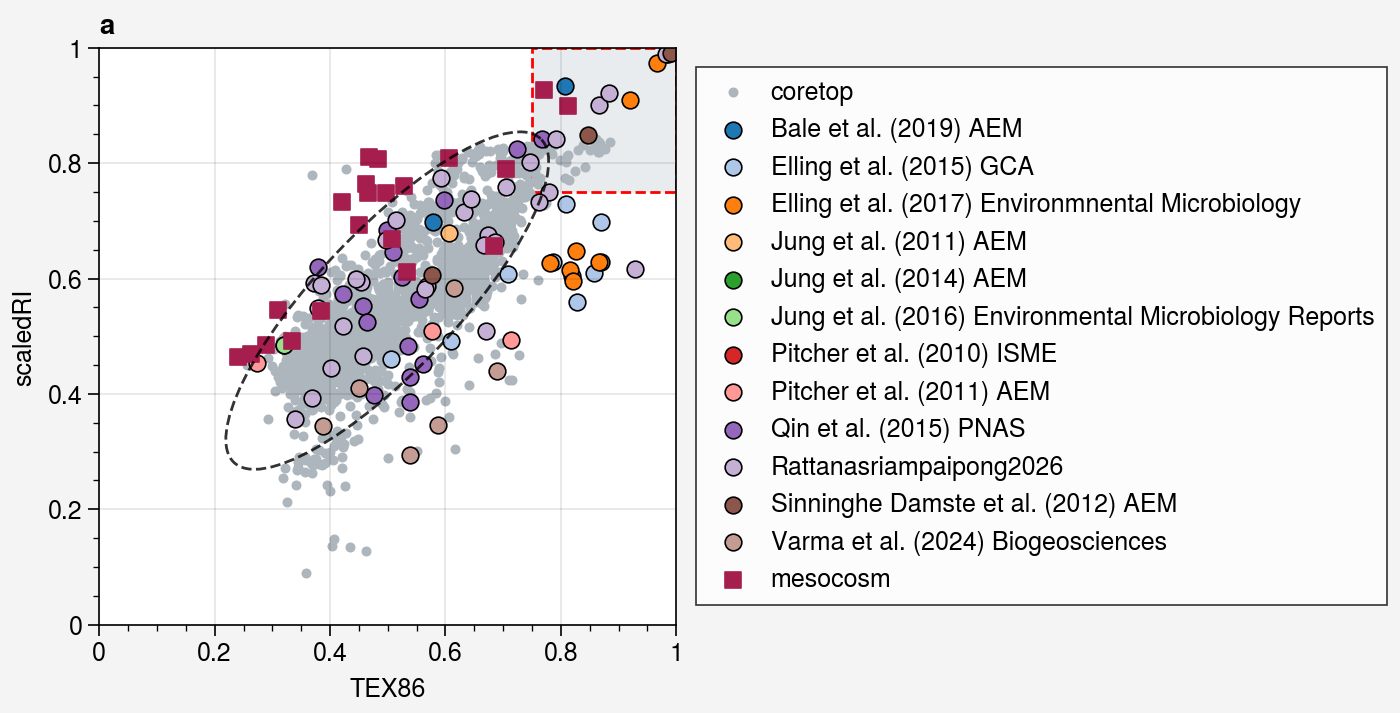

In [ ]:
fig, axs = plot.subplots(width=7)

plot_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False]#[combined_df_raw['TEXRI_mahalDist_low23ratio_outliers_manual']==False]
plot_data = plot_data

ax = axs[0]
grouped = plot_data.groupby('datatype')
for name, group in grouped:
    
    
    if name=='culture':
        grouped2 = group.groupby('reference_name')
        for name2, group2 in grouped2:
            plot_x = group2['TEX86']
            plot_y = group2['scaledRI']
            ax.scatter(plot_x, plot_y, label=name2, m='o',
                       mec='k', cycle='tab20')
            
     
    elif name=='coretop':
        plot_x = group['TEX86']
        plot_y = group['scaledRI']
        ax.scatter(plot_x, plot_y, label=name, m='.', 
                   c='gray5')
    else:
        plot_x = group['TEX86']
        plot_y = group['scaledRI']
        ax.scatter(plot_x, plot_y, label=name, m='s', 
                   c=datatype_color_dict.get(name,'gray'))
        

h, l = ax.get_legend_handles_labels()
ax.legend(h, l, loc='r', ncols=1, fontsize=8)

### draw ellipse of Mahalanobis boundary
detect_features = ['TEX86', 'scaledRI']
detector = MahalanobisOutlierDetector(detect_features, confidence=0.925)
low23_coretop = combined_df_raw[((combined_df_raw['datatype']=='coretop') 
                                & (combined_df_raw['lowAbundanceFlag']==False)
                                & (combined_df_raw['gdgt23ratio']<=5))]
detector.fit(low23_coretop)
detector.plot_ellipse(ax, facecolor='none', edgecolor='k', ls="--", linewidth=1, label='90% confidence')

from matplotlib.patches import Rectangle
rect = Rectangle((0.75,0.75), 0.25,0.25, linewidth=1, edgecolor='r', 
                 facecolor='gray2', ls='--', 
                 label='Low GDGT-2&3 abundance',
                 zorder=0)
ax.add_artist(rect)
ax.format(
    xlim=(0,1),
    ylim=(0,1),
)

In [ ]:
fpath = f'{local_onedrive_path}/Postdoc/Project/TEXAS/datasets/published_data'
fname = 'compilation_published_cren_brGDGTs_concentrations.xlsx'

DeJonge24_df = pd.read_excel(os.path.join(fpath,fname),sheet_name='DeJonge2024_brGDGTs_interlab')
DeJonge24_df['BIT'] = DeJonge24_df['BIT'].replace({'n.d.':np.nan}).astype(float)
DeJonge24_df = DeJonge24_df.dropna(how='any',subset=['BIT']).sort_values('BIT').reset_index(drop=True)
DeJonge24_df['Cren_microgram_per_gram'] = DeJonge24_df['Crenarchaeol conc (ng*g soil-1 or ng*extract-1)']/1000
DeJonge24_df['brGDGTs_microgram_per_gram'] = DeJonge24_df['ΣbrGDGT concentration (ng*g soil-1 or ng*extract-1)']/1000
display(DeJonge24_df)

Weijers06_df = pd.read_excel(os.path.join(fpath,fname),sheet_name='Weijers06_table2').sort_values('BIT index').reset_index(drop=True)
Weijers06_df = Weijers06_df.rename(columns={'BIT index':'BIT'})
Weijers06_df['Cren_microgram_per_gram'] = Weijers06_df['cren (ng/g dry weight soil)']/1000
Weijers06_df['brGDGTs_microgram_per_gram'] = Weijers06_df['sum(brGDGTs) (ng/g dry weight soil)']/1000
display(Weijers06_df)



,Lab number,Sample,crenarchaeol,IIIa,IIIa',IIIb,IIIb',IIIc,IIIc',IIa,...,ΣbrGDGT concentration (ng*g soil-1 or ng*extract-1),MBT'5ME,MBT',IR,CBT',#ringstetra,BIT,sum(brGDGTs)/cren,Cren_microgram_per_gram,brGDGTs_microgram_per_gram
0,15,D,11776.00,1643.00,1410.00,0.00,0.00,0.00,0.00,7169.00,...,56.70,0.93,0.82,0.65,-0.67,0.26,0.91,13.50,0.00,0.06
1,45,D,97134.00,7006.00,10581.00,0.00,0.00,0.00,0.00,52243.00,...,95.80,0.96,0.83,0.76,-0.63,0.27,0.93,18.42,0.01,0.10
2,20,D,58339.40,14328.30,21218.20,NaN,NaN,NaN,NaN,35357.40,...,170.20,0.94,0.80,0.76,-0.53,0.30,0.94,20.76,0.01,0.17
3,15,B,10399.00,11244.00,48423.00,0.00,6004.00,0.00,0.00,17851.00,...,81.90,0.58,0.23,0.79,0.33,0.36,0.94,20.48,0.00,0.08
4,30,D,1612085.00,190279.00,406056.00,0.00,15365.00,0.00,0.00,1255946.00,...,24.50,0.94,0.78,0.77,-0.48,0.30,0.94,20.42,0.00,0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,42,G,12368.11,496655.14,35811.81,5285.68,2717.82,4600.12,1611.50,2285953.10,...,700703.00,0.51,0.49,0.09,-1.05,0.26,1.00,519.12,1.35,700.70
180,39,B,52067.90,1004715.30,4101069.30,66713.50,448112.20,54165.70,0.00,1695170.00,...,144.30,0.61,0.24,0.80,0.34,0.37,1.00,42.44,0.00,0.14
181,30,F,6525.00,38424052.00,2053884.00,51632.00,12367.00,604.00,0.00,28628107.00,...,912.20,0.14,0.14,0.05,-1.31,0.07,1.00,9122.00,0.00,0.91
182,3,F,192065.69,118663057.70,4433749.86,0.00,0.00,0.00,0.00,88331970.32,...,100427.50,0.13,0.13,0.04,-1.46,0.05,1.00,1282.60,0.08,100.43


,Sample,Depth (cm),top_depth,I,II,III,IV,VI,VI′,VII,VIII,IX,cren (ng/g dry weight soil),sum(brGDGTs) (ng/g dry weight soil),BIT,sum(brGDGTs)/cren,datatype,Cren_microgram_per_gram,brGDGTs_microgram_per_gram
0,Nigeria-19,0–25,0,2.40,0.60,1.00,0.90,19.00,4.80,0.50,4.50,12.00,19.00,17.00,0.52,0.89,Forest,0.02,0.02
1,Sweden-4,0–15,0,12.00,1.00,1.20,0.90,9.50,0.90,3.30,5.80,2.50,9.50,11.60,0.55,1.22,Grassland,0.01,0.01
2,Alaska-17,0–20,0,22.00,9.10,7.00,2.70,34.00,1.10,17.00,33.00,15.00,34.00,65.00,0.66,1.91,Alluvial-Coastal-Delta,0.03,0.07
3,Canada-17,0–15,0,10.00,3.10,3.90,2.70,25.00,2.90,19.00,35.00,13.00,25.00,67.00,0.73,2.68,Cropland,0.03,0.07
4,Gabon-6,0–5,0,2.20,1.70,2.30,2.00,26.00,1.50,0.50,6.40,51.00,26.00,57.90,0.74,2.23,Grassland,0.03,0.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,Zaire-2,0–8,0,1.70,0.60,0.60,0.40,1.10,0.10,0.00,2.70,113.00,1.10,115.70,0.99,105.18,Cropland,0.00,0.12
21,Ireland-9,0–7,0,99.00,10.00,15.00,13.00,7.00,0.00,102.00,971.00,1389.00,7.00,2462.00,1.00,351.71,Grassland,0.01,2.46
22,Nigeria-15,0–12,0,4.10,1.90,2.20,2.40,0.40,0.00,0.00,1.90,92.00,0.40,93.90,1.00,234.75,Alluvial-Coastal-Delta,0.00,0.09
23,Gabon-5,0–20,0,2.50,0.40,0.30,0.20,0.10,0.00,0.00,0.70,25.00,0.10,25.70,1.00,257.00,Grassland,0.00,0.03


In [ ]:
fpath = f'{local_onedrive_path}/Postdoc/Project/TEXAS/datasets/published_data'
fname = 'Zell2014_Amazon_general_prop.tab'
Zell14_df = pd.read_csv(os.path.join(fpath,fname),sep='\t',skiprows=79)
Zell14_df['datatype'] = ['SPM' if 'WS' in str(row) else \
                         'Coretop' if 'BC' in str(row) else \
                             'Amazon River' for row in Zell14_df['Event']]
Zell14_df.head()

,Event,Sample label,Latitude,Longitude,Elevation [m],Depth water [m],Depth sed [m],"brGDGT Ia [µg/g] (core lipid (CL), per organic ...)","brGDGT Ib [µg/g] (core lipid (CL), per organic ...)","brGDGT Ic [µg/g] (core lipid (CL), per organic ...)",...,"iso GDGT-3 [µg/g] (core lipid (CL), per organic ...)","Cren [µg/g] (core lipid (CL), per organic ...)","Cren iso [µg/g] (core lipid (CL), per organic ...)","iso GDGT-0 [µg/g] (intact polar lipid (IPL), per...)","iso GDGT-1 [µg/g] (intact polar lipid (IPL), per...)","iso GDGT-2 [µg/g] (intact polar lipid (IPL), per...)","iso GDGT-3 [µg/g] (intact polar lipid (IPL), per...)","Cren [µg/g] (intact polar lipid (IPL), per...)","Cren iso [µg/g] (intact polar lipid (IPL), per...)",datatype
0,Amazom_CBM5,CBM5,1.97,-55.47,NaN,0.00,NaN,78.40,4.50,1.60,...,1.40,12.60,0.30,19.30,2.20,2.00,2.50,6.80,NaN,Amazon River
1,Amazom_CBM6,CBM6,1.95,-55.49,NaN,0.00,NaN,22.10,2.20,0.80,...,4.10,38.70,1.20,5.00,0.90,1.70,2.70,4.70,NaN,Amazon River
2,Amazom_CBM7,CBM7,1.95,-55.50,NaN,0.00,NaN,82.00,5.30,1.90,...,5.10,62.40,1.20,14.30,2.90,4.10,5.80,14.80,1.70,Amazon River
3,Amazom_CBM8,CBM8,1.91,-55.55,NaN,0.00,NaN,49.60,5.10,1.70,...,2.90,28.60,0.80,8.10,1.40,2.00,2.80,6.70,1.10,Amazon River
4,AMAZA_26,AMAZA 26,-2.41,-54.25,NaN,NaN,0.00,122.50,13.30,4.00,...,2.90,13.00,0.50,28.10,2.70,2.10,2.30,2.70,0.40,Amazon River


In [ ]:

CL_cren_columns_idx = Zell14_df.columns[((Zell14_df.columns.str.contains('core lipid'))
                                   &(Zell14_df.columns.str.contains('Cren'))
                                   &~(Zell14_df.columns.str.contains('Cren iso')))]

CL_brGDGT_columns_idx = Zell14_df.columns[((Zell14_df.columns.str.contains('core lipid'))
                                   &(Zell14_df.columns.str.contains('brGDGT')))]

CL_brGDGT_a_columns_idx = Zell14_df.columns[((Zell14_df.columns.str.contains('core lipid'))
                                   &((Zell14_df.columns.str.contains('brGDGT'))
                                     &(Zell14_df.columns.str.contains('Ia|IIa|IIIa'))))]

IPL_cren_columns_idx = Zell14_df.columns[((Zell14_df.columns.str.contains('intact polar lipid'))
                                   &(Zell14_df.columns.str.contains('Cren'))
                                   &~(Zell14_df.columns.str.contains('Cren iso')))]
IPL_brGDGT_columns_idx = Zell14_df.columns[((Zell14_df.columns.str.contains('intact polar lipid'))
                                   &(Zell14_df.columns.str.contains('brGDGT')))]

IPL_brGDGT_a_columns_idx = Zell14_df.columns[((Zell14_df.columns.str.contains('intact polar lipid'))
                                   &((Zell14_df.columns.str.contains('brGDGT'))
                                     &(Zell14_df.columns.str.contains('Ia|IIa|IIIa'))))]

sel_features = ['Event', 'Sample label', 'datatype', 'Latitude', 'Longitude', 'Elevation [m]','Depth water [m]', 'Depth sed [m]']

Zell14_df2 = Zell14_df[sel_features].copy()
Zell14_df2['CL_cren'] = Zell14_df[CL_cren_columns_idx].sum(axis=1)
Zell14_df2['CL_brGDGT'] = Zell14_df[CL_brGDGT_columns_idx].sum(axis=1)
Zell14_df2['CL_brGDGT_to_cren_conc'] = Zell14_df2['CL_brGDGT'] / Zell14_df2['CL_cren']
Zell14_df2['CL_BIT'] = Zell14_df[CL_brGDGT_a_columns_idx].sum(axis=1) / ((Zell14_df2['CL_cren'] + Zell14_df[CL_brGDGT_a_columns_idx].sum(axis=1)))
Zell14_df2['IPL_cren'] = Zell14_df[IPL_cren_columns_idx].sum(axis=1)
Zell14_df2['IPL_brGDGT'] = Zell14_df[IPL_brGDGT_columns_idx].sum(axis=1)
Zell14_df2['IPL_brGDGT_to_cren_conc'] = Zell14_df2['IPL_brGDGT'] / Zell14_df2['IPL_cren']
Zell14_df2['IPL_BIT'] = Zell14_df[IPL_brGDGT_a_columns_idx].sum(axis=1) / ((Zell14_df2['IPL_cren'] + Zell14_df[IPL_brGDGT_a_columns_idx].sum(axis=1)))

Zell14_df2['total_cren'] = Zell14_df2['CL_cren'] + Zell14_df2['IPL_cren']
Zell14_df2['total_brGDGT'] = Zell14_df2['CL_brGDGT'] + Zell14_df2['IPL_brGDGT']
Zell14_df2['total_brGDGT_to_cren_conc'] = Zell14_df2['total_brGDGT'] / Zell14_df2['total_cren']

numerator = Zell14_df[CL_brGDGT_a_columns_idx].sum(axis=1) + Zell14_df[IPL_brGDGT_a_columns_idx].sum(axis=1)
denominator = Zell14_df2['total_cren'] + Zell14_df[CL_brGDGT_a_columns_idx].sum(axis=1) + Zell14_df[IPL_brGDGT_a_columns_idx].sum(axis=1)
Zell14_df2['total_BIT'] = numerator / denominator

Zell14_df2['Depth water [m]'] = [-1*row['Elevation [m]'] if np.isnan(row['Depth water [m]']) else row['Depth water [m]'] for _, row in Zell14_df2.iterrows()]
Zell14_df2.head()

,Event,Sample label,datatype,Latitude,Longitude,Elevation [m],Depth water [m],Depth sed [m],CL_cren,CL_brGDGT,CL_brGDGT_to_cren_conc,CL_BIT,IPL_cren,IPL_brGDGT,IPL_brGDGT_to_cren_conc,IPL_BIT,total_cren,total_brGDGT,total_brGDGT_to_cren_conc,total_BIT
0,Amazom_CBM5,CBM5,Amazon River,1.97,-55.47,NaN,0.00,NaN,12.60,99.80,7.92,0.88,6.80,17.90,2.63,0.71,19.40,117.70,6.07,0.85
1,Amazom_CBM6,CBM6,Amazon River,1.95,-55.49,NaN,0.00,NaN,38.70,30.30,0.78,0.41,4.70,2.60,0.55,0.32,43.40,32.90,0.76,0.40
2,Amazom_CBM7,CBM7,Amazon River,1.95,-55.50,NaN,0.00,NaN,62.40,104.20,1.67,0.60,14.80,8.10,0.55,0.33,77.20,112.30,1.45,0.57
3,Amazom_CBM8,CBM8,Amazon River,1.91,-55.55,NaN,0.00,NaN,28.60,70.70,2.47,0.68,6.70,13.80,2.06,0.66,35.30,84.50,2.39,0.68
4,AMAZA_26,AMAZA 26,Amazon River,-2.41,-54.25,NaN,NaN,0.00,13.00,167.90,12.92,0.92,2.70,4.90,1.81,0.61,15.70,172.80,11.01,0.91


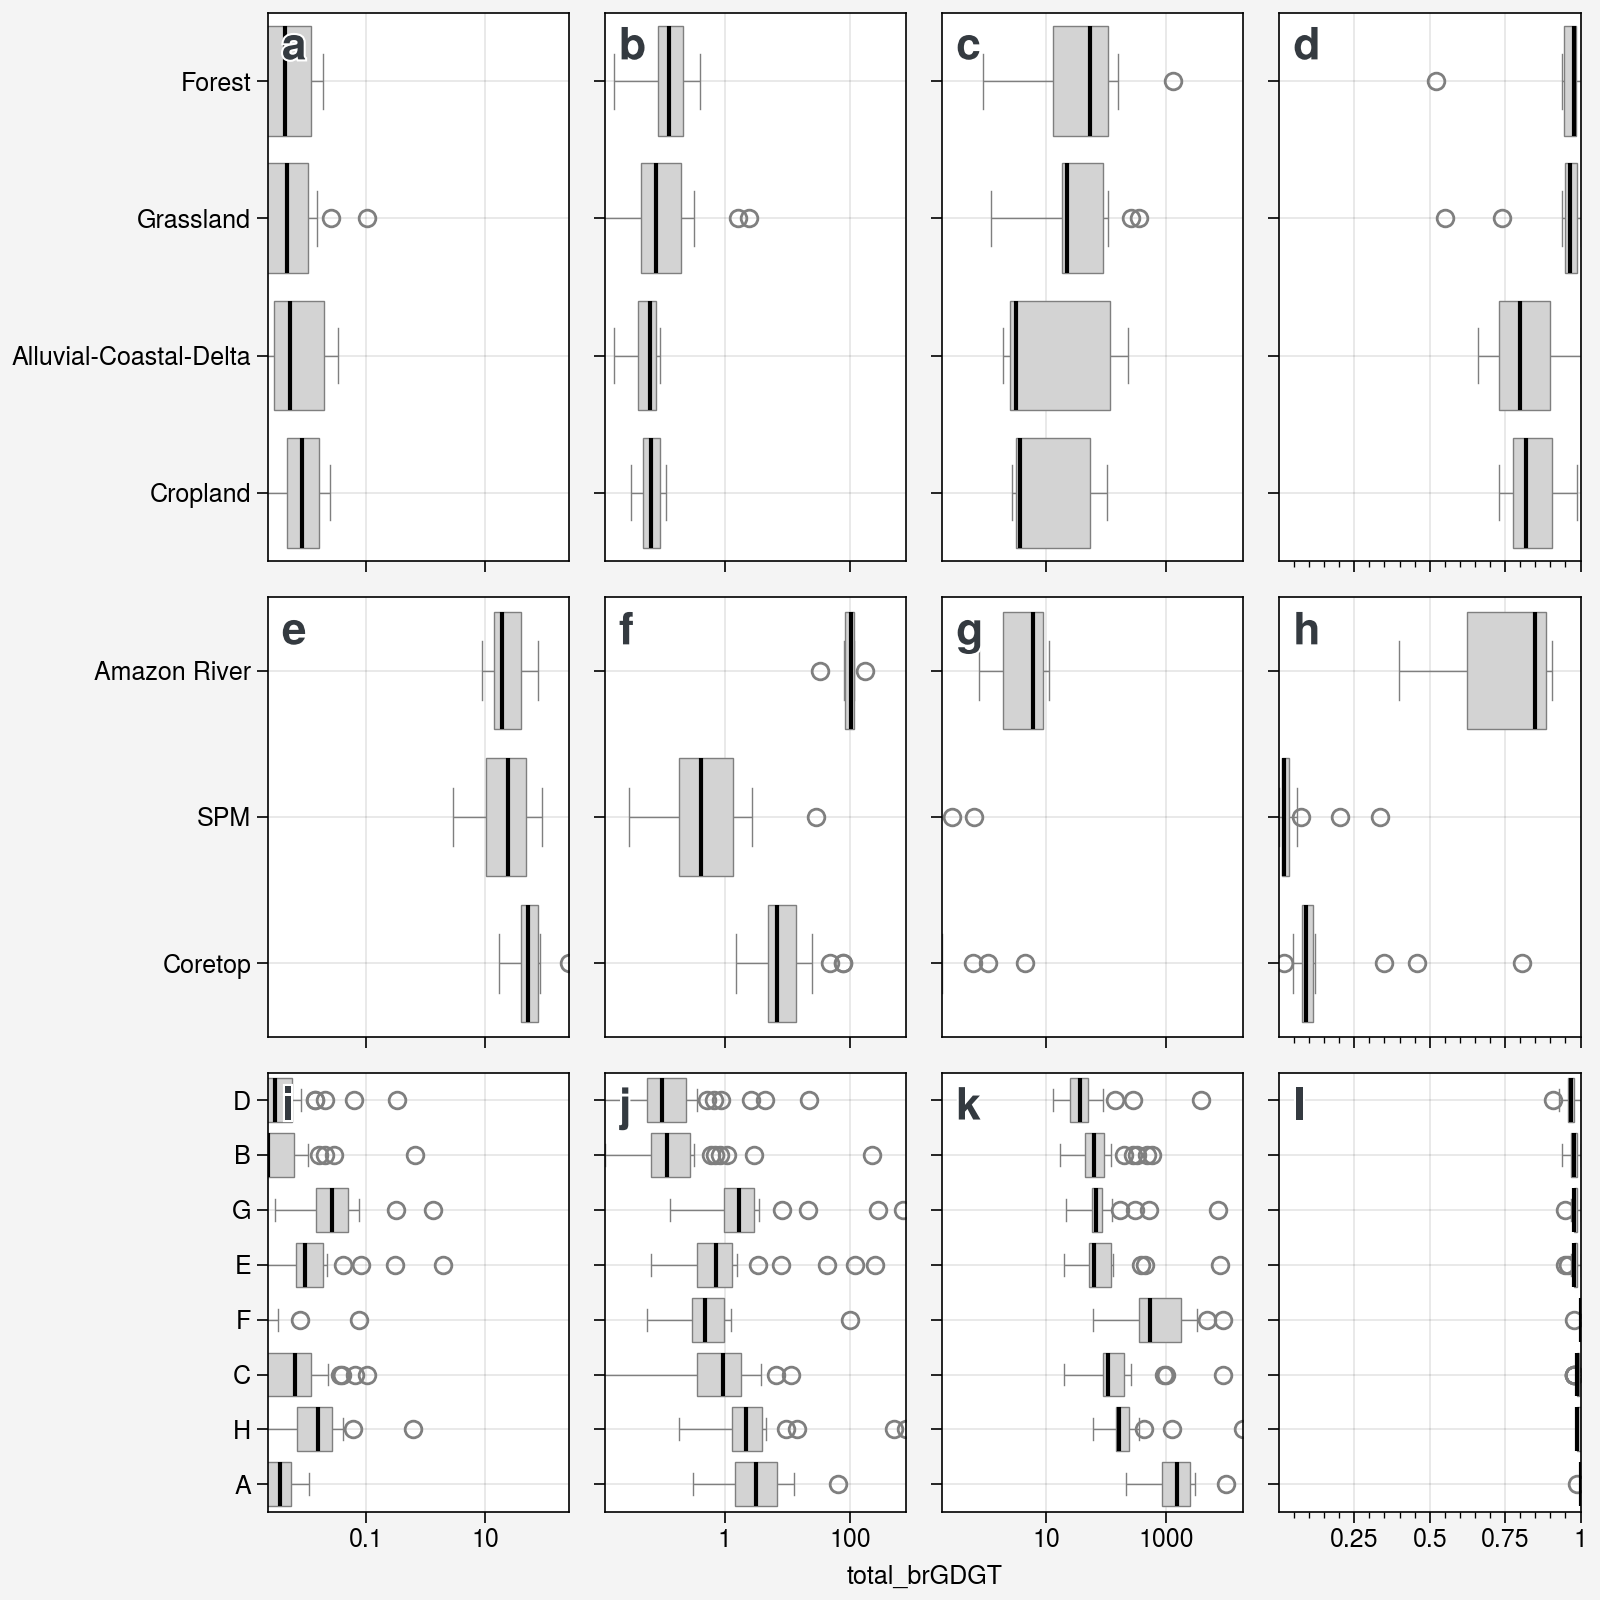

In [ ]:
fig, axs = plot.subplots(ncols=4,nrows=3,
                         sharey=False,
                         figsize=(8,8),
                         hratios=[1.25,1,1])

##### boxplots of Weijers06 brGDGTs and crenarchaeol concentrations
features = [
    'Cren_microgram_per_gram',
    'brGDGTs_microgram_per_gram',
    'sum(brGDGTs)/cren',
    'BIT'
]

for i, feature in enumerate(features):
    ax = axs[0,i]
    sns.boxplot(
        data=Weijers06_df,
        y='datatype',
        x=feature,
        ax=ax,
        linewidth=0.5,
        medianprops={'color':'black','linewidth':1.5},
        color='lightgray',
    )
    
##### boxplots of Weijers06 brGDGTs and crenarchaeol concentrations
features = [
    'total_cren',
    'total_brGDGT',
    'total_brGDGT_to_cren_conc',
    'total_BIT'
]

for i, feature in enumerate(features):
    ax = axs[1,i]
    sns.boxplot(
        data=Zell14_df2,
        y='datatype',
        x=feature,
        ax=ax,
        linewidth=0.5,
        medianprops={'color':'black','linewidth':1.5},
        color='lightgray',
        legend=False,
    )

##### boxplots of DeJonge24 brGDGTs and crenarchaeol concentrations
features = [
    'Cren_microgram_per_gram',
    'brGDGTs_microgram_per_gram',
    'sum(brGDGTs)/cren',
    'BIT'
    ]
for i, feature in enumerate(features):
    ax = axs[2,i]
    sns.boxplot(
        data=DeJonge24_df,
        y='Sample',
        x=feature,
        ax=ax,
        linewidth=0.5,
        medianprops={'color':'black','linewidth':1.5},
        color='lightgray',
    )
    

axs[:,:-1].format(
    xscale='log',
    # xlim=(1e-3,1e3)
)

axs[:,1:].format(
    yticklabels=[]
)


axs.format(
    abc=True,abcloc='ul',
    abcstyle='a',abcsize=16,
    abccolor='gray8',
    
    # xlabel=r'Concentrations (ng g$^{-1}$ soil or ng extract$^{-1}$; columns 1-2) or Cren:brGDGTs concentration ratio (1:xxx) or BIT (column 4)',
    xreverse=False,
    grid=True,
    ytickminor=False,
    
    ylabel='',
    # rowlabels=['Weijers et al. (2006)','De Jonge et al. (2024)'],
)

Period: Quaternary, Outlier: Included, len: 1621
Period: Quaternary, Outlier: Excluded, len: 499
Period: Quaternary, Outlier: False, len: 2006
Period: Quaternary, Outlier: True, len: 114
Period: Neogene, Outlier: Included, len: 1710
Period: Neogene, Outlier: Excluded, len: 708
Period: Neogene, Outlier: False, len: 1719
Period: Neogene, Outlier: True, len: 699
Period: Paleogene, Outlier: Included, len: 1278
Period: Paleogene, Outlier: Excluded, len: 810
Period: Paleogene, Outlier: False, len: 1409
Period: Paleogene, Outlier: True, len: 679
Period: Cretaceous, Outlier: Included, len: 830
Period: Cretaceous, Outlier: Excluded, len: 319
Period: Cretaceous, Outlier: False, len: 925
Period: Cretaceous, Outlier: True, len: 224
Period: Jurassic, Outlier: Included, len: 51
Period: Jurassic, Outlier: Excluded, len: 28
Period: Jurassic, Outlier: False, len: 59
Period: Jurassic, Outlier: True, len: 20


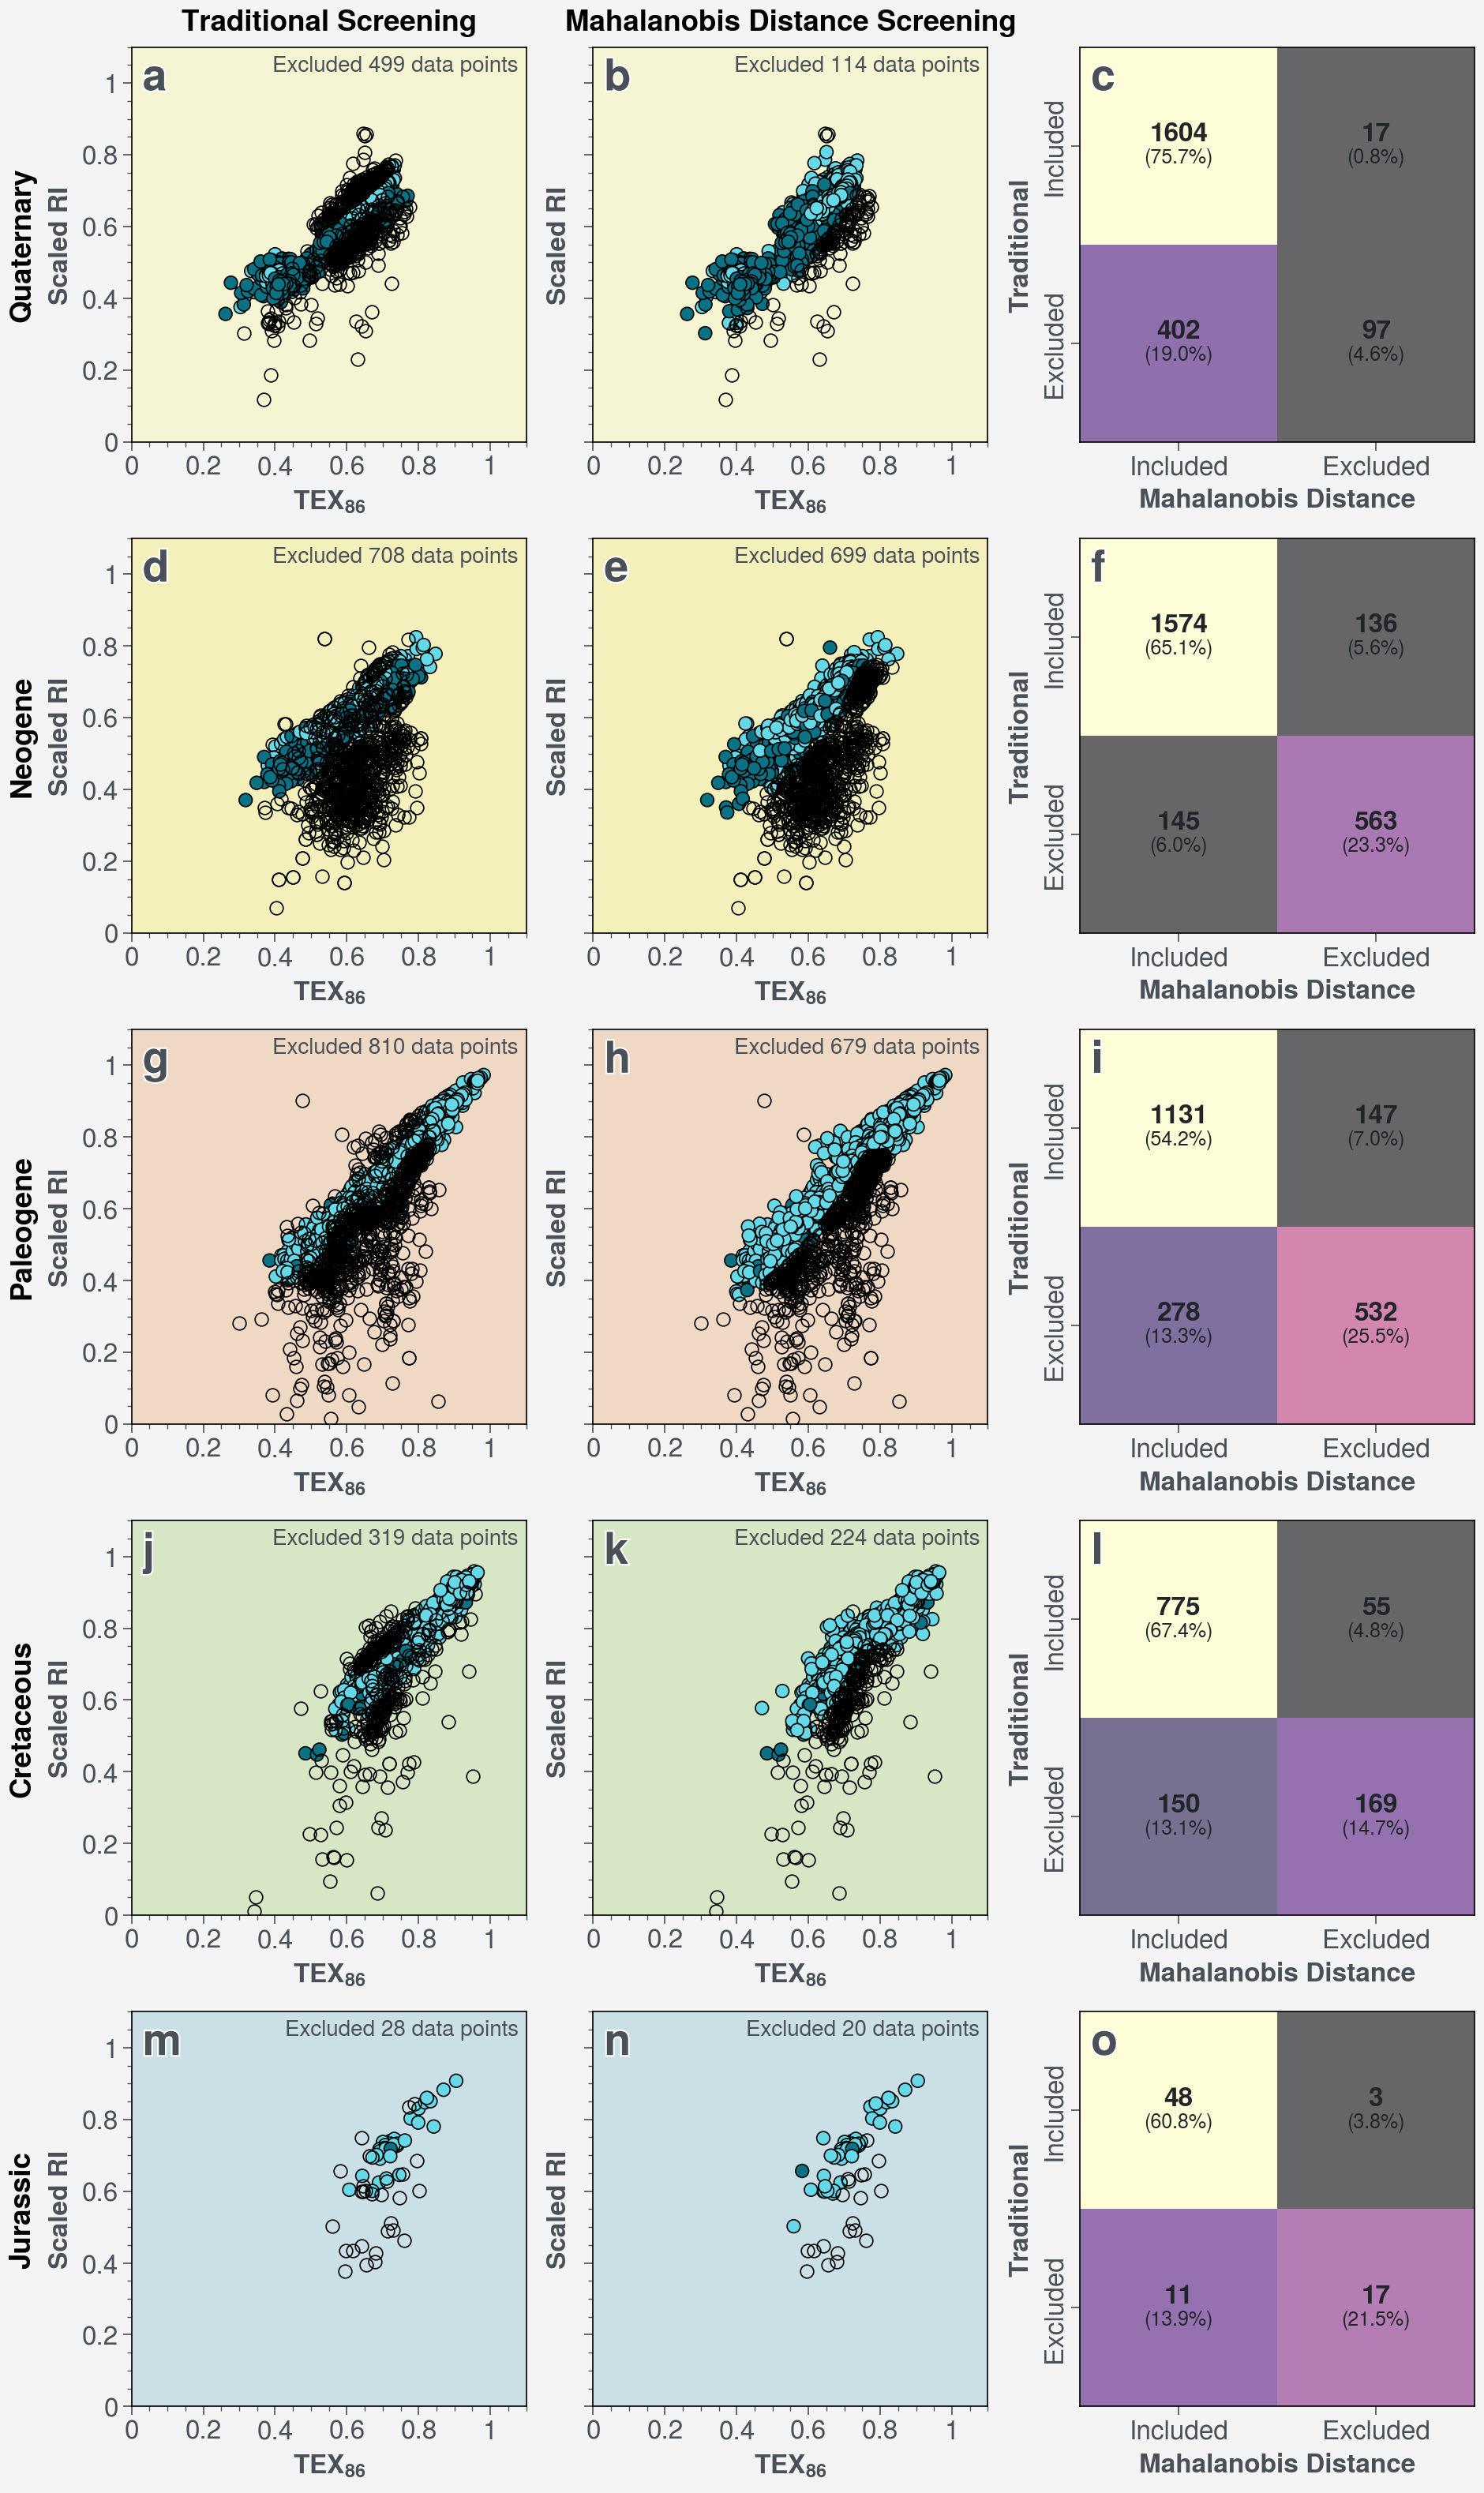

In [ ]:
fig, axs = plot.subplots(ncols=3,nrows=5,share=0)

catDtype = pd.api.types.CategoricalDtype(categories=['Quaternary','Neogene','Paleogene','Cretaceous','Jurassic'], ordered=True)

plot_data = PhanTEX_df.copy()
plot_data['Period'] = plot_data['Period'].astype(catDtype)
plot_data['binned_BIT'] = pd.cut(plot_data['BIT'], bins=[0,0.3,1.0], labels=['Low BIT (0-0.3)','High BIT (0.3-1.0)'])
plot_data['binned_MI'] = pd.cut(plot_data['MI'], bins=[0,0.3,1.0], labels=['Low MI (0-0.3)','High MI (0.3-1.0)'])
plot_data['binned_absDRI'] = pd.cut(abs(plot_data['dRI']), bins=[0,0.3,2], labels=['Low |ΔRI| (0-0.3)','High |ΔRI| (0.3-2)'])
plot_data['traditional_outlier'] = ((abs(plot_data['dRI']) > 0.3) | (plot_data['BIT'] > 0.3) | (plot_data['MI'] > 0.3))

grouped_period = plot_data.groupby('Period')
for i, (name, group) in enumerate(grouped_period):
    
    ### traditional data screening
    ax = axs[i,0]
    ax.format(facecolor=period_color_dict.get(name,'gray7'),alpha=0.3)
    
    exclude_idx = ((abs(group['dRI']) > 0.3) | (group['BIT'] > 0.3) | (group['MI'] > 0.3))
    include_idx = ~exclude_idx
    for key, group2 in [('Included', group[include_idx]), ('Excluded', group[exclude_idx])]:
        print(f'Period: {name}, Outlier: {key}, len: {len(group2)}')
        ax.scatter(group2['TEX86'], group2['scaledRI'],
                   m = 'o', # if key=='Excluded' else '.',
                   c='none' if key=='Excluded' else group2['gdgt23ratio'],
                   cmap = 'none' if key=='Excluded' else plot.Colormap(['cyan3','cyan9']),
                   levels= 'none' if key=='Excluded' else [0,5,50],
                   mec='k', # if key=='Excluded' else 'none',
                   zorder=1 if key=='Excluded' else 0,)
        
    text = f'Excluded {len(group[exclude_idx])} data points'
    ax.text(0.98, 0.98, text, transform=ax.transAxes,
            ha='right', va='top',c='gray7',
            fontsize=10)
    
    ax = axs[i,1]
    ax.format(facecolor=period_color_dict.get(name,'gray7'),alpha=0.3)
    
    grouped_filter = group.groupby('TEXRI_mahalDist_low23ratio_outliers_manual')
    exclude_idx = group['TEXRI_mahalDist_low23ratio_outliers_manual']==True
    for key, group2 in grouped_filter:
        print(f'Period: {name}, Outlier: {key}, len: {len(group2)}')
        ax.scatter(group2['TEX86'], group2['scaledRI'],
                   m = 'o', # if key else '.',
                   c='none' if key else group2['gdgt23ratio'],
                   cmap = 'none' if key else plot.Colormap(['cyan3','cyan9']),
                   levels= 'none' if key else [0,5,50],
                   mec='k', # if key else 'none',
                   zorder=1 if key else 0,)
        
    text = f'Excluded {len(group[exclude_idx])} data points'
    ax.text(0.98, 0.98, text, transform=ax.transAxes,
            ha='right', va='top',c='gray7',
            fontsize=10)
    
    #####
    ax = axs[i,2]
    table_df = pd.pivot_table(group, index='traditional_outlier', 
                              columns='TEXRI_mahalDist_low23ratio_outliers_manual', 
                              values='TEX86', aggfunc='count', fill_value=0)
    
    ax.pcolormesh(np.array(table_df), cmap='magma',
                  vmin=0, vmax=table_df.values.max(), 
                  alpha=0.6, zorder=0)
                   
    ### annotate counts
    for row_idx, row in enumerate(table_df.index):
        for col_idx, col in enumerate(table_df.columns):
            count = table_df.loc[row, col]
            ax.text(col_idx, row_idx-0.06, str(count),
                    ha='center', va='center', c='gray9', fontsize=12, fontweight='bold')
            
            count_percent = count / len(group) * 100
            ax.text(col_idx, row_idx+0.06, f'({count_percent:.1f}%)',
                    ha='center', va='center', c='gray9', fontsize=9,)
    
    ax.format(
        xlabel='Mahalanobis Distance',
        xticks=[0,1],
        xticklabels=['Included','Excluded'],
        xtickminor=False,
        
        ylabel='Traditional',
        yticks=[0,1],
        yticklabels=['Included','Excluded'],
        ytickminor=False,
        yreverse=True,
    )


axs.format(rowlabels=['Quaternary','Neogene','Paleogene','Cretaceous','Jurassic'],
           collabels=['Traditional Screening','Mahalanobis Distance Screening',''],
           labelsize=12, fontsize=12,
           labelcolor='gray7',xtickcolor='gray7',ytickcolor='gray7',
           xticklabelcolor='gray7',yticklabelcolor='gray7',
           xlabelweight='bold', ylabelweight='bold',
           grid=False,
           )

axs[:,1:2].format(
    ylabel='',yticklabels=[],
)

axs[:,2].format(
    yrotation=90,
)

for ax in axs[:,2]:
    for label in ax.get_yticklabels():
        label.set_va('center')



axs[:,:2].format(
           xlabel=r'TEX$_{86}$',
           ylabel='Scaled RI',
           xlim=(0,1.1),
           ylim=(0,1.1)
)

axs.format(abcstyle='a',abcloc='ul',abcsize=20,abcweight='bold',abccolor='gray7',)

fpath = fr'{local_github_path}/figures/manuscript/finalized/supplementary'
fname = f'figSx_TEXRI_mahalanobis_distance_screening_by_geologicAge.pdf'
fig.savefig(os.path.join(fpath,fname),dpi=300,rasterized=True,format='pdf')

## 3.3 Gridded coretop dataset

In [ ]:
clean_coretop_df = combined_df_raw[(combined_df_raw['datatype']=='coretop') &
                                   (combined_df_raw['TEXRI_mahalDist_low23ratio_outliers_manual']==False) & 
                                   (combined_df_raw['lowAbundanceFlag']==False)]

display(clean_coretop_df)

clean_culmeso_df = combined_df_raw[(combined_df_raw['datatype']!='coretop') &
                                   (combined_df_raw['TEXRI_mahalDist_low23ratio_outliers_manual']==False) & 
                                   (combined_df_raw['lowAbundanceFlag']==False)]

display(clean_culmeso_df)

,sampleID,Latitude,Longitude,match_lat_04deg,match_lon_04deg,match_lat_1deg,match_lon_1deg,modernWaterDepth,t_sf2tc_avg,t_sf2tc_1deg_04filled,...,TEXRIfG0_mahalDist_low23ratio_outliers_manual,TEXRIpercentG0_mahalDist_low23ratio,TEXRIpercentG0_mahalDist_low23ratio_outliers,TEXRIpercentG0_mahalDist_low23ratio_outliers_manual,TEXRIfG0Cren_mahalDist_low23ratio,TEXRIfG0Cren_mahalDist_low23ratio_outliers,TEXRIfG0Cren_mahalDist_low23ratio_outliers_manual,allGDGTs_mahalDist_low23ratio,allGDGTs_mahalDist_low23ratio_outliers,allGDGTs_mahalDist_low23ratio_outliers_manual
0,TEXAS_RR_0000,-1.53,-86.79,-1.62,-86.88,-1.50,-86.50,2288.00,22.52,22.17,...,False,1.40,False,False,1.46,False,False,4.14,True,True
1,TEXAS_RR_0001,-3.97,-81.31,-3.88,-81.38,-3.50,-81.50,1024.00,21.32,21.32,...,False,0.99,False,False,0.91,False,False,1.89,False,False
2,TEXAS_RR_0002,-3.58,-81.17,-3.62,-81.12,-3.50,-81.50,381.00,22.09,22.09,...,False,1.16,False,False,1.27,False,False,1.62,False,False
3,TEXAS_RR_0003,-3.22,-82.91,-3.12,-82.88,-3.50,-82.50,2949.00,20.62,20.92,...,False,1.30,False,False,1.27,False,False,2.85,False,False
4,TEXAS_RR_0004,-3.60,-83.96,-3.62,-83.88,-3.50,-83.50,3224.00,21.17,21.46,...,False,1.32,False,False,1.85,False,False,3.70,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010,TEXAS_RR_2010,76.48,-77.77,76.38,-77.88,76.50,-77.50,378.00,-0.59,-0.59,...,True,2.24,False,False,3.03,True,True,3.29,True,True
2011,TEXAS_RR_2011,76.26,-74.61,76.38,-74.62,76.50,-74.50,449.00,-0.71,-0.61,...,True,2.33,False,False,2.81,True,True,3.23,False,False
2018,TEXAS_RR_2018,71.41,-70.89,71.38,-70.88,71.50,-70.50,702.00,0.54,NaN,...,False,2.72,True,True,2.15,False,False,3.86,True,True
2022,TEXAS_RR_2022,-31.58,164.45,-31.62,164.38,-31.50,164.50,2131.00,20.46,20.57,...,False,2.23,False,False,2.34,False,False,3.41,True,True


,sampleID,Latitude,Longitude,match_lat_04deg,match_lon_04deg,match_lat_1deg,match_lon_1deg,modernWaterDepth,t_sf2tc_avg,t_sf2tc_1deg_04filled,...,TEXRIfG0_mahalDist_low23ratio_outliers_manual,TEXRIpercentG0_mahalDist_low23ratio,TEXRIpercentG0_mahalDist_low23ratio_outliers,TEXRIpercentG0_mahalDist_low23ratio_outliers_manual,TEXRIfG0Cren_mahalDist_low23ratio,TEXRIfG0Cren_mahalDist_low23ratio_outliers,TEXRIfG0Cren_mahalDist_low23ratio_outliers_manual,allGDGTs_mahalDist_low23ratio,allGDGTs_mahalDist_low23ratio_outliers,allGDGTs_mahalDist_low23ratio_outliers_manual
2024,TEXAS_RR_2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.00,37.00,...,True,14.45,True,True,13.22,True,True,39.53,True,True
2025,TEXAS_RR_2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.00,46.00,...,False,3.05,True,False,14.03,True,False,25.16,True,True
2030,TEXAS_RR_2030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.00,18.00,...,True,4.79,True,True,8.95,True,True,9.86,True,True
2041,TEXAS_RR_2041,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.00,15.00,...,True,6.88,True,True,6.33,True,True,8.11,True,True
2042,TEXAS_RR_2042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.00,20.00,...,True,8.28,True,True,5.71,True,True,6.80,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,TEXAS_RR_2121,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.00,22.00,...,False,3.35,True,True,2.71,False,False,3.73,True,True
2125,TEXAS_RR_2125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.00,25.00,...,False,2.58,True,True,2.49,False,False,3.68,True,True
2127,TEXAS_RR_2127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.00,32.00,...,False,2.62,True,True,1.90,False,False,1.44,False,False
2129,TEXAS_RR_2129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.00,36.00,...,False,3.82,True,False,5.22,True,False,4.51,True,True


#### 04deg gridded

In [ ]:
nonnumeric_cols = ['regionName','reference_name','datatype', 'Strains',
       'organism_commonName', 'organism_broadClass', 'organism_broadClass2',
       'organism_broadClass3', 'publicationYear']

gridded_coretop_04deg_df = pd.pivot_table(
    clean_coretop_df,
    index=['match_lat_04deg','match_lon_04deg'],
    values=nonnumeric_cols,
    aggfunc='first',
    sort=False,
).reset_index()

display(gridded_coretop_04deg_df)

numeric_cols = ['Latitude','Longitude','modernWaterDepth', 'TEX86', 'BIT',
       'methaneIndex', 'ringIndex', 'scaledRI',
       'gdgt23ratio','ZeroOverZeroCren', 'SST', 'SST_1deg_04filled',
       'SST_1deg', 't_sf2tc_avg', 't_sf2tc_1deg_04filled',
       't1deg_sf2tc_1deg_04filled', 't_sf2tc_1deg', 'no3_sf2tc_avg',
       'no3_sf2tc_tc1deg04filled', 'woa23_no3_sf2tc_tc1deg04filled',
       'woa23_no3_sf2tc_1deg', 'nh4_sf2tc_avg', 'no2_sf2tc_avg',
       't_sf2pc_avg']
temp_numeric_gridded = pd.pivot_table(clean_coretop_df, values=numeric_cols, index=['match_lat_04deg','match_lon_04deg'],aggfunc='median').reset_index()

display(temp_numeric_gridded)

gridded_combined_df = pd.merge(gridded_coretop_04deg_df,temp_numeric_gridded,how='right')

sel_columns = gridded_combined_df.columns

gridded_combined_df = pd.concat([gridded_combined_df, clean_culmeso_df[sel_columns]], axis=0)
gridded_combined_df

,match_lat_04deg,match_lon_04deg,regionName,reference_name,datatype,Strains,organism_commonName,organism_broadClass,organism_broadClass2,organism_broadClass3,publicationYear
0,-1.62,-86.88,East Equatorial Pacific,Rattanasriampaipong2025,coretop,coretop,coretop,coretop,coretop,coretop,2025.00
1,-3.88,-81.38,East Equatorial Pacific,Rattanasriampaipong2025,coretop,coretop,coretop,coretop,coretop,coretop,2025.00
2,-3.62,-81.12,East Equatorial Pacific,Rattanasriampaipong2025,coretop,coretop,coretop,coretop,coretop,coretop,2025.00
3,-3.12,-82.88,East Equatorial Pacific,Rattanasriampaipong2025,coretop,coretop,coretop,coretop,coretop,coretop,2025.00
4,-3.62,-83.88,East Equatorial Pacific,Rattanasriampaipong2025,coretop,coretop,coretop,coretop,coretop,coretop,2025.00
...,...,...,...,...,...,...,...,...,...,...,...
1472,76.38,-77.88,Baffin Bay,Harning2023,coretop,coretop,coretop,coretop,coretop,coretop,2023.00
1473,76.38,-74.62,Baffin Bay,Harning2023,coretop,coretop,coretop,coretop,coretop,coretop,2023.00
1474,71.38,-70.88,Baffin Bay,Harning2023,coretop,coretop,coretop,coretop,coretop,coretop,2023.00
1475,-31.62,164.38,Tasman Sea,Rattanasriampaipong2025,coretop,coretop,coretop,coretop,coretop,coretop,2025.00


,match_lat_04deg,match_lon_04deg,BIT,Latitude,Longitude,SST,SST_1deg,SST_1deg_04filled,TEX86,ZeroOverZeroCren,...,no3_sf2tc_tc1deg04filled,ringIndex,scaledRI,t1deg_sf2tc_1deg_04filled,t_sf2pc_avg,t_sf2tc_1deg,t_sf2tc_1deg_04filled,t_sf2tc_avg,woa23_no3_sf2tc_1deg,woa23_no3_sf2tc_tc1deg04filled
0,-77.88,-40.38,0.00,-77.80,-40.45,-1.65,NaN,-1.65,0.41,0.49,...,NaN,2.04,0.51,-1.62,-1.66,NaN,-1.62,-1.64,NaN,NaN
1,-77.38,-158.38,NaN,-77.47,-158.27,-1.51,NaN,-1.51,0.35,0.56,...,NaN,1.75,0.44,-1.59,-1.55,NaN,-1.59,-1.59,NaN,NaN
2,-77.12,-45.38,0.01,-77.02,-45.41,-1.70,NaN,-1.70,0.37,0.59,...,NaN,1.64,0.41,-1.69,-1.68,NaN,-1.69,-1.69,NaN,NaN
3,-76.62,-35.38,0.01,-76.64,-35.43,-1.43,NaN,-1.43,0.34,0.57,...,28.34,1.73,0.43,-1.46,NaN,NaN,-1.46,-1.50,NaN,28.34
4,-76.38,-33.88,0.01,-76.38,-33.93,-1.75,-1.52,-1.52,0.34,0.55,...,29.04,1.79,0.45,-1.53,NaN,-1.64,-1.64,-1.65,22.07,22.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1472,84.12,46.62,NaN,84.01,46.72,-1.49,-1.55,-1.55,0.37,0.55,...,6.73,1.79,0.45,-1.60,-1.67,-1.55,-1.55,-1.24,4.47,4.47
1473,84.88,40.62,0.58,84.88,40.60,-1.64,-1.65,-1.65,0.37,0.56,...,6.71,1.76,0.44,-1.68,-1.73,-1.66,-1.66,-1.37,4.12,4.12
1474,86.88,-146.12,NaN,87.00,-146.00,-1.57,-1.61,-1.61,0.44,0.61,...,7.23,1.60,0.40,-1.61,-1.61,-1.57,-1.57,-1.47,0.48,0.48
1475,87.12,104.62,NaN,87.07,104.66,-1.73,-1.74,-1.74,0.50,0.58,...,8.95,1.73,0.43,0.10,-1.76,0.13,0.13,-1.38,8.07,8.07


,match_lat_04deg,match_lon_04deg,regionName,reference_name,datatype,Strains,organism_commonName,organism_broadClass,organism_broadClass2,organism_broadClass3,...,no3_sf2tc_tc1deg04filled,ringIndex,scaledRI,t1deg_sf2tc_1deg_04filled,t_sf2pc_avg,t_sf2tc_1deg,t_sf2tc_1deg_04filled,t_sf2tc_avg,woa23_no3_sf2tc_1deg,woa23_no3_sf2tc_tc1deg04filled
0,-77.88,-40.38,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,NaN,2.04,0.51,-1.62,-1.66,NaN,-1.62,-1.64,NaN,NaN
1,-77.38,-158.38,Ross Sea,Kim2010,coretop,coretop,coretop,coretop,coretop,coretop,...,NaN,1.75,0.44,-1.59,-1.55,NaN,-1.59,-1.59,NaN,NaN
2,-77.12,-45.38,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,NaN,1.64,0.41,-1.69,-1.68,NaN,-1.69,-1.69,NaN,NaN
3,-76.62,-35.38,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,28.34,1.73,0.43,-1.46,NaN,NaN,-1.46,-1.50,NaN,28.34
4,-76.38,-33.88,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,29.04,1.79,0.45,-1.53,NaN,-1.64,-1.64,-1.65,22.07,22.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,NaN,NaN,mesocosm,Wuchter2004,mesocosm,mesocosm,NorthSea_mesocosm,NorthSea_mesocosm,mesocosm,mesocosm,...,NaN,2.68,0.67,22.00,22.00,22.00,22.00,22.00,NaN,NaN
2125,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,NaN,2.45,0.61,25.00,25.00,25.00,25.00,25.00,NaN,NaN
2127,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,NaN,2.63,0.66,32.00,32.00,32.00,32.00,32.00,NaN,NaN
2129,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,NaN,3.60,0.90,36.00,36.00,36.00,36.00,36.00,NaN,NaN


In [ ]:
generalized_logistic_model_fixed_upper

<function __main__.generalized_logistic_model_fixed_upper(x, x0, b, k, v, Q)>

SST:
x0: 32.497, b: 0.416, k: 0.187, v: 2.439, Q: 2.370
t_sf2tc_avg:
x0: 27.831, b: 0.432, k: 0.153, v: 1.475, Q: 1.874


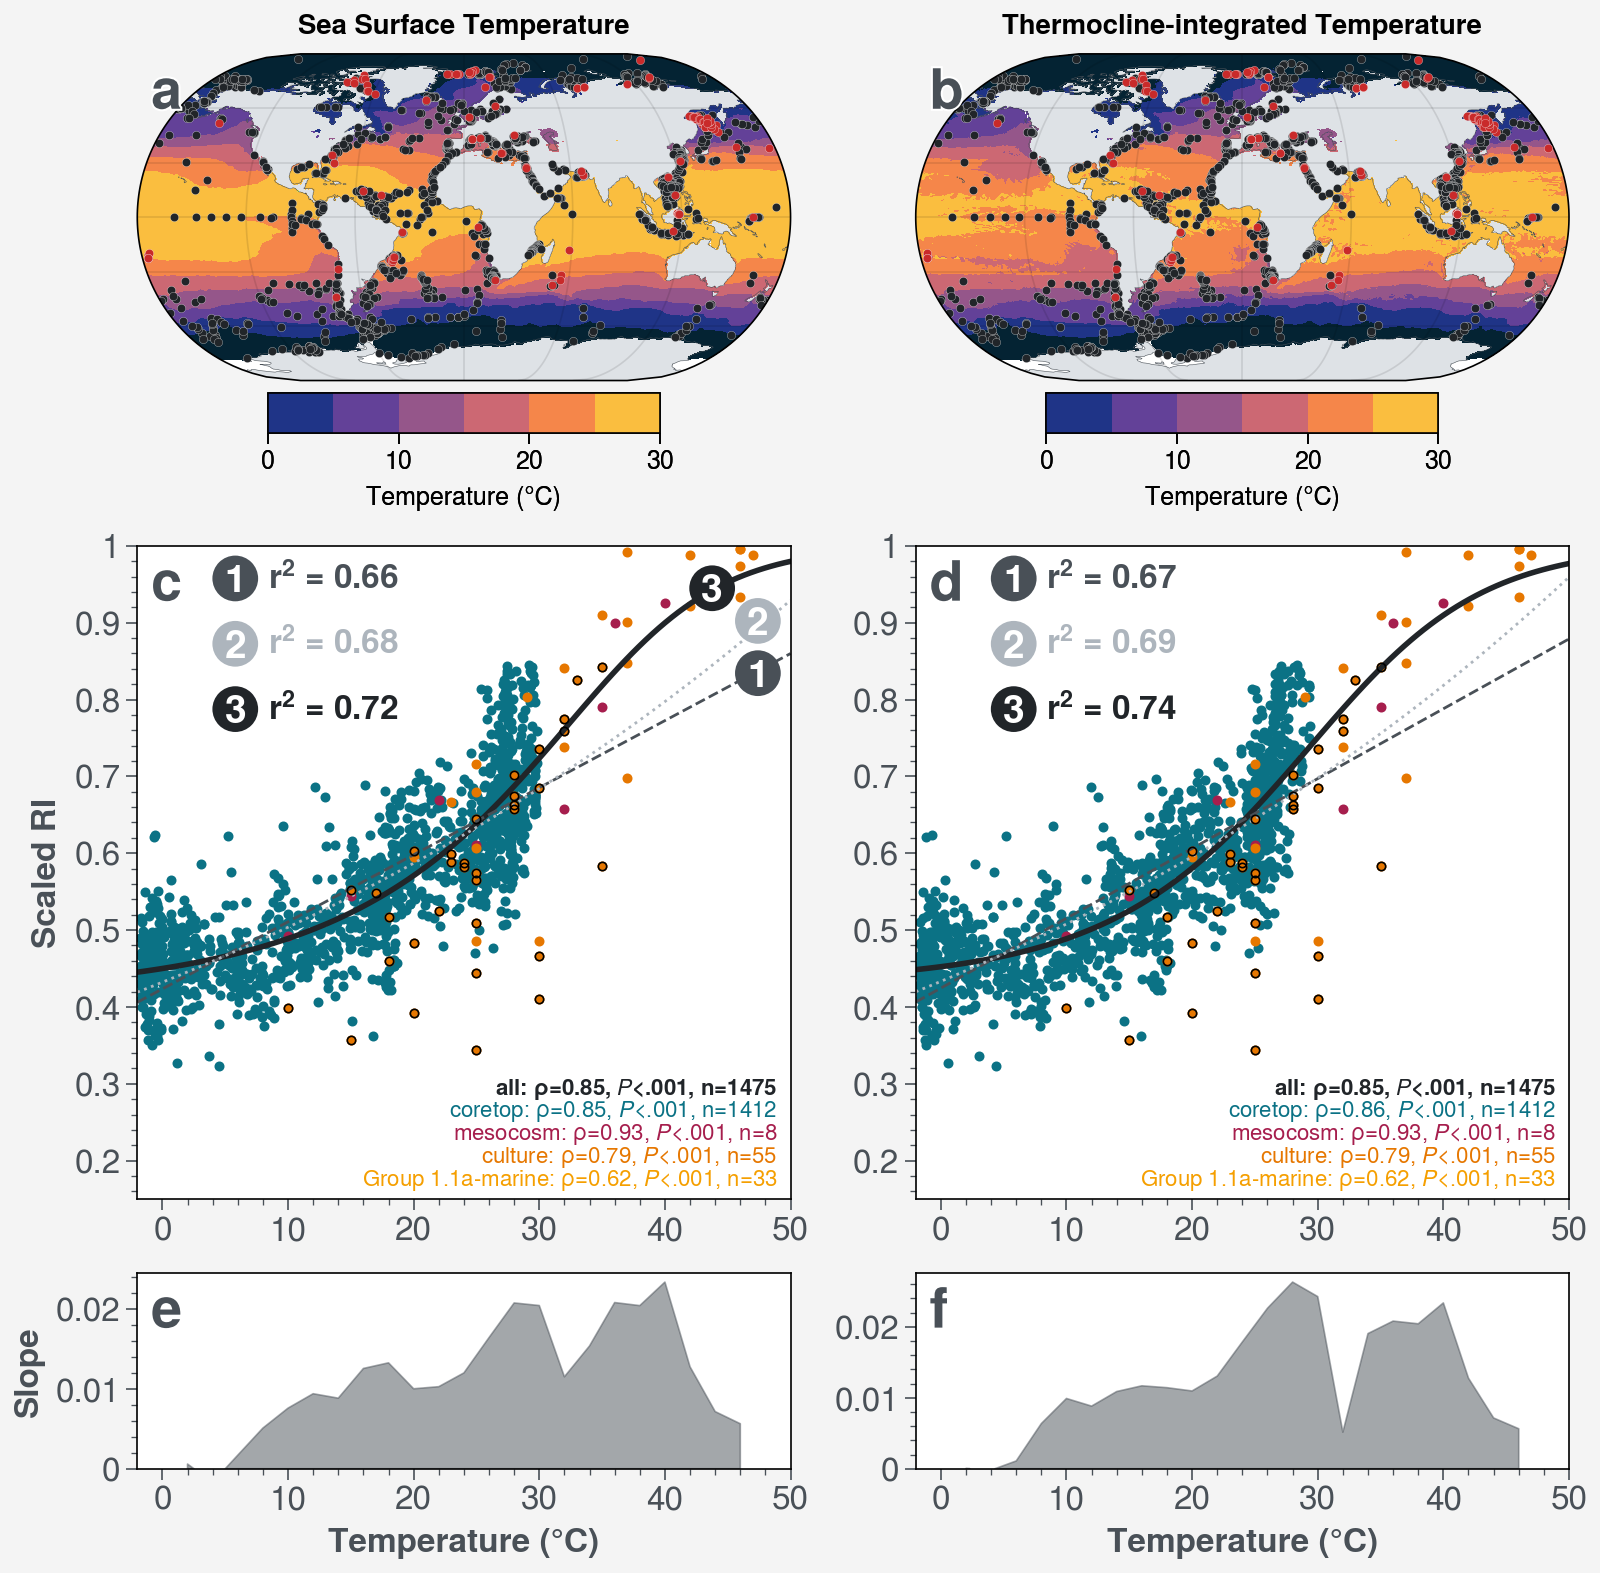

In [ ]:
# 2) Build your data dict exactly as before
plot_data = gridded_combined_df
plot_data = plot_data.sort_values('datatype', key=lambda x: x.map({'coretop': 0, 'mesocosm': 1, 'culture': 2})).reset_index(drop=True)

fig, axs = plot.subplots(width=8,ncols=2,nrows=3,share=False,
                         proj={1:'eck3',2:'eck3'},hratios=[0.5,1,0.3])

axs.format(collabels=['Sea Surface Temperature','Thermocline-integrated Temperature'],)
axs[0,:].format(coast=True,land=True,
                landcolor='gray3',coastcolor='gray7',
                landzorder=0,coastzorder=1,
                coastlinewidth=0.2,
                )
ax = axs[0,0]
m = T_da.isel(depth=0).plot(ax=ax, cmap='thermal',
                        add_colorbar=False,
                        levels=np.arange(0,31,5),
                        extend='both',
                        rasterized=True)
ax.format(title='')
ax.colorbar(m, label='Temperature (°C)', loc='b',shrink=0.6,
            extend='both',)


ax = axs[0,1]
m = ocean_prop_ds['t_sf2tc_avg'].plot(ax=ax, cmap='thermal',
                        add_colorbar=False,
                        levels=np.arange(0,31,5),
                        extend='both',
                        rasterized=True)
ax.format(title='')
ax.colorbar(m, label='Temperature (°C)', loc='b',shrink=0.6,
            extend='both',)
### plot coretop locations
excluded_coretop = combined_df_raw[(combined_df_raw['datatype']=='coretop') &
                                   (combined_df_raw['TEXRI_mahalDist_low23ratio_outliers_manual']==True) & 
                                   (combined_df_raw['lowAbundanceFlag']==False)]

for ax in axs[0,:]:
        plot_lat = plot_data['Latitude']
        plot_lon = plot_data['Longitude']
        ax.scatter(plot_lon, plot_lat, 
                   c='gray9', marker='.', edgecolor='white', 
                   linewidth=0.1,zorder=2)
        
        plot_excluded_lat = excluded_coretop['Latitude']
        plot_excluded_lon = excluded_coretop['Longitude']
        ax.scatter(plot_excluded_lon, plot_excluded_lat,
                   c='red9', marker='.', edgecolor='white', 
                   linewidth=0.1, label='Excluded',zorder=3)
temp_params = ['SST', 't_sf2tc_avg']  
y_param = 'scaledRI'
for i, temp_param in enumerate(temp_params):
        grouped = plot_data.groupby('datatype', sort=False)
        for ii, (name, group) in enumerate(grouped):
                plot_x = group[temp_param]
                plot_y = group[y_param]
                axs[1,i].scatter(plot_x, plot_y, marker='.', label=name,
                                c=datatype_color_dict.get(name,'gray7'))


                reg_data = group[[temp_param,y_param]].dropna(how='any')
                rho, pval = spearmanr(reg_data[temp_param], reg_data[y_param])
                pval_label = label_pvalues(pval)
                axs[1,i].text(0.98, 0.115-(0.035*ii), f'{name}: ρ={rho:.2f}, {pval_label}, n={len(reg_data)}', 
                              transform=axs[1,i].transAxes,
                              ha='right', va='bottom',c=datatype_color_dict.get(name,'gray7'),
                              fontsize=8)
                
                
                if name == 'culture':
                        marine_group11a_idx = group[group['organism_broadClass3'].isin(['Group 1.1a-marine'])].index
                        plot_xxx = group.loc[marine_group11a_idx, temp_param]
                        plot_yyy = group.loc[marine_group11a_idx, y_param]
                        
                        axs[1,i].scatter(plot_xxx, plot_yyy, label='Group 1.1a-marine', edgecolor='black', facecolor='none', m='.', zorder=3)
                        
                        ###
                        nonnan_idx_11a = (~plot_xxx.isna()) & (~plot_yyy.isna())
                        reg_x_11a = plot_xxx[nonnan_idx_11a]
                        reg_y_11a = plot_yyy[nonnan_idx_11a]
                        rho_11a, pval_11a = spearmanr(reg_x_11a, reg_y_11a)
                        pval_label_11a = label_pvalues(pval_11a)
                        
                        axs[1,i].text(0.98, 0.01, fr'Group 1.1a-marine: $\rho$={rho_11a:.2f}, {pval_label_11a}, n={len(reg_y_11a)}',
                                        transform=axs[1,i].transAxes,
                                        ha='right',va='bottom',
                                        fontsize=8, color='yellow7')
                

functional_form_labels = ['Sigmoid', 'Linear', 'Ln-Linear'] 
for i, temp_param in enumerate(temp_params): 
        ### spearman rho and p-value
        reg_data = plot_data[[temp_param,y_param]].dropna(how='any')
        rho, pval = spearmanr(reg_data[temp_param], reg_data[y_param])
        pval_label = label_pvalues(pval)
        text = f'all: ρ={rho:.2f}, {pval_label}, n={len(reg_data)}'
        axs[1,i].text(0.98, 0.15, text, transform=axs[1,i].transAxes,
                ha='right', va='bottom',c='gray9',
                fontsize=8,fontweight='bold',)

        # generalized logistic regression between SST and scaled RI
        popt, pcov = curve_fit(
                generalized_logistic_model_fixed_upper,
                reg_data[temp_param],reg_data[y_param], 
                p0=[20, 0.1, 0.2, 1, 1], 
                bounds=([0, 0, 0, 0.1, 0], [50, 0.5, 5, 5, 5])
        )
        
        print(f"{temp_param}:")
        print(f"x0: {popt[0]:.3f}, b: {popt[1]:.3f}, k: {popt[2]:.3f}, v: {popt[3]:.3f}, Q: {popt[4]:.3f}")
        
        x_fit = np.linspace(-2,50,100)
        y_fit = generalized_logistic_model_fixed_upper(x_fit, *popt)
        axs[1,i].plot(x_fit, y_fit, color='gray9', linewidth=2, ls='-', label='Generalized Logistic Fit')
        ### r-squared calculation
        residuals = reg_data[y_param] - generalized_logistic_model_fixed_upper(reg_data[temp_param], *popt)
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((reg_data[y_param] - np.mean(reg_data[y_param]))**2)
        r_squared = 1 - (ss_res / ss_tot)
        text_r2 = f'r$^2$ = {r_squared:.2f}'
        axs[1,i].text(0.2, 0.75, text_r2, transform=axs[1,i].transAxes,
                ha='left', va='center',c='gray9',
                fontsize=12,fontweight='bold',)

        ### linear regression between SST and scaled RI
        popt_lin, pcov_lin = curve_fit(
                linear_model,
                reg_data[temp_param],reg_data[y_param], 
                p0=[0.01, 0.1], 
        )
        x_fit_lin = np.linspace(-2,50,100)
        y_fit_lin = linear_model(x_fit_lin, *popt_lin)
        axs[1,i].plot(x_fit_lin, y_fit_lin, color='gray7', linewidth=1, ls='--', label='Linear Fit')
        ### r-squared calculation
        residuals_lin = reg_data[y_param] - linear_model(reg_data[temp_param], *popt_lin)
        ss_res_lin = np.sum(residuals_lin**2)
        ss_tot_lin = np.sum((reg_data[y_param] - np.mean(reg_data[y_param]))**2)
        r_squared_lin = 1 - (ss_res_lin / ss_tot_lin)
        text_r2_lin = f'r$^2$ = {r_squared_lin:.2f}'
        axs[1,i].text(0.2, 0.95, text_r2_lin, transform=axs[1,i].transAxes,
                ha='left', va='center',c='gray7',
                fontsize=12,fontweight='bold',)


        ### linear regression between SST and Ln(scaled RI)
        popt_log10, pcov_log10 = curve_fit(
                linear_model,
                reg_data[temp_param],np.log10(reg_data[y_param]), 
                p0=[0.01, 0.1], 
        )
        x_fit_log10 = np.linspace(-2,50,100)
        y_fit_log10 = linear_model(x_fit_log10, *popt_log10)
        axs[1,i].plot(x_fit_log10, np.power(10, y_fit_log10), color='gray5', linewidth=1, ls=':', label='Ln-Linear Fit')
        ### r-squared calculation
        residuals_log10 = np.log10(reg_data[y_param]) - linear_model(reg_data[temp_param], *popt_log10)
        ss_res_log10 = np.sum(residuals_log10**2)
        ss_tot_log10 = np.sum((np.log10(reg_data[y_param]) - np.mean(np.log10(reg_data[y_param])))**2)
        r_squared_log10 = 1 - (ss_res_log10 / ss_tot_log10)
        text_r2_log10 = f'r$^2$ = {r_squared_log10:.2f}'
        axs[1,i].text(0.2, 0.85, text_r2_log10, transform=axs[1,i].transAxes,
                ha='left', va='center',c='gray5',
                fontsize=12,fontweight='bold',)
        
### draw circles
for ax in axs[1,:]:
        for i in range(3):
                circle = plt.Circle((0.15, 0.95-(i*0.1)), 0.035, 
                                color=['gray7','gray5','gray9'][i], fill=True, lw=0,
                                transform=ax.transAxes)
                ax.add_artist(circle)
                
                text = i+1
                ax.text(0.15, 0.945-(i*0.1), text, transform=ax.transAxes,
                        ha='center', va='center',c='w',
                        fontsize=14,fontweight='bold',)
                
circle_centers = [(0.95,0.8), (0.95,0.88), (0.88,0.93)]
for i, (x, y) in enumerate(circle_centers):
        
        axs[1,0].add_artist(plt.Circle((x, y+0.005), 0.035, 
                        color=['gray7','gray5','gray9'][i], fill=True, lw=0,
                        transform=axs[1,0].transAxes,zorder=3))
        
        axs[1,0].text(x, y, i+1, transform=axs[1,0].transAxes,
                ha='center', va='center',c='w',
                fontsize=14,fontweight='bold',zorder=4,)
        
# h, l = axs[0,1].get_legend_handles_labels()
# axs[0,1].legend(h, ['included coretop',r'excluded coretop by D$_{M}$'], 
#                 loc='r', fontsize=10, ncol=1, frameon=True)

# h, l = axs[1,1].get_legend_handles_labels()
# axs[1,1].legend(h, l, loc='r', fontsize=10, ncol=1, frameon=True)

#### calculate slopes along binned temperature ranges
temp_bin_centers = np.arange(2,47,2)
temp_bin_width = 10
slope_results = []
for i, temp_param in enumerate(temp_params):
    ax = axs[2,i]
    for j, center in enumerate(temp_bin_centers):
        bin_min = center - (temp_bin_width/2)
        bin_max = center + (temp_bin_width/2)
        
        bin_data = plot_data[(plot_data[temp_param]>=bin_min) & (plot_data[temp_param]<bin_max)]
        bin_data = bin_data[[temp_param,y_param]].dropna(how='any')
        
        if len(bin_data) >= 2:
            popt_bin, pcov_bin = curve_fit(
                    linear_model,
                    bin_data[temp_param], bin_data[y_param],
                    p0=[0.01, 0.1],
            )
            slope = popt_bin[0]
            slope_results.append({
                'temp_param': temp_param,
                'temp_bin_center': center,
                'slope': slope
            })
        else:
                continue
        
slope_results_df = pd.DataFrame(slope_results)
# display(slope_results_df)

grouped_slope = slope_results_df.groupby('temp_param')
for i, (name, group) in enumerate(grouped_slope):
        plot_x = group['temp_bin_center'].values
        plot_y = group['slope'].values
        ax = axs[2,i]
        ax.fill_between(plot_x,plot_y,0,where=plot_y>=0, 
                        interpolate=True, color='gray7', alpha=0.5, 
                        label='Positive Slope')

axs[1,:].format(
        grid=False,
        ylim=(0.15,1),
        xlim=(-2,50),
        ylabel='Scaled RI',
        xlabel='',
)

axs[2,:].format(
        xlabel='Temperature (°C)',
        ylabel='Slope',
        xlim=(-2,50),
        grid=False
)

axs[:,1].format(
        ylabel='',
)

axs.format(
        abc=True,abcstyle='a',abcloc='ul',abcsize=20,abcweight='bold',abccolor='gray7',
        fontsize=12,labelsize=12,
        labelcolor='gray7',xtickcolor='gray7',ytickcolor='gray7',
        xticklabelcolor='gray7',yticklabelcolor='gray7',
        xlabelweight='bold', ylabelweight='bold',        
)

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'fig6_functional_from_sst_thermoT.pdf'
fig.savefig(os.path.join(fpath, fname), dpi=300, bbox_inches='tight')

coretop 0.057373792267029024
culture 0.10801433944051261
mesocosm 0.053679671502865116
coretop 0.06236908285952907
culture 0.12740213829767424
mesocosm 0.0866487203639085
coretop 0.06056745068034446
culture 0.11752264058935032
mesocosm 0.0781366558401336
coretop 0.054984001728468165
culture 0.11637621504122327
mesocosm 0.05919131039740159
coretop 0.061562525750596245
culture 0.12650497222523346
mesocosm 0.08002475641606058
coretop 0.0595966160885794
culture 0.1164286203906315
mesocosm 0.06953131388277196


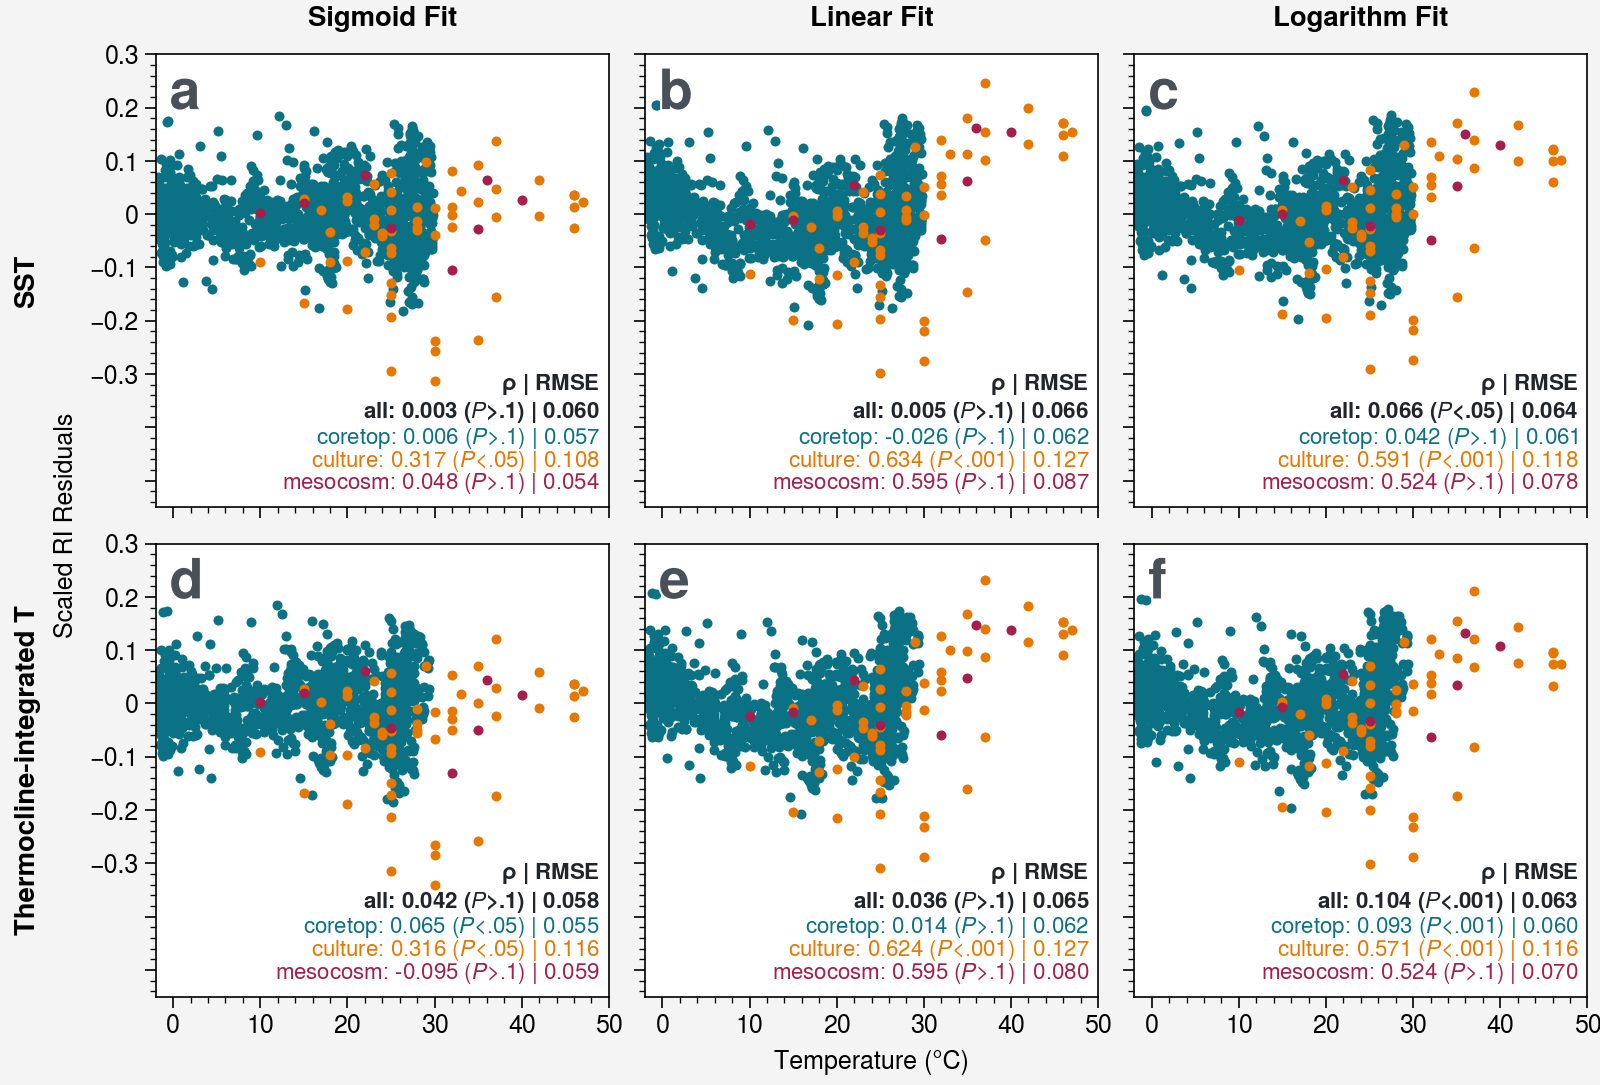

In [ ]:
fig, axs = plot.subplots(nrows=2,ncols=3,width=8)
axs.format(
    collabels=['Sigmoid Fit','Linear Fit','Logarithm Fit'],
    rowlabels=['SST','Thermocline-integrated T']
)

temp_params = ['SST', 't_sf2tc_avg'] 
y_param = 'scaledRI'
func_dict = {
    'Sigmoid Fit': generalized_logistic_model_fixed_upper,
    'Linear Fit': linear_model,
    'Logarithm Fit': linear_model,
}

plot_data = gridded_combined_df
# plot_data = plot_data[~(
#     (plot_data['reference_name'].str.contains('Varma')) 
#     & (plot_data['datatype']=='culture'))]

for i, temp_param in enumerate(temp_params):
    for j, (func_name, func) in enumerate(func_dict.items()):
        ax = axs[i,j]
        reg_data = plot_data[[temp_param,y_param,'datatype']].dropna(how='any')
        
        if func_name == 'Sigmoid Fit':
            popt, pcov = curve_fit(
                    func,
                    reg_data[temp_param],reg_data[y_param], 
                    p0=[20, 0.1, 0.2, 1, 1], 
                    bounds=([0, 0, 0, 0.1, 0], [50, 0.5, 5, 5, 5])
            )
            x_fit = np.linspace(-2,50,100)
            y_fit = func(x_fit, *popt)
            y_pred = func(reg_data[temp_param], *popt)
            y_res = reg_data[y_param] - y_pred
            ### rsme calculation
            rmse = np.sqrt(np.mean(y_res**2))
        elif func_name == 'Linear Fit':
            popt, pcov = curve_fit(
                    func,
                    reg_data[temp_param],reg_data[y_param], 
                    p0=[0.01, 0.1], 
            )
            x_fit = np.linspace(-2,50,100)
            y_fit = func(x_fit, *popt)
            y_pred = func(reg_data[temp_param], *popt)
            y_res = reg_data[y_param] - y_pred
            ### rsme calculation
            rmse = np.sqrt(np.mean(y_res**2))
            
        elif func_name == 'Logarithm Fit':
            popt, pcov = curve_fit(
                    func,
                    reg_data[temp_param],np.log10(reg_data[y_param]), 
                    p0=[0.01, 0.1], 
            )
            x_fit = np.linspace(-2,50,100)
            y_fit = 10**(func(x_fit, *popt))
            y_pred = 10**(func(reg_data[temp_param], *popt))
            y_res = reg_data[y_param] - y_pred
            ### rsme calculation
            rmse = np.sqrt(np.mean(y_res**2))
        
        reg_data[f'{y_param}_pred'] = y_pred
        reg_data[f'{y_param}_residual'] = y_res
        grouped = reg_data.groupby('datatype')
        for name, group in grouped:
            ax.scatter(group[temp_param], group[f'{y_param}_residual'], m='.', label=name,
                       c=datatype_color_dict.get(name,'gray7'))
            
            group_rmse = np.sqrt(np.mean(group[f'{y_param}_residual']**2))
            print(name, group_rmse)
            
            spearmanrho, spearman_pval = spearmanr(group[temp_param], group[f'{y_param}_residual'])
            pval_label = label_pvalues(spearman_pval)
            text = f'{name}: {spearmanrho:.3f} ({pval_label}) | {group_rmse:.3f}'
            ax.text(0.98, 0.18-(0.05*list(grouped.groups.keys()).index(name)), text, transform=ax.transAxes,
                ha='right', va='top',c=datatype_color_dict.get(name,'gray7'),
                fontsize=8)
        
        spearman_rho, spearman_pval = spearmanr(reg_data[temp_param], reg_data[f'{y_param}_residual'])
        pval_label = label_pvalues(spearman_pval)
        text = r'$\rho$ | RMSE'+f'\nall: {spearman_rho:.3f} ({pval_label}) | {rmse:.3f}'
        ax.text(0.98, 0.3, text, transform=ax.transAxes,
            ha='right', va='top',c='gray9',
            fontsize=8,fontweight='bold',)
        
axs.format(
    abc=True,abcstyle='a',abcloc='ul',abcsize=20,abcweight='bold',abccolor='gray7',
    grid=False,
    xlabel='Temperature (°C)',
    ylabel='Scaled RI Residuals',
    ylim=(-0.55,0.3),
    ytickrange=(-0.3,0.3),
    xlim=(-2,50)
)
fpath = f'{local_github_path}/figures/manuscript/finalized/supplementary'
fname = 'figS4_RI_residuals_sst_thermoT_comparison.pdf'
fig.savefig(os.path.join(fpath, fname), dpi=300, bbox_inches='tight')

In [ ]:
def find_optimal_no3_threshold(no3_values, residuals, threshold_range=np.arange(0.5, 5, 0.01), 
                                min_points=5):
    """
    Find NO3 threshold that maximizes negative correlation with residuals.
    
    Parameters:
    -----------
    no3_values : array
        Nitrate concentrations
    residuals : array  
        Residuals from temperature-only model
    threshold_range : array
        Range of thresholds to test
    min_points : int
        Minimum number of points required for correlation
        
    Returns:
    --------
    optimal_threshold : float
        Threshold that gives most negative Spearman rho
    results_df : DataFrame
        Full results for all tested thresholds
    """
    results = []
    
    for threshold in threshold_range:
        # Select data below threshold
        below_threshold = no3_values <= threshold
        no3_subset = no3_values[below_threshold]
        resid_subset = residuals[below_threshold]
        
        # Remove NaN/Inf
        valid_idx = (np.isfinite(no3_subset) & 
                     np.isfinite(resid_subset) & 
                     (no3_subset > 0))  # Ensure positive for log
        
        no3_valid = no3_subset[valid_idx]
        resid_valid = resid_subset[valid_idx]
        
        if len(no3_valid) >= min_points:
            rho, pval = spearmanr(np.log10(no3_valid), resid_valid)
            results.append({
                'threshold': threshold,
                'spearman_rho': rho,
                'spearman_pval': pval,
                'n_points': len(no3_valid)
            })
    
    results_df = pd.DataFrame(results)
    optimal_threshold = results_df.loc[results_df['spearman_rho'].idxmin(), 'threshold']
    
    return optimal_threshold, results_df

Optimal low_no3_threshold (RI-res): 1.7700000000000011


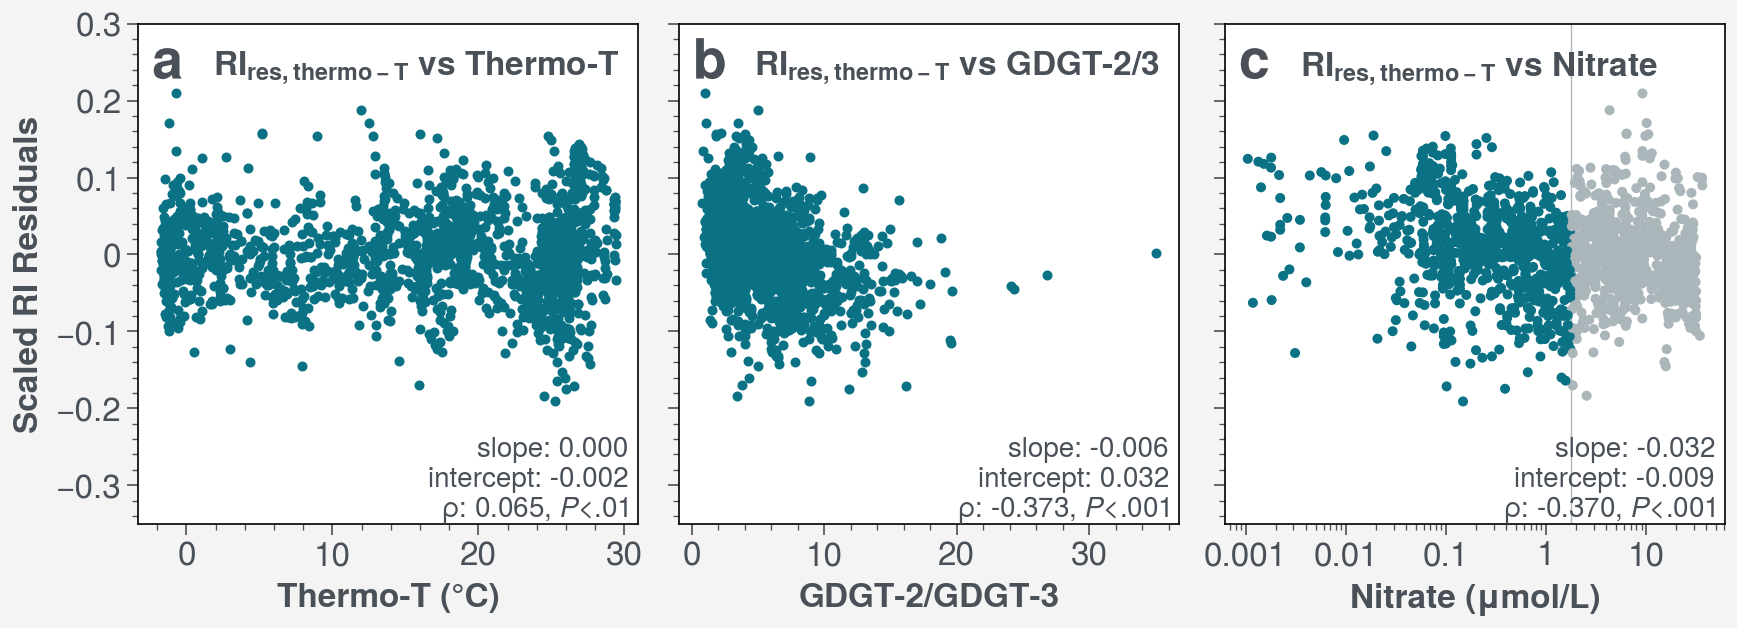

In [ ]:
fig, axs = plot.subplots(ncols=3, sharex=0)

x_param = 't_sf2tc_avg'
y_param = 'scaledRI'


plot_data = combined_df_raw[combined_df_raw['lowAbundanceFlag']==False][combined_df_raw['TEXRI_mahalDist_low23ratio_outliers_manual']==False]
nonnan_idx = (~plot_data[y_param].isna()) & (~plot_data[x_param].isna())
XX = plot_data[x_param][nonnan_idx]
YY = plot_data[y_param][nonnan_idx]

popt, pcov = curve_fit(
    generalized_logistic_model_fixed_upper,
    XX,YY, 
    p0=[20, 0.1, 0.2, 1, 1], 
    bounds=([0, 0, 0, 0.1, 0], [50, 0.5, 5, 5, 5])
)

plot_data['pred_'+y_param] = generalized_logistic_model_fixed_upper(plot_data[x_param], *popt)
plot_data[y_param+'_res'] = plot_data[y_param] - plot_data['pred_'+y_param]

####### plot RI_res vs t_sf2tc_avg ##########
ax = axs[0]
plot_x = plot_data[plot_data['datatype']=='coretop'][x_param]
plot_y = plot_data[plot_data['datatype']=='coretop'][y_param+'_res']
m = ax.scatter(plot_x, plot_y, 
               c=datatype_color_dict.get('coretop','gray7'),
               marker='.')
nonnan_idx = (~plot_data[plot_data['datatype']=='coretop'][x_param].isna()) & (~plot_data[plot_data['datatype']=='coretop'][y_param+'_res'].isna())
reg_X = plot_data[plot_data['datatype']=='coretop'][x_param][nonnan_idx].values.reshape(-1,1)
reg_y = plot_data[plot_data['datatype']=='coretop'][y_param+'_res'][nonnan_idx].values

from sklearn.linear_model import LinearRegression
reg_model = LinearRegression().fit(reg_X, reg_y)
reg_y_pred = reg_model.predict(reg_X)
xx1 = np.linspace(-2,30,100).reshape(-1,1)
yy1 = reg_model.predict(xx1)
# ax.plot(xx1, yy1, c='k', label='linear fit')

slope = reg_model.coef_[0]
intercept = reg_model.intercept_
spearman_rho, spearman_pval = spearmanr(reg_X.flatten(), reg_y)
pval_label = label_pvalues(spearman_pval)
text_lists = [
    f'slope: {slope:.3f}',
    f'intercept: {intercept:.3f}',
    r'$\rho$: '+f'{spearman_rho:.3f}, {pval_label}',
]
for i, text in enumerate(text_lists):
    ax.text(0.98, 0.15-(i*0.06), text, transform=ax.transAxes,
        ha='right', va='center',c='gray7',fontsize=10)
    
text = 'RI$_{res, thermo-T}$ vs Thermo-T'
ax.text(0.15, 0.95, text, transform=ax.transAxes,
        ha='left', va='top',c='gray7',fontsize=12,fontweight='bold',)
ax.format(xlabel='Thermo-T (°C)')
          


##############################
ax = axs[1]
plot_x = plot_data[plot_data['datatype']=='coretop']['gdgt23ratio']
plot_y = plot_data[plot_data['datatype']=='coretop'][y_param+'_res']
m = ax.scatter(plot_x, plot_y, 
               c=datatype_color_dict.get('coretop','gray7'),
               marker='.')

nonnan_idx = (~plot_data[plot_data['datatype']=='coretop']['gdgt23ratio'].isna()) & (~plot_data[plot_data['datatype']=='coretop'][y_param+'_res'].isna())
reg_X = plot_data[plot_data['datatype']=='coretop']['gdgt23ratio'][nonnan_idx].values.reshape(-1,1)
reg_y = plot_data[plot_data['datatype']=='coretop'][y_param+'_res'][nonnan_idx].values

from sklearn.linear_model import LinearRegression
reg_model = LinearRegression().fit(reg_X, reg_y)
reg_y_pred = reg_model.predict(reg_X)

xx2 = np.linspace(0,30,100).reshape(-1,1)
yy2 = reg_model.predict(xx2)
# ax.plot(xx2, yy2, c='k', label='linear fit')

slope = reg_model.coef_[0]
intercept = reg_model.intercept_
spearman_rho, spearman_pval = spearmanr(reg_X.flatten(), reg_y)
pval_label = label_pvalues(spearman_pval)

text_lists = [
    f'slope: {slope:.3f}',
    f'intercept: {intercept:.3f}',
    r'$\rho$: '+f'{spearman_rho:.3f}, {pval_label}',
]
for i, text in enumerate(text_lists):
    ax.text(0.98, 0.15-(i*0.06), text, transform=ax.transAxes,
        ha='right', va='center',c='gray7',fontsize=10)

text = 'RI$_{res, thermo-T}$ vs GDGT-2/3'
ax.text(0.15, 0.95, text, transform=ax.transAxes,
        ha='left', va='top',c='gray7',fontsize=12,fontweight='bold',)
ax.format(xlabel='GDGT-2/GDGT-3',)
##########################

ax = axs[2]
plot_x = plot_data[plot_data['datatype']=='coretop']['no3_sf2tc_avg']
plot_y = plot_data[plot_data['datatype']=='coretop'][y_param+'_res']

optimal_no3_threshold, threshold_results = find_optimal_no3_threshold(
    plot_x.values, 
    plot_y.values,
    threshold_range=np.arange(0.5, 5, 0.01)
)

low_no3_threshold = optimal_no3_threshold
print(f'Optimal low_no3_threshold (RI-res): {low_no3_threshold}')

m = ax.scatter(plot_x, plot_y, 
               c=plot_x, marker='.',
               levels=[0,low_no3_threshold,20],
               cmap=[datatype_color_dict.get('coretop','gray7'),'gray5'],)
ax.format(xscale='log',xticks=[0.0001,0.001,0.01,0.1,1,10,100],xtickminor=True)

### regression between no3 and scaledRI_res for data with no3 < low_no3_threshold
reg_data_idx = plot_data[plot_data['datatype']=='coretop']['no3_sf2tc_avg'].between(0,low_no3_threshold)
reg_X = plot_data[plot_data['datatype']=='coretop']['no3_sf2tc_avg'][reg_data_idx].values.reshape(-1,1)
reg_y = plot_data[plot_data['datatype']=='coretop'][y_param+'_res'][reg_data_idx].values
reg_log10X = np.log10(reg_X)
nonnan_noninf_idx = ~np.isnan(reg_log10X).flatten() & ~np.isinf(reg_log10X).flatten() & ~np.isnan(reg_y).flatten() & ~np.isinf(reg_y).flatten()

reg_X = reg_X[nonnan_noninf_idx]
reg_y = reg_y[nonnan_noninf_idx]
reg_model_no3_orig = LinearRegression().fit(np.log10(reg_X), reg_y)
reg_y_pred = reg_model_no3_orig.predict(np.log10(reg_X))
xx4 = np.linspace(0.0001,low_no3_threshold,100).reshape(-1,1)
yy4 = reg_model_no3_orig.predict(np.log10(xx4))
# ax.plot(xx4, yy4, c='k', label=f'linear fit for no3 < {low_no3_threshold}')
ax.axvline(x=low_no3_threshold, color='gray5', ls='-', lw=0.5, zorder=0)

slope = reg_model_no3_orig.coef_[0]
intercept = reg_model_no3_orig.intercept_
spearman_rho, spearman_pval = spearmanr(np.log10(reg_X), reg_y)
pval_label = label_pvalues(spearman_pval)
text_lists = [
    f'slope: {slope:.3f}',
    f'intercept: {intercept:.3f}',
    r'$\rho$: '+f'{spearman_rho:.3f}, {pval_label}',
]
for i, text in enumerate(text_lists):
    ax.text(0.98, 0.15-(i*0.06), text, transform=ax.transAxes,
        ha='right', va='center',c='gray7',fontsize=10)

text = 'RI$_{res, thermo-T}$ vs Nitrate'
ax.text(0.15, 0.95, text, transform=ax.transAxes,
        ha='left', va='top',c='gray7',fontsize=12,fontweight='bold',)
ax.format(xlabel='Nitrate (μmol/L)',
          xticks=[0.0001,0.001,0.01,0.1,1,10,100],
          xticklabels=['','0.001','0.01','0.1','1','10','100'],)

axs.format(
    abc=True,abcstyle='a',abcloc='ul',abcsize=20,abcweight='bold',abccolor='gray7',
    fontsize=12,labelsize=12,
    labelcolor='gray7',xtickcolor='gray7',ytickcolor='gray7',
    xticklabelcolor='gray7',yticklabelcolor='gray7',
    xlabelweight='bold', ylabelweight='bold',
    xtickminor=True,
    ylim=(-0.35,0.3),
    ylabel='Scaled RI Residuals',
    grid=False,

    )

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'fig7_residuals_vs_covariates_coretop_only.pdf'

fig.savefig(os.path.join(fpath, fname), dpi=300, bbox_inches='tight')

In [ ]:
from scipy import stats

x_param = 't_sf2tc_avg'
y_param = 'scaledRI'
plot_data = gridded_combined_df

########## STAGE 1: TEMPERATURE ONLY MODEL ##########
# Fit temperature on GLOBAL dataset (coretop + mesocosm + culture)
nonnan_idx_global = (~plot_data[y_param].isna()) & (~plot_data[x_param].isna())
XX_temp_global = plot_data[x_param][nonnan_idx_global].values
YY_global = plot_data[y_param][nonnan_idx_global].values

popt_T_global, _ = curve_fit(
    generalized_logistic_model_fixed_upper,
    XX_temp_global, YY_global,
    p0=[20, 0.1, 0.2, 1, 1],
    bounds=([0, 0, 0, 0.1, 0], [50, 0.5, 5, 5, 5])
)

# Calculate global R² and RMSE
pred_RI_T_global = generalized_logistic_model_fixed_upper(XX_temp_global, *popt_T_global)
r2_T_global = 1 - np.sum((YY_global - pred_RI_T_global)**2) / np.sum((YY_global - np.mean(YY_global))**2)
rmse_T_global = np.sqrt(np.mean((YY_global - pred_RI_T_global)**2))

print(f"Global Temperature Calibration (n={len(YY_global)}):")
print(f"  R² = {r2_T_global:.3f}")
print(f"  RMSE = {rmse_T_global:.3f}")


############ STAGE 2: Analyse nonthermal effects on coretop data only ##########
# Extract coretop data
coretop_mask = (plot_data['datatype'] == 'coretop') & \
               (~plot_data[y_param].isna()) & \
               (~plot_data[x_param].isna()) & \
               (~plot_data['gdgt23ratio'].isna()) & \
               (~plot_data['no3_sf2tc_avg'].isna())

XX_coretop_temp = plot_data[x_param][coretop_mask].values
XX_coretop_gdgt23 = plot_data['gdgt23ratio'][coretop_mask].values
XX_coretop_no3 = plot_data['no3_sf2tc_avg'][coretop_mask].values
YY_coretop = plot_data[y_param][coretop_mask].values

n_coretop = len(YY_coretop)

# Calculate coretop residuals using GLOBAL temperature parameters
pred_RI_T_coretop = generalized_logistic_model_fixed_upper(XX_coretop_temp, *popt_T_global)
resid_RI_T_coretop = YY_coretop - pred_RI_T_coretop

# Calculate R² and RMSE for temperature-only on coretop subset
r2_T_coretop = 1 - np.sum(resid_RI_T_coretop**2) / np.sum((YY_coretop - np.mean(YY_coretop))**2)
rmse_T_coretop = np.sqrt(np.mean(resid_RI_T_coretop**2))
rss_T_coretop = np.sum(resid_RI_T_coretop**2)

print(f"\nCoretop subset (n={n_coretop}):")
print(f"  R² (global T params) = {r2_T_coretop:.3f}")
print(f"  RMSE = {rmse_T_coretop:.3f}")

# Find threshold using coretop residuals
optimal_no3_threshold, threshold_results = find_optimal_no3_threshold(
    XX_coretop_no3, 
    resid_RI_T_coretop,
    threshold_range=np.arange(0.5, 5, 0.01)
)

print(f"\nOptimal NO3 threshold: {optimal_no3_threshold:.2f} μmol/L")

def covariate_model_fixed_T(X, beta_gdgt23, beta_no3):
    """
    Fit only covariate coefficients, keeping global T parameters fixed
    
    RI = RI_from_T_global(t) + β₁*GDGT-2/3 + β₂*log10(NO3)
    """
    t, gdgt23, no3 = X[:, 0], X[:, 1], X[:, 2]
    
    # Use FIXED global temperature parameters to predict RI
    pred_RI_logistic = generalized_logistic_model_fixed_upper(t, *popt_T_global)
    
    # Fit only covariate effects
    gdgt23_term = beta_gdgt23 * gdgt23
    no3_capped = np.minimum(no3, optimal_no3_threshold)
    no3_term = beta_no3 * np.log10(no3_capped + 1e-6)
    
    return pred_RI_logistic + gdgt23_term + no3_term


XX_coretop_multi = np.column_stack([XX_coretop_temp, XX_coretop_gdgt23, XX_coretop_no3])

# Fit only 2 parameters (beta_gdgt23, beta_no3)
popt_covariates, _ = curve_fit(
    covariate_model_fixed_T,
    XX_coretop_multi, YY_coretop,
    p0=[0.001, -0.01],
    bounds=([-0.05, -0.2], [0.05, 0])
)

print(f"\nCovariate Coefficients:")
print(f"  β_GDGT-2/3: {popt_covariates[0]:.6f}")
print(f"  β_NO3:      {popt_covariates[1]:.6f}")

# Calculate R², RMSE, and F-test with covariates
pred_RI_full_coretop = covariate_model_fixed_T(XX_coretop_multi, *popt_covariates)
resid_full = YY_coretop - pred_RI_full_coretop
r2_full_coretop = 1 - np.sum(resid_full**2) / np.sum((YY_coretop - np.mean(YY_coretop))**2)
rmse_full_coretop = np.sqrt(np.mean(resid_full**2))
rss_full_coretop = np.sum(resid_full**2)

# F-test: Temperature only vs Temperature + covariates
# df: added 2 parameters (beta_gdgt23, beta_no3)
k_reduced = 0  # no additional params beyond fixed global T
k_full = 2     # 2 additional params
df_diff = k_full - k_reduced
df_residual_full = n_coretop - k_full - 1

f_stat_full = ((rss_T_coretop - rss_full_coretop) / df_diff) / (rss_full_coretop / df_residual_full)
p_val_full = 1 - stats.f.cdf(f_stat_full, df_diff, df_residual_full)

print(f"\nCoretop Model Performance:")
print(f"  R² (global T only):      {r2_T_coretop:.3f}")
print(f"  RMSE (global T only):    {rmse_T_coretop:.3f}")
print(f"  R² (T + covariates):     {r2_full_coretop:.3f}")
print(f"  RMSE (T + covariates):   {rmse_full_coretop:.3f}")
print(f"  ΔR² (covariate contrib): {r2_full_coretop - r2_T_coretop:.3f}")
print(f"  F-statistic:             {f_stat_full:.2f}")
print(f"  F-test p-value:          {p_val_full:.2e}")

# Model: T + GDGT-2/3 only
def model_T_gdgt23_fixed(X, beta_gdgt23):
    t, gdgt23 = X[:, 0], X[:, 1]
    pred_RI_logistic = generalized_logistic_model_fixed_upper(t, *popt_T_global)
    return pred_RI_logistic + beta_gdgt23 * gdgt23

XX_T_gdgt23 = np.column_stack([XX_coretop_temp, XX_coretop_gdgt23])
popt_gdgt23, _ = curve_fit(model_T_gdgt23_fixed, XX_T_gdgt23, YY_coretop,
                           p0=[0.001], bounds=([-0.05], [0.05]))
pred_RI_T_gdgt23 = model_T_gdgt23_fixed(XX_T_gdgt23, *popt_gdgt23)
resid_T_gdgt23 = YY_coretop - pred_RI_T_gdgt23
r2_T_gdgt23 = 1 - np.sum(resid_T_gdgt23**2) / np.sum((YY_coretop - np.mean(YY_coretop))**2)
rmse_T_gdgt23 = np.sqrt(np.mean(resid_T_gdgt23**2))
rss_T_gdgt23 = np.sum(resid_T_gdgt23**2)

# F-test for T + GDGT-2/3
k_gdgt23 = 1
df_diff_gdgt23 = k_gdgt23
df_residual_gdgt23 = n_coretop - k_gdgt23 - 1
f_stat_gdgt23 = ((rss_T_coretop - rss_T_gdgt23) / df_diff_gdgt23) / (rss_T_gdgt23 / df_residual_gdgt23)
p_val_gdgt23 = 1 - stats.f.cdf(f_stat_gdgt23, df_diff_gdgt23, df_residual_gdgt23)

# Model: T + NO3 only
def model_T_no3_fixed(X, beta_no3):
    t, no3 = X[:, 0], X[:, 1]
    pred_RI_logistic = generalized_logistic_model_fixed_upper(t, *popt_T_global)
    no3_capped = np.minimum(no3, optimal_no3_threshold)
    return pred_RI_logistic + beta_no3 * np.log10(no3_capped + 1e-6)

XX_T_no3 = np.column_stack([XX_coretop_temp, XX_coretop_no3])
popt_no3, _ = curve_fit(model_T_no3_fixed, XX_T_no3, YY_coretop,
                       p0=[-0.01], bounds=([-0.2], [0]))
pred_RI_T_no3 = model_T_no3_fixed(XX_T_no3, *popt_no3)
resid_T_no3 = YY_coretop - pred_RI_T_no3
r2_T_no3 = 1 - np.sum(resid_T_no3**2) / np.sum((YY_coretop - np.mean(YY_coretop))**2)
rmse_T_no3 = np.sqrt(np.mean(resid_T_no3**2))
rss_T_no3 = np.sum(resid_T_no3**2)

# F-test for T + NO3
k_no3 = 1
df_diff_no3 = k_no3
df_residual_no3 = n_coretop - k_no3 - 1
f_stat_no3 = ((rss_T_coretop - rss_T_no3) / df_diff_no3) / (rss_T_no3 / df_residual_no3)
p_val_no3 = 1 - stats.f.cdf(f_stat_no3, df_diff_no3, df_residual_no3)

# Variance partitioning
unique_gdgt23 = r2_full_coretop - r2_T_no3
unique_no3 = r2_full_coretop - r2_T_gdgt23

print(f"\n" + "="*70)
print("VARIANCE PARTITIONING (Coretop only)")
print("="*70)
print(f"{'Model':<25} {'R²':>8} {'ΔR²':>8} {'RMSE':>8} {'F-stat':>8} {'p-value':>10}")
print("-"*70)
print(f"{'Global T (fixed)':<25} {r2_T_coretop:>8.3f} {'--':>8} {rmse_T_coretop:>8.3f} {'--':>8} {'--':>10}")
print(f"{'+ GDGT-2/3':<25} {r2_T_gdgt23:>8.3f} {r2_T_gdgt23-r2_T_coretop:>8.3f} {rmse_T_gdgt23:>8.3f} {f_stat_gdgt23:>8.2f} {p_val_gdgt23:>10.2e}")
print(f"{'+ NO3':<25} {r2_T_no3:>8.3f} {r2_T_no3-r2_T_coretop:>8.3f} {rmse_T_no3:>8.3f} {f_stat_no3:>8.2f} {p_val_no3:>10.2e}")
print(f"{'+ Both':<25} {r2_full_coretop:>8.3f} {r2_full_coretop-r2_T_coretop:>8.3f} {rmse_full_coretop:>8.3f} {f_stat_full:>8.2f} {p_val_full:>10.2e}")
print("-"*70)
print(f"\nUnique contributions:")
print(f"  GDGT-2/3 (unique):       {unique_gdgt23:.3f}  ({100*unique_gdgt23:.2f}%)")
print(f"  NO3 (unique):            {unique_no3:.3f}  ({100*unique_no3:.2f}%)")

Global Temperature Calibration (n=1475):
  R² = 0.737
  RMSE = 0.058

Coretop subset (n=1350):
  R² (global T params) = 0.736
  RMSE = 0.055

Optimal NO3 threshold: 1.77 μmol/L

Covariate Coefficients:
  β_GDGT-2/3: -0.001910
  β_NO3:      -0.027152

Coretop Model Performance:
  R² (global T only):      0.736
  RMSE (global T only):    0.055
  R² (T + covariates):     0.769
  RMSE (T + covariates):   0.051
  ΔR² (covariate contrib): 0.033
  F-statistic:             95.36
  F-test p-value:          1.11e-16

VARIANCE PARTITIONING (Coretop only)
Model                           R²      ΔR²     RMSE   F-stat    p-value
----------------------------------------------------------------------
Global T (fixed)             0.736       --    0.055       --         --
+ GDGT-2/3                   0.743    0.007    0.054    36.69   1.79e-09
+ NO3                        0.756    0.020    0.053   108.59   1.11e-16
+ Both                       0.769    0.033    0.051    95.36   1.11e-16
--------------

In [ ]:
from scipy import stats

# After fitting the multivariate model, extract covariance matrix
popt_covariates, pcov_covariates = curve_fit(
    covariate_model_fixed_T,
    XX_coretop_multi, YY_coretop,
    p0=[0.001, -0.01],
    bounds=([-0.05, -0.2], [0.05, 0])
)

# Calculate standard errors
perr = np.sqrt(np.diag(pcov_covariates))

# Calculate 95% CI (t-distribution with df = n - k - 1)
df_residual = n_coretop - 2 - 1  # 2 parameters
t_crit = stats.t.ppf(0.975, df_residual)  # 97.5th percentile for two-tailed test

ci_lower = popt_covariates - t_crit * perr
ci_upper = popt_covariates + t_crit * perr

print(f"\nCoefficient 95% Confidence Intervals:")
print(f"  β_GDGT-2/3: {popt_covariates[0]:.6f} [{ci_lower[0]:.6f}, {ci_upper[0]:.6f}]")
print(f"  β_NO3:      {popt_covariates[1]:.6f} [{ci_lower[1]:.6f}, {ci_upper[1]:.6f}]")


Coefficient 95% Confidence Intervals:
  β_GDGT-2/3: -0.001910 [-0.002340, -0.001481]
  β_NO3:      -0.027152 [-0.031500, -0.022804]


In [ ]:
region_names = gridded_combined_df.regionName.unique()[:-2]

cyc1 = plot.get_colors('tab20',N=20)
cyc2 = plot.get_colors('tab20b',N=20)
cyc3 = plot.get_colors('tab20c',N=20)
cyc4 = plot.get_colors('dark2',N=8)

new_cyc = cyc1 + cyc2 + cyc3 + cyc4
region_color_dict_full = {region_names[i]: new_cyc[i] for i in range(len(region_names))}
region_color_dict_full

{'Weddell Sea': '#1f77b4ff',
 'Ross Sea': '#aec7e8ff',
 'Amundsen Sea': '#ff7f0eff',
 'Pacific-Southern Ocean': '#ffbb78ff',
 'Southern Ocean (Indian Ocean)': '#2ca02cff',
 'Drake Passage': '#98df8aff',
 'Tasman-Antarctica 140E Transect': '#d62728ff',
 'SE Pacific': '#ff9896ff',
 'Southern Ocean Front-Atlantic': '#9467bdff',
 'Chilean Offshore': '#c5b0d5ff',
 'NZ-SW Pacific': '#8c564bff',
 'Eastern South America Offshore': '#c49c94ff',
 'South Atlantic Gyre': '#e377c2ff',
 'Eastern South America Offshore_far': '#f7b6d2ff',
 'Indian Ocean Gyre': '#7f7f7fff',
 'Tasman Sea': '#c7c7c7ff',
 'South Africa Offshore': '#bcbd22ff',
 'Eastern South America Offshore_Cabo Frio-Nearshore': '#dbdb8dff',
 'Tonga-Tropical South Pacific': '#17becfff',
 'Western African Upwelling': '#9edae5ff',
 'Mozambique Channel': '#393b79ff',
 'East Equatorial Pacific': '#5254a3ff',
 'Eastern Indian Ocean (Offshore Indonesia)': '#6b6ecfff',
 None: '#9c9edeff',
 'Tropical Atlantic': '#637939ff',
 'Indonesian Throughf

In [ ]:
# fpath = os.path.join(local_github_path,'data/spreadsheets')
# fname = 'ds_gridded_screened_global_compilation_finalized'

# gridded_combined_df.to_csv(os.path.join(fpath, fname + '.csv'), index=False)